# FOND Learnable Weights: dataset-wise tuning and coefficient tracking

Focused execution notebook for the tuned FOND + learnable-loss-weights runs. Shared model, dataset, and training definitions are retained from the project notebook; each dataset below has its own Optuna tuning cell and final training cell.

**Available tuned datasets:** PACS, OfficeHome, and VLCS. The source notebook does not contain a tuned DomainNet preset, so this notebook does not invent one.

Set dataset paths and 	est_set_id in the Config cell before running. Run shared setup cells once, then for each dataset run its tuning cell and its training cell. Final training uses the saved tuned hyperparameters embedded in that dataset cell. Coefficient history is written to each run's logs/learned_loss_coefficients.csv.


# Lib Installation

In [1]:
!pip install  lightning pytorch-lightning torchvision tqdm python-dotenv PyYAML wilds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.0 MB/s eta 0:00:00


In [2]:
!pip install --upgrade scipy
# Then restart runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 32.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [3]:
# Option 1: Install older albumentations
!pip install --upgrade albumentations

In [4]:
!pip install numpy==1.24.3 scipy==1.11.4 lightning==2.1.0
# Then restart runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 105.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# Config

In [5]:
# =============================================================================
# YOUR EXISTING CONFIG - JUST CHANGE THE "algo" FIELD
# =============================================================================

config = {
    "algo": "FOND",  # <--- CHANGE THIS (was "FOND")
    "dataset": ["PACS", "VLCS", "OfficeHome", "DomainNet"],
    "test_set_id": 0,

    # Paths
    "data_dir": {
        "PACS": "/kaggle/input/datasets/ma3ple/pacs-dataset/kfold",
        "VLCS": "/kaggle/input/datasets/iamjanvijay/vlcsdataset",
        "OfficeHome": "/kaggle/input/datasets/jinchenggong/officehome/OfficeHome",
        "DomainNet":  "/root/.cache/kagglehub/datasets/mei1963/domainnet/versions/1/DomainNet"
    },
    "log_dir": "./logs",

    # Training settings
    "n_epochs": 5001,
    "checkpoint_freq": 300,
    "holdout_fraction": 0.2,

    # Model checkpointing
    "model_checkpoint": {
        "metric": "val/oacc",
        "maximize": True
    },
    'lambda_1': 0.85,  # Inter-domain mixup [0.7, 1.0]
    'lambda_2': 0.85,

    # Seeds
    "overall_seed": 1,
    "trial_id": 0,
    "hparam_id": 0,

    # System
    "num_workers": 12,

    # Dataset config
    "overlap": "high",
    "num_classes": None,
    "num_domain_linked_classes": None,
    "cdsa_y_l_multiplier": 1.0,
    # AutoAugment (RandAugment)
    "auto_augment": False,
    "augment_search_epochs": 5,
    "augment_policy_size": 5,
    "augment_num_policies": 3,
        # ========================================
    "backbone": "vit",  # Options: "resnet" or "vit"
    "vit_variant": "vit_b_16",  # Options: "vit_b_16", "vit_b_32", "vit_l_16"
    "vit_dropout": 0.1,
    # Teacher paths
    "teacher_paths": {}
}



# Imports

In [6]:
import math
from typing import List, Any, Dict, Optional, Callable, Tuple
import argparse
import logging
import hashlib
import numpy as np
import pandas as pd
from collections import Counter
import collections
import time
from datetime import datetime
import lightning as L
from tqdm import tqdm
import csv
import json
from pathlib import Path
from os.path import basename, dirname, join, exists, splitext
import os
from tqdm import tqdm
import shutil
from glob import glob
import torch
import torchmetrics
import torchvision.datasets.folder
from torch.utils.data import ConcatDataset, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST, ImageFolder
from torchvision.transforms.functional import rotate
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset
import scipy.misc
import gc
from scipy import linalg
from skimage.util import dtype, dtype_limits
from skimage.exposure import rescale_intensity
import skimage.exposure
import skimage.color
import scipy.ndimage
import math
from scipy import ndimage
import inspect

#from tensorflow.contrib import training as contrib_training
from PIL import Image, ImageEnhance, ImageOps, ImageFilter , ImageFile

import albumentations as A
from albumentations.augmentations.geometric.resize import RandomScale

import random

/tmp/ipykernel_1097/3319951285.py:33: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc
/usr/local/lib/python3.13/dist-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


# SRC

## Domain Creation

In [7]:

def create_domains(
    num_classes: int, num_linked: int, num_train_domains: int
) -> List[List[int]]:
    """
    Determine and distribute domain-linked and domain-shared classes.
    Domain-linked classes will come from the same domain, i.e., idx=0.
    Domain-shared classes will exist in each of the remaining domains

    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_train_domains: number of different training domains
    """
    assert num_linked <= num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    domain_linked = [i for i in range(num_linked)]
    logging.info(f"Domain-shared classes: {domain_shared}")
    logging.info(f"Domain-linked classes: {domain_linked}")
    # domains = [domain_shared.copy() for i in range(num_train_domains)]
    domains = [[] for i in range(num_train_domains)]

    # first domain is domain-linked only
    domains[0] = domain_linked
    # other domains contain domain-shared only
    domains[1:] = [domain_shared.copy() for i in range(1, num_train_domains)]

    logging.info(f"domains[0]: {domains[0]}")
    logging.info(f"domains[1:]: {domains[1:]}")

    return domains


def create_domains_1(
    num_classes: int, num_linked: int, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_domains: number of different domains, including test domain
    """
    assert num_linked < num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    print(f"Shared classes: {domain_shared}")
    num_train_domains = num_domains - 1
    domains = [domain_shared.copy() for i in range(num_train_domains)]

    for class_idx in range(num_linked):
        domain_idx = class_idx % num_train_domains
        domains[domain_idx].append(class_idx)
    return domains


def create_domains_2(
    num_classes: int, num_linked_ratio: float, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked_ratio: ratio of linked classes to the total number of classes
        num_domains: number of different domains, including test domain
    """
    num_linked = math.floor(num_linked_ratio * num_classes)
    return create_domains_1(num_classes, num_linked, num_domains)



# Testing
create_domains(num_classes=10, num_linked=5, num_train_domains=3)
# Testing domain linked only
create_domains(num_classes=10, num_linked=10, num_train_domains=3)

# Testing same classes with different overlap
domains = create_domains_1(num_classes=10, num_linked=3, num_domains=4)
print(domains)
domains = create_domains_1(num_classes=10, num_linked=5, num_domains=4)
print(domains)

# Testing different classes with same overlap percentage
domains = create_domains_2(num_classes=10, num_linked_ratio=0.2, num_domains=4)
print(domains)
domains = create_domains_2(num_classes=5, num_linked_ratio=0.2, num_domains=4)
print(domains)


Shared classes: [3, 4, 5, 6, 7, 8, 9]
[[3, 4, 5, 6, 7, 8, 9, 0], [3, 4, 5, 6, 7, 8, 9, 1], [3, 4, 5, 6, 7, 8, 9, 2]]
Shared classes: [5, 6, 7, 8, 9]
[[5, 6, 7, 8, 9, 0, 3], [5, 6, 7, 8, 9, 1, 4], [5, 6, 7, 8, 9, 2]]
Shared classes: [2, 3, 4, 5, 6, 7, 8, 9]
[[2, 3, 4, 5, 6, 7, 8, 9, 0], [2, 3, 4, 5, 6, 7, 8, 9, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
Shared classes: [1, 2, 3, 4]
[[1, 2, 3, 4, 0], [1, 2, 3, 4], [1, 2, 3, 4]]


## Hparams

In [8]:
"""
Hyper-parameter registry
"""

def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def _define_hparam(hparams, hparam_name, default_val, random_val_fn):
    hparams[hparam_name] = (hparams, hparam_name, default_val, random_val_fn)


def _hparams(algorithm, dataset, random_seed):
    """
    Global registry of hyperparams. Each entry is a (default, random) tuple.
    New algorithms / networks / etc. should add entries here.
    """
    SMALL_IMAGES = ["Debug28", "RotatedMNIST", "ColoredMNIST"]

    hparams = {}

    def _hparam(name, default_val, random_val_fn):
        """Define a hyperparameter. random_val_fn takes a RandomState and
        returns a random hyperparameter value."""
        assert name not in hparams
        random_state = np.random.RandomState(seed_hash(random_seed, name))
        hparams[name] = (default_val, random_val_fn(random_state))

    # =========================================================================
    # UNCONDITIONAL HPARAM DEFINITIONS (Applied to all algorithms)
    # =========================================================================
    _hparam("data_augmentation", True, lambda r: True)
    _hparam("class_balanced", False, lambda r: False)
    _hparam("nonlinear_classifier", False, lambda r: False)

    # =========================================================================
    # BACKBONE SELECTION (ResNet vs ViT)
    # =========================================================================
    _hparam("backbone", "resnet", lambda r: "resnet")  #pecific hyperparameters
    _hparam("resnet18", True, lambda r: r.choice([True, False]))
    _hparam("resnet_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.5]))

    # ViT-specific hyperparameters (only used when backbone="vit")
    _hparam("vit_variant", "vit_b_16", lambda r: r.choice(["vit_b_16", "vit_b_32", "vit_l_16"]))
    _hparam("vit_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.2, 0.3]))
    _hparam("vit_attention_dropout", 0.0, lambda r: r.choice([0.0, 0.1]))

    # =========================================================================
    # ALGORITHM-SPECIFIC HPARAM DEFINITIONS
    # =========================================================================
    # In hparams_registry.py, add to the FOND section:

    if (
            algorithm == "FOND"
        or algorithm == "FOND_NC"
        or algorithm == "FOND_N"
        or algorithm == "NOC"
        or algorithm == "FOND_CDSA"
        or algorithm == "FOND_CDSA2"
        or algorithm == "FOND_DANN"
        or algorithm == "FOND_PROTO"
        or algorithm == "FOND_Adaptive_Stable"
        or algorithm == "FOND_Adaptive_DatasetAware"
        or algorithm == "FOND_LearnableWeights"  # ADD THIS LINE
        or algorithm == "FOND_DFCL"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))

        # Add hyperparameter for learnable weights
        if algorithm == "FOND_LearnableWeights":
            _hparam("weight_lr", 5e-6, lambda r: 10 ** r.uniform(-6, -4))  # Lower LR for weights
        if algorithm == "FOND_DFCL":
                _hparam("lambda_1", 0.85, lambda r: r.uniform(0.7, 1.0))  # Inter-domain mixup
                _hparam("lambda_2", 0.85, lambda r: r.uniform(0.7, 1.0))  # Intra-domain mixup


        # CDSA-specific hyperparameters (only for FOND_CDSA)
        if algorithm in ["FOND_CDSA", "FOND_CDSA2"]:
            _hparam("cdsa_lambda", 0.5, lambda r: r.uniform(0.3, 0.7))
            _hparam("cdsa_lambda_0", 0.3, lambda r: r.uniform(0.1, 0.5))
            _hparam("cdsa_y_l_multiplier", 2.0, lambda r: r.uniform(1.5, 3.0))

        # Adaptive weight hyperparameters (only for FOND_Adaptive_DatasetAware)
        if algorithm == "FOND_Adaptive_DatasetAware":
            _hparam("weight_warmup_steps", 500, lambda r: int(r.uniform(300, 1000)))
            _hparam("loss_weight_lr", 0.005, lambda r: 10 ** r.uniform(-5, -3))
            _hparam("adaptive_constraints", True, lambda r: True)

            # LOOSER constraints
            _hparam("min_weight_class", 0.2, lambda r: r.uniform(0.2, 0.5))
            _hparam("min_weight_xdom", 0.1, lambda r: r.uniform(0.05, 0.2))
            _hparam("min_weight_error", 0.05, lambda r: r.uniform(0.01, 0.15))

            _hparam("max_weight_class", 2.5, lambda r: r.uniform(2.0, 3.0))
            _hparam("max_weight_xdom", 2.0, lambda r: r.uniform(1.5, 2.5))
            _hparam("max_weight_error", 1.5, lambda r: r.uniform(1.0, 2.0))
        # Adaptive weight hyperparameters
        if algorithm == "FOND_Adaptive_Stable":
            _hparam("total_weight_budget", 3.0, lambda r: r.uniform(2.0, 5.0))
            _hparam("weight_temperature", 1.0, lambda r: r.uniform(0.5, 2.0))
            _hparam("loss_weight_lr", 5e-4, lambda r: 10 ** r.uniform(-5, -3))

            # Constraints (tighter for OfficeHome)
            _hparam("min_weight_class", 0.8, lambda r: r.uniform(0.6, 1.0))
            _hparam("min_weight_xdom", 0.2, lambda r: r.uniform(0.1, 0.5))
            _hparam("min_weight_error", 0.1, lambda r: r.uniform(0.05, 0.3))

            _hparam("max_weight_class", 2.0, lambda r: r.uniform(1.5, 2.5))
            _hparam("max_weight_xdom", 1.5, lambda r: r.uniform(1.0, 2.0))
            _hparam("max_weight_error", 1.0, lambda r: r.uniform(0.5, 1.5))

            # Adaptive weight hyperparameters
            _hparam("weight_warmup_steps", 500, lambda r: int(r.uniform(300, 1000)))
            _hparam("loss_weight_lr", 1e-4, lambda r: 10 ** r.uniform(-5, -3))
            _hparam("adaptive_constraints", True, lambda r: True)

            # LOOSER constraints
            _hparam("min_weight_class", 0.3, lambda r: r.uniform(0.2, 0.5))
            _hparam("min_weight_xdom", 0.1, lambda r: r.uniform(0.05, 0.2))
            _hparam("min_weight_error", 0.05, lambda r: r.uniform(0.01, 0.15))

            _hparam("max_weight_class", 2.5, lambda r: r.uniform(2.0, 3.0))
            _hparam("max_weight_xdom", 2.0, lambda r: r.uniform(1.5, 2.5))
            _hparam("max_weight_error", 1.5, lambda r: r.uniform(1.0, 2.0))
        if algorithm in ['FOND_Adaptive', 'FOND_AdaptiveSoftmax']:
            _hparam("loss_weight_lr", 0.005, lambda r: r.uniform(0.001, 0.1))  # ✅ CORRECT # Smaller LR for weight params

    elif (
        algorithm == "FOND_Distillation_Separate_Projector"
        or algorithm == "FOND_Distillation_Teacher_Projector"
        or algorithm == "FOND_Distillation_Student_Projector"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("distillation_temperature", 1, lambda r: r.uniform(1, 20))

    # =========================================================================
    # DATASET-SPECIFIC HPARAM DEFINITIONS
    # =========================================================================

    # Learning rate
    if dataset in SMALL_IMAGES:
        _hparam("lr", 1e-3, lambda r: 10 ** r.uniform(-4.5, -2.5))
    else:
        _hparam("lr", 5e-5, lambda r: 10 ** r.uniform(-5, -3.5))

    # Weight decay
    if dataset in SMALL_IMAGES:
        _hparam("weight_decay", 0.0, lambda r: 0.0)
    else:
        _hparam("weight_decay", 0.0, lambda r: 10 ** r.uniform(-6, -2))

    # Batch size
    if dataset in SMALL_IMAGES:
        _hparam("batch_size", 64, lambda r: int(2 ** r.uniform(3, 9)))
    elif algorithm == "ARM":
        _hparam("batch_size", 8, lambda r: 8)
    elif dataset == "DomainNet":
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5)))
    else:
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5.5)))

    return hparams


def default_hparams(algorithm, dataset):
    """Get default hyperparameters (hparam_id=0)"""
    return {a: b for a, (b, c) in _hparams(algorithm, dataset, 0).items()}


def random_hparams(algorithm, dataset, seed):
    """Get random hyperparameters (hparam_id>0)"""
    return {a: c for a, (b, c) in _hparams(algorithm, dataset, seed).items()}

## Misc

In [9]:

class _SplitDataset(torch.utils.data.Dataset):
    """Used by split_dataset"""

    def __init__(self, underlying_dataset, keys):
        super(_SplitDataset, self).__init__()
        self.underlying_dataset = underlying_dataset
        self.keys = keys

    def __getitem__(self, key):
        return self.underlying_dataset[self.keys[key]]

    def __len__(self):
        return len(self.keys)


def split_dataset(dataset, n, seed=0):
    """
    Return a pair of datasets corresponding to a random split of the given
    dataset, with n datapoints in the first dataset and the rest in the last,
    using the given random seed
    """
    assert n <= len(dataset)
    keys = list(range(len(dataset)))
    np.random.RandomState(seed).shuffle(keys)
    keys_1 = keys[:n]
    keys_2 = keys[n:]
    return _SplitDataset(dataset, keys_1), _SplitDataset(dataset, keys_2)


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def make_weights_for_balanced_classes(dataset):
    counts = Counter()
    classes = []
    for _, y in dataset:
        y = int(y)
        counts[y] += 1
        classes.append(y)

    n_classes = len(counts)

    weight_per_class = {}
    for y in counts:
        weight_per_class[y] = 1 / (counts[y] * n_classes)

    weights = torch.zeros(len(dataset))
    for i, y in enumerate(classes):
        weights[i] = weight_per_class[int(y)]

    return weights
def compute_loss(network, loader, device):
    """
    Compute average loss for a given loader.
    Returns: average loss value
    """
    total_loss = 0.0
    num_batches = 0

    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)

            # Compute loss
            loss = torch.nn.functional.cross_entropy(p, y, reduction='mean')
            total_loss += loss.item()
            num_batches += 1

    network.train()

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss

def accuracy(network, loader, weights, device, dataset):
    correct = 0
    total = 0
    weights_offset = 0
    overlapping_classes = dataset.overlapping_classes
    num_classes = dataset.num_classes

    f1_score = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    per_class_accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average=None,
    ).to(device)
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    precision = torchmetrics.Precision(
        task='multiclass',  # ✅ Fixed typo
        num_classes=num_classes,
        average='macro'
    ).to(device)
    conf_mat = torchmetrics.ConfusionMatrix(
        task="multiclass",
        num_classes=num_classes
    ).to(device)  # ✅ Added .to(device)

    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)

            if weights is None:
                batch_weights = torch.ones(len(x))
            else:
                batch_weights = weights[weights_offset : weights_offset + len(x)]
                weights_offset += len(x)
            batch_weights = batch_weights.to(device)

            if p.size(1) == 1:
                correct += (
                    (p.gt(0).eq(y).float() * batch_weights.view(-1, 1)).sum().item()
                )
            else:
                correct += (p.argmax(1).eq(y).float() * batch_weights).sum().item()
            total += batch_weights.sum().item()

            # update metrics
            accuracy.update(p, y)
            recall.update(p, y)
            precision.update(p, y)
            f1_score.update(p, y)
            per_class_accuracy.update(p, y)
            conf_mat.update(p, y)

    network.train()
    compute_acc = accuracy.compute().item()
    compute_recall = recall.compute().item()
    compute_precision = precision.compute().item()  # ✅ Fixed typo
    compute_f1 = f1_score.compute().item()
    compute_per_class_acc = per_class_accuracy.compute().cpu().numpy()
    cm_compute = conf_mat.compute().cpu().numpy()  # ✅ Convert to numpy

    overlap_class_acc = []
    non_overlap_class_acc = []
    per_class_acc_dict = {}
    for i in range(num_classes):
        per_class_acc_dict[i] = float(compute_per_class_acc[i])
        if i in overlapping_classes:
            overlap_class_acc.append(compute_per_class_acc[i])
        else:
            non_overlap_class_acc.append(compute_per_class_acc[i])

    if len(non_overlap_class_acc) == 0:
        non_overlap_class_acc = -1
    else:
        non_overlap_class_acc = np.mean(non_overlap_class_acc)
    if len(overlap_class_acc) == 0:
        overlap_class_acc = -1
    else:
        overlap_class_acc = np.mean(overlap_class_acc)

    other_acc = correct / total

    return (
        float(compute_acc),
        float(compute_recall),
        float(compute_f1),
        float(compute_precision),      # ✅ Moved before oacc/nacc
        float(overlap_class_acc),
        float(non_overlap_class_acc),
        per_class_acc_dict,
        cm_compute
    )
class _InfiniteSampler(torch.utils.data.Sampler):
    """Wraps another Sampler to yield an infinite stream."""

    def __init__(self, sampler):
        self.sampler = sampler

    def __iter__(self):
        while True:
            for batch in self.sampler:
                yield batch


class InfiniteDataLoader:
    def __init__(self, dataset, weights, batch_size, num_workers):
        super().__init__()

        if weights is not None:
            sampler = torch.utils.data.WeightedRandomSampler(
                weights, replacement=True, num_samples=batch_size
            )
        else:
            sampler = torch.utils.data.RandomSampler(dataset, replacement=True)

        if weights == None:
            weights = torch.ones(len(dataset))

        batch_sampler = torch.utils.data.BatchSampler(
            sampler, batch_size=batch_size, drop_last=True
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

    def __iter__(self):
        while True:
            yield next(self._infinite_iterator)

    def __len__(self):
        raise ValueError


class FastDataLoader:
    """DataLoader wrapper with slightly improved speed by not respawning worker
    processes at every epoch."""

    def __init__(self, dataset, batch_size, num_workers):
        super().__init__()

        batch_sampler = torch.utils.data.BatchSampler(
            torch.utils.data.RandomSampler(dataset, replacement=False),
            batch_size=batch_size,
            drop_last=False,
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

        self._length = len(batch_sampler)

    def __iter__(self):
        for _ in range(len(self)):
            yield next(self._infinite_iterator)

    def __len__(self):
        return self._length


def config_logging():
    """
    Reusable code for formatting the logger
    """
    logging.basicConfig(
        format="%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(funcName)s:%(lineno)d] %(message)s",
        datefmt="%Y-%m-%d:%H:%M:%S",
        level=logging.INFO,
    )


## Simple Logger

In [10]:
"""
Simple CSV logger to replace W&B during development
Keeps the same interface for easy swap later
"""
class CSVLogger:
    """Lightweight logger that writes metrics to CSV"""

    def __init__(self, csv_path: str, root_dir:str=None):
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self.fieldnames = None
        self.file = None
        self.writer = None
        self._init_csv()
        self.root = root_dir if root_dir is not None else csv_path.parent
    def _init_csv(self):
        """Initialize CSV file with headers"""
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = None  # Will be created on first log
    def return_root(self):
        return self.root
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        """
        Log metrics to CSV

        Args:
            metrics: Dictionary of metric_name -> value
            step: Training step (optional, will be added if provided)
        """
        if step is not None:
            metrics = {"step": step, **metrics}

        # Flatten nested dictionaries (e.g., {"train/acc": 0.9})
        flat_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_metrics[f"{key}/{subkey}"] = subvalue
            else:
                flat_metrics[key] = value

        # Initialize writer with fieldnames on first call
        if self.writer is None:
            self.fieldnames = list(flat_metrics.keys())
            self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
            self.writer.writeheader()

        # Add new fields if they appear
        new_fields = set(flat_metrics.keys()) - set(self.fieldnames)
        if new_fields:
            self.fieldnames.extend(sorted(new_fields))
            # Rewrite file with new headers
            self.file.close()
            self._rewrite_with_new_fields(flat_metrics)
            return

        self.writer.writerow(flat_metrics)
        self.file.flush()  # Ensure immediate write

    def _rewrite_with_new_fields(self, new_row: Dict[str, Any]):
        """Rewrite CSV when new fields are discovered"""
        # Read existing rows
        with open(self.csv_path, 'r') as f:
            reader = csv.DictReader(f)
            existing_rows = list(reader)

        # Rewrite with updated fieldnames
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
        self.writer.writeheader()
        for row in existing_rows:
            self.writer.writerow(row)
        self.writer.writerow(new_row)
        self.file.flush()

    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        """Save experiment config as JSON"""
        if path is None:
            path = self.csv_path.parent / "config.json"
        with open(path, 'w') as f:
            json.dump(config, f, indent=2)

    def close(self):
        """Close CSV file"""
        if self.file:
            self.file.close()

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


class PrintLogger:
    """Even simpler logger that just prints to console"""

    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        step_str = f"[Step {step}] " if step is not None else ""
        metric_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}"
                               for k, v in metrics.items())
        print(f"{step_str}{metric_str}")

    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        print(f"Config: {json.dumps(config, indent=2)}")

    def close(self):
        pass


# Add **data**

### PACS

In [ ]:
!pip -q install kagglehub

import os
from pathlib import Path
import kagglehub

# Optional: Kaggle > Settings > API token, saved in Colab Secrets as KAGGLE_API_TOKEN
try:
    from google.colab import userdata
    token = userdata.get("KAGGLE_API_TOKEN")
    if token:
        os.environ["KAGGLE_API_TOKEN"] = token
except Exception:
    pass

path_pacs = Path(kagglehub.dataset_download("ma3ple/pacs-dataset"))
PACS_ROOT = path_pacs / "kfold" if (path_pacs / "kfold").is_dir() else path_pacs

if "config" in globals():
    config["data_dir"]["PACS"] = str(PACS_ROOT)

print("PACS path:", PACS_ROOT)

100%|██████████| 176M/176M [00:10<00:00, 16.8MB/s]

Extracting files...


PACS path: /root/.cache/kagglehub/datasets/ma3ple/pacs-dataset/versions/1/kfold


### VLCS

In [ ]:
import kagglehub
from pathlib import Path

path_vlcs = Path(kagglehub.dataset_download("iamjanvijay/vlcsdataset"))

if "config" in globals():
    config["data_dir"]["VLCS"] = str(path_vlcs)

print("VLCS path:", path_vlcs)

100%|██████████| 3.58G/3.58G [03:24<00:00, 18.7MB/s]

Extracting files...


VLCS path: /root/.cache/kagglehub/datasets/iamjanvijay/vlcsdataset/versions/1


###Officehome

In [11]:
import kagglehub
from pathlib import Path

path_officehome = Path(kagglehub.dataset_download("jinchenggong/officehome"))
OFFICEHOME_ROOT = (
    path_officehome / "OfficeHome"
    if (path_officehome / "OfficeHome").is_dir()
    else path_officehome
)

if "config" in globals():
    config["data_dir"]["OfficeHome"] = str(OFFICEHOME_ROOT)

print("OfficeHome path:", OFFICEHOME_ROOT)

100%|██████████| 1.06G/1.06G [00:13<00:00, 82.7MB/s]

Extracting files...


OfficeHome path: /root/.cache/kagglehub/datasets/jinchenggong/officehome/versions/1/OfficeHome


# RandAugment

## AugmenterBase

In [12]:
"""
This file contains base class for augmenting patches from whole slide images.
"""


#----------------------------------------------------------------------------------------------------

class AugmenterBase(object):
    """Base class for patch augmentation."""

    def __init__(self, keyword):
        """
        Initialize the object.

        Args:
            keyword (str): Short name for the transformation.
        """

        # Initialize the base class.
        #
        super().__init__()

        # Initialize members.
        #
        self.__keyword = keyword

    @property
    def keyword(self):
        """
        Get the keyword for the augmenter.

        Returns:
            str: Keyword.
        """

        return self.__keyword

    def shapes(self, target_shapes):
        """
        Calculate the required shape of the input to achieve the target output shape.

        Args:
            target_shapes (dict): Target output shape per level.

        Returns:
            (dict): Required input shape per level.
        """

        # By default the output shapes match the input shapes.
        #
        return target_shapes

    def transform(self, patch):
        """
        Transform the given patch.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        pass

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        pass

## AugmenterPool

In [13]:
"""
This file contains a class for handling and applying multiple augmentations on patches from whole slide images.
"""


#----------------------------------------------------------------------------------------------------

class AugmenterPool(object):
    """Class for augmenting patches from whole slide images."""

    def __init__(self):
        """Initialize object."""

        # Initialize the base class.
        #
        super().__init__()

        # Initialize members.
        #
        self.__groups = []          # List of augmenter groups in order of application.
        self.__augmenters = {}      # List of augmenter object by groups.
        self.__probabilities = {}   # Probability of selection for each augmenter.
        self.__current_set = {}     # Index of augmenters that currently selected for execution.
        self.__distributed = False  # Flag to indicate if proper group probabilities have been pre-calculated.

    def __cropbatch(self, patches, labels, shape):
        """
        Crop the batch of patches to the target shape. For efficiency considerations this is a separate function from the crop() public function.

        Args:
            patches (np.ndarray): Image patches to crop.
            labels (np.ndarray): Label images to crop.
            shape (tuple): Target shape.

        Returns:
            (np.ndarray): Cropped batch.

        Raises:
            BatchCroppingError: The target shape for cropping is smaller than the batch to crop itself.
        """

        # Check quickly if cropping is needed at all.
        #
        if patches.shape[2:] == shape:
            # Return the original batch.
            #
            return patches, labels

        else:
            # Check if the shape is larger or equal to the target.

            shift = ((patches.shape[2] - shape[0]) // 2, (patches.shape[3] - shape[1]) // 2)

            # Return the cropped patch.
            #
            return patches[:, :, shift[0]: shift[0] + shape[0], shift[1]: shift[1] + shape[1]], labels[:, :, shift[0]: shift[0] + shape[0], shift[1]: shift[1] + shape[1]] if 2 < labels.ndim else labels

    def appendgroup(self, group, randomized):
        """
        Append augmentation group. If the created group is randomized the augmenter pool will choose one augmenter from the pool for execution, otherwise it is sequential and the augmenter pool
        will execute all the augmenters in the group in order.

        Args:
            group (str): Group identifier.
            randomized (bool): Flag indicating group type.

        Raises:
            AugmentationGroupAlreadyExistsError: Augmentation group already exists.
        """

        # Check if group exists already.
        #

        # Set up the per-group data.
        #
        self.__groups.append(group)
        self.__augmenters[group] = []

        if randomized:
            self.__probabilities[group] = []

    def appendaugmenter(self, augmenter, group, ratio=0.0):
        """
        Append an augmenter object to the group.

        Args:
            augmenter (dptaugmenterbase.AugmenterBase): Augmenter object.
            group (str): Group identifier.
            ratio (float): Ratio for selection.

        Raises:
            UnknownAugmentationGroupError: Unknown augmentation group.
            InvalidAugmentationRatioError: The ratio of the augmentation selection in its group is invalid.
        """

        # Check if the group is known.

        # Check the ratio for selection. It must be larger than 0.0 if the group is randomized.
        #

        # Append the augmenter object and its relative selection probability to the per-group list.
        #
        self.__augmenters[group].append(augmenter)

        if group in self.__probabilities:
            self.__probabilities[group].append(ratio)

            # Reset the distributed flag, only if the affected group is randomized.
            #
            self.__distributed = False

    def distribute(self):
        """Calculate the distribution of the augmenters based on their relative probability."""

        # Normalize the probability of selection to 1.0 sum in the groups.
        #
        for group_id in self.__groups:
            if group_id in self.__probabilities:
                group_p_sum = sum(self.__probabilities[group_id])
                for index in range(len(self.__probabilities[group_id])):
                    self.__probabilities[group_id][index] /= group_p_sum

        # Mark the flag.
        #
        self.__distributed = True

    def shapes(self, target_shapes):
        """
        Calculate the required shape of the input to achieve the target output shape.

        Args:
            target_shapes (dict): Target output shape per level.

        Returns:
            (dict): Required input shape per level.
        """

        # Copy the target sizes.
        #
        required_shapes = target_shapes.copy()

        # Get the maximal required sizes.
        #
        for group_id in self.__augmenters:
            for augmenter_item in self.__augmenters[group_id]:
                required_shapes_for_item = augmenter_item.shapes(target_shapes)

                for level in required_shapes:
                    required_shapes[level] = tuple(max(required_shapes[level][index], required_shapes_for_item[level][index]) for index in range(len(required_shapes[level])))

        return required_shapes

    def transform(self, patch, label=None):
        """
        Randomly select one from each group and apply transformations on the patch and the label map in order.

        Args:
            patch (np.ndarray): Patch to transform.
            label (np.ndarray, None): Patch labels to transform.

        Returns:
            np.ndarray, (np.ndarray, None): Transformed patch, transformed labels.

        Raises:
            MissingAugmentationRandomizationError: Augmentations are configured but not randomized.
        """

        # Check if randomization is done.
        #

        # Prepare the result.
        #
        transformed_patch = patch
        transformed_label = label

        # Go through the groups in order.
        #
        for group_id in self.__groups:
            if group_id in self.__probabilities:
                # Apply transformation on the patch and if there is a label image and the transformation is spatial apply it to the label image too.
                #
                current_augmenter = self.__augmenters[group_id][self.__current_set[group_id]]
                transformed_patch = current_augmenter.transform(patch=transformed_patch)

                if transformed_label is not None and transformed_label.ndim == 3 and isinstance(current_augmenter, dptspatialaugmenterbase.SpatialAugmenterBase):
                    transformed_label = current_augmenter.transform(patch=transformed_label)
            else:
                # This a sequential group. Apply all the augmenters in order.
                #
                for augmenter_item in self.__augmenters[group_id]:
                    transformed_patch = augmenter_item.transform(patch=transformed_patch)

                    if transformed_label is not None and transformed_label.ndim == 3 and isinstance(augmenter_item, dptspatialaugmenterbase.SpatialAugmenterBase):
                        transformed_label = augmenter_item.transform(patch=transformed_label)

        # Return the result patch, label pair.
        #
        return transformed_patch, transformed_label

    def randomize(self):
        """
        Randomize the parameters of the augmenters.

        Raises:
            AugmentationPoolRandomizationBeforeDistribution: The augmentation pool randomized before distribution.
            EmptyAugmentationGroupError: Empty augmentation group.
        """

        # Proper distribution calculation is necessary before randomization.

        # Check if there is an empty group.
        #
        if any(len(self.__augmenters[group_id]) == 0 for group_id in self.__groups):
            empty_groups = [group_id for group_id in self.__groups if len(self.__augmenters[group_id]) == 0]

        for group_id in self.__groups:
            if group_id in self.__probabilities:
                # Randomly select an augmenter based on the configured probability and randomize its parameters.
                #
                augmentation_index = np.random.choice(a=len(self.__probabilities[group_id]), size=None, p=self.__probabilities[group_id])

                self.__current_set[group_id] = augmentation_index
                self.__augmenters[group_id][augmentation_index].randomize()
            else:
                # This is a sequential group. Randomize the parameters of all the augmenters.
                #
                for augmenter_item in self.__augmenters[group_id]:
                    augmenter_item.randomize()

    def crop(self, patch, shape):
        """
        Crop the patch to the target shape.

        Args:
            patch (np.ndarray): Patch to crop.
            shape (tuple): Target shape.

        Returns:
            (np.ndarray): Cropped patch.

        Raises:
            PatchCroppingError: The target shape for cropping is smaller than the patch to crop itself.
        """

        # Check quickly if cropping is needed at all.
        #
        if patch.shape[1:] == shape:
            # Return the original patch.
            #
            return patch

        else:
            # Check if the patch shape is larger or equal to the target.
            #

            # Calculate the shift.
            #
            shift = ((patch.shape[1] - shape[0]) // 2, (patch.shape[2] - shape[1]) // 2)

            # Return the cropped patch.
            #
            return patch[:, shift[0]: shift[0] + shape[0], shift[1]: shift[1] + shape[1]]

    def process(self, patches, shapes=None, randomize=True):
        """
        Process a batch of multi-level patches.

        Args:
            patches (dict): RGB patches and labels per level as given by the PatchSampler.
            randomize (flag to control if parameters should be randomized before each patch augmentation.
            shapes (dict, None): Target patch shapes (rows, columns) per level.

        Returns:
            dict: Augmented patch collection.

        Raises:
            MissingTargetShapeForLevelError: Target shape for cropping is missing for a level.
            MissingAugmentationRandomizationError: Augmentations are configured but not randomized.
            AugmentationPoolRandomizationBeforeDistribution: The augmentation pool randomized before distribution.
            EmptyAugmentationGroupError: Empty augmentation group.
            BatchCroppingError: The target shape for cropping is smaller than the batch to crop itself.
        """

        # Check if the target shapes are valid.
        #

        # Get patch collection length.
        #
        patch_count = next(iter(patches.values()))['patches'].shape[0]

        # Go through all the patches: randomize the augmenters and apply the same augmentation across all the levels for the same patch.
        #
        for index in range(patch_count):
            if randomize:
                self.randomize()

            for level in patches:
                patches[level]['patches'][index], patches[level]['labels'][index] = self.transform(patch=patches[level]['patches'][index], label=patches[level]['labels'][index])

        # Crop the central part of the patches to remove augmentation artifacts.
        #
        if shapes:
            for level in patches:
                patches[level]['patches'], patches[level]['labels'] = self.__cropbatch(patches=patches[level]['patches'], labels=patches[level]['labels'], shape=shapes[level])

        # Return the transformed patch set.
        #
        return patches

## PassThroughAugmenter

In [14]:
"""
This file contains a pass-through augmentation cass.
"""

class PassThroughAugmenter(AugmenterBase):
    """Pass through augmenter that does noting."""

    def __init__(self):
        """Initialize the object."""

        # Initialize the base class.
        #
        super().__init__(keyword='pass_through')

    def transform(self, patch):
        """
        Return the given patch without transformation.

        Args:
            patch (np.ndarray): Patch to return.

        Returns:
            np.ndarray: The patch.
        """

        return patch

## Colors: Utils

### copy_files

### Data Generator

### data handler

### ColorAugmenterBase

In [15]:
class ColorAugmenterBase(AugmenterBase):
    """Base class for color patch augmentation."""

    def __init__(self, keyword):
        """
        Initialize the object.

        Args:
            keyword (str): Short name for the transformation.
        """

        # Initialize the base class.
        #
        super().__init__(keyword=keyword)

### ContrastAugmenter

In [16]:
"""
This file contains a class for augmenting patches from whole slide images with contrast changes.
"""



#----------------------------------------------------------------------------------------------------

class ContrastAugmenter(ColorAugmenterBase):
    """Apply contrast enhancements on the patch."""

    def __init__(self, sigma_range):
        """
        Initialize the object.

        Args:
            sigma_range (tuple): Range for contrast adjustment from the [-1.0, 1.0] range. For example: (-0.4, 0.4).

        Raises:
            InvalidContrastSigmaRangeError: The contrast adjustment range is not valid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='contrast')

        # Initialize members.
        #
        self.__sigma_range = None  # Configured sigma range for contrast enhancement.
        self.__sigma = None        # Randomized sigma.

        # Save configuration.
        #
        self.__setsigmarange(sigma_range=sigma_range)

    def __setsigmarange(self, sigma_range):
        """
        Set the interval.

        Args:
            sigma_range (tuple): Range for contrast adjustment.

        Raises:
            InvalidContrastSigmaRangeError: The contrast adjustment range is not valid.
        """

        # Check the interval.
        #

        # Store the settings.
        #
        self.__sigma_range = list(sigma_range)
        self.__sigma = sigma_range[0]

    def transform(self, patch):
        """
        Apply contrast deformation on the patch.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        # Reorder the patch to channel last format.
        #
        patch_image = np.transpose(a=patch, axes=(1, 2, 0))

        # Augment the contrast.
        #
        patch_center = skimage.color.rgb2gray(rgb=patch_image).mean() * 255.0
        patch_range = (self.__sigma * patch_center, 255.0 - self.__sigma * (255.0 - patch_center))
        patch_contrast = skimage.exposure.rescale_intensity(image=patch_image, in_range=patch_range, out_range='dtype')

        # Order back to channels first order.
        #
        patch_transformed = np.transpose(a=patch_contrast, axes=(2, 0, 1))

        return patch_transformed

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        # Randomize sigma.
        #
        self.__sigma = np.random.uniform(low=self.__sigma_range[0], high=self.__sigma_range[1], size=None)

### custom_hed_transform

In [17]:

rgb_from_hed = np.array([[0.65, 0.70, 0.29],
                         [0.07, 0.99, 0.11],
                         [0.27, 0.57, 0.78]]).astype('float32')
hed_from_rgb = linalg.inv(rgb_from_hed).astype('float32')


def rgb2hed(rgb):

    return separate_stains(rgb, hed_from_rgb)

def hed2rgb(hed):

    return combine_stains(hed, rgb_from_hed)

def separate_stains(rgb, conv_matrix):

    # # t = time.time()
    # rgb = dtype.img_as_float(rgb, force_copy=True).astype('float32')
    # # print('{f} took {s} s'.format(f='separate img_as_float', s=(time.time() - t)), flush=True)
    # # print('rgb type is {r}, matrix type is {m}'.format(r=rgb.dtype, m=conv_matrix.dtype), flush=True)
    #
    # # t = time.time()
    # rgb = -np.log(rgb)
    # # print('{f} took {s} s'.format(f='separate np.log', s=(time.time() - t)), flush=True)
    #
    # # t = time.time()
    # rgb += 2
    # rgb = np.reshape(rgb, (-1, 3))
    # # print('{f} took {s} s'.format(f='separate add reshape', s=(time.time() - t)), flush=True)
    #
    # # print('x shape is {s}, conv_matrix shape is {c}'.format(s=x.shape, c=conv_matrix.shape))
    #
    # # t = time.time()
    # stains = np.dot(rgb, conv_matrix)
    # # print('{f} took {s} s'.format(f='separate np.dot', s=(time.time() - t)), flush=True)
    #
    # return np.reshape(stains, rgb.shape)

    rgb = dtype.img_as_float(rgb, force_copy=True).astype('float32')
    rgb += 2
    stains = np.dot(np.reshape(-np.log(rgb), (-1, 3)), conv_matrix)
    return np.reshape(stains, rgb.shape)


def combine_stains(stains, conv_matrix):

    # # t = time.time()
    # stains = dtype.img_as_float(stains).astype('float32')
    # # stains = stains.astype('float32')
    # # conv_matrix = conv_matrix.astype('float32')
    # # print('{f} took {s} s'.format(f='separate img_as_float', s=(time.time() - t)), flush=True)
    # # print('stains type is {r}, matrix type is {m}'.format(r=stains.dtype, m=conv_matrix.dtype), flush=True)
    #
    # stains = -np.reshape(stains, (-1, 3))
    # # print('x shape is {s}, conv_matrix shape is {c}'.format(s=x.shape, c=conv_matrix.shape))
    #
    # # t = time.time()
    # logrgb2 = np.dot(stains, conv_matrix)
    # # print('{f} took {s} s'.format(f='combine np.dot', s=(time.time() - t)), flush=True)
    #
    # # t = time.time()
    # rgb2 = np.exp(logrgb2)
    # # print('{f} took {s} s'.format(f='combine np.exp', s=(time.time() - t)), flush=True)
    #
    # t = time.time()
    # x = rescale_intensity(np.reshape(rgb2 - 2, stains.shape),
    #                          in_range=(-1, 1))
    # print('{f} took {s} s'.format(f='combine rescale_intensity', s=(time.time() - t)), flush=True)
    #
    # return x

    stains = dtype.img_as_float(stains.astype('float64')).astype('float32')  # stains are out of range [-1, 1] so dtype.img_as_float complains if not float64
    logrgb2 = np.dot(-np.reshape(stains, (-1, 3)), conv_matrix)
    rgb2 = np.exp(logrgb2)
    return rescale_intensity(np.reshape(rgb2 - 2, stains.shape),
                             in_range=(-1, 1))

### hedcoloraugmenter

In [18]:
"""
This file contains a class for augmenting patches from whole slide images by applying color correction in HED color space.
"""

rgb_from_hed = np.array([[0.65, 0.70, 0.29],
                         [0.07, 0.99, 0.11],
                         [0.27, 0.57, 0.78]]).astype('float32')
hed_from_rgb = linalg.inv(rgb_from_hed).astype('float32')


def rgb2hed(rgb):

    return separate_stains(rgb, hed_from_rgb)

def hed2rgb(hed):

    return combine_stains(hed, rgb_from_hed)

def separate_stains(rgb, conv_matrix):

    # # t = time.time()
    # rgb = dtype.img_as_float(rgb, force_copy=True).astype('float32')
    # # print('{f} took {s} s'.format(f='separate img_as_float', s=(time.time() - t)), flush=True)
    # # print('rgb type is {r}, matrix type is {m}'.format(r=rgb.dtype, m=conv_matrix.dtype), flush=True)
    #
    # # t = time.time()
    # rgb = -np.log(rgb)
    # # print('{f} took {s} s'.format(f='separate np.log', s=(time.time() - t)), flush=True)
    #
    # # t = time.time()
    # rgb += 2
    # rgb = np.reshape(rgb, (-1, 3))
    # # print('{f} took {s} s'.format(f='separate add reshape', s=(time.time() - t)), flush=True)
    #
    # # print('x shape is {s}, conv_matrix shape is {c}'.format(s=x.shape, c=conv_matrix.shape))
    #
    # # t = time.time()
    # stains = np.dot(rgb, conv_matrix)
    # # print('{f} took {s} s'.format(f='separate np.dot', s=(time.time() - t)), flush=True)
    #
    # return np.reshape(stains, rgb.shape)

    rgb = dtype.img_as_float(rgb, force_copy=True).astype('float32')
    rgb += 2
    stains = np.dot(np.reshape(-np.log(rgb), (-1, 3)), conv_matrix)
    return np.reshape(stains, rgb.shape)


def combine_stains(stains, conv_matrix):

    # # t = time.time()
    # stains = dtype.img_as_float(stains).astype('float32')
    # # stains = stains.astype('float32')
    # # conv_matrix = conv_matrix.astype('float32')
    # # print('{f} took {s} s'.format(f='separate img_as_float', s=(time.time() - t)), flush=True)
    # # print('stains type is {r}, matrix type is {m}'.format(r=stains.dtype, m=conv_matrix.dtype), flush=True)
    #
    # stains = -np.reshape(stains, (-1, 3))
    # # print('x shape is {s}, conv_matrix shape is {c}'.format(s=x.shape, c=conv_matrix.shape))
    #
    # # t = time.time()
    # logrgb2 = np.dot(stains, conv_matrix)
    # # print('{f} took {s} s'.format(f='combine np.dot', s=(time.time() - t)), flush=True)
    #
    # # t = time.time()
    # rgb2 = np.exp(logrgb2)
    # # print('{f} took {s} s'.format(f='combine np.exp', s=(time.time() - t)), flush=True)
    #
    # t = time.time()
    # x = rescale_intensity(np.reshape(rgb2 - 2, stains.shape),
    #                          in_range=(-1, 1))
    # print('{f} took {s} s'.format(f='combine rescale_intensity', s=(time.time() - t)), flush=True)
    #
    # return x

    stains = dtype.img_as_float(stains.astype('float64')).astype('float32')  # stains are out of range [-1, 1] so dtype.img_as_float complains if not float64
    logrgb2 = np.dot(-np.reshape(stains, (-1, 3)), conv_matrix)
    rgb2 = np.exp(logrgb2)
    return rescale_intensity(np.reshape(rgb2 - 2, stains.shape),
                             in_range=(-1, 1))

#----------------------------------------------------------------------------------------------------

class HedColorAugmenter(ColorAugmenterBase):
    """Apply color correction in HED color space on the RGB patch."""

    def __init__(self, haematoxylin_sigma_range, haematoxylin_bias_range, eosin_sigma_range, eosin_bias_range, dab_sigma_range, dab_bias_range, cutoff_range):
        """
        Initialize the object. For each channel the augmented value is calculated as value = value * sigma + bias

        Args:
            haematoxylin_sigma_range (tuple, None): Adjustment range for the Haematoxylin channel from the [-1.0, 1.0] range where 0.0 means no change. For example (-0.1, 0.1).
            haematoxylin_bias_range (tuple, None): Bias range for the Haematoxylin channel from the [-1.0, 1.0] range where 0.0 means no change. For example (-0.2, 0.2).
            eosin_sigma_range (tuple, None): Adjustment range for the Eosin channel from the [-1.0, 1.0] range where 0.0 means no change.
            eosin_bias_range (tuple, None) Bias range for the Eosin channel from the [-1.0, 1.0] range where 0.0 means no change.
            dab_sigma_range (tuple, None): Adjustment range for the DAB channel from the [-1.0, 1.0] range where 0.0 means no change.
            dab_bias_range (tuple, None): Bias range for the DAB channel from the [-1.0, 1.0] range where 0.0 means no change.
            cutoff_range (tuple, None): Patches with mean value outside the cutoff interval will not be augmented. Values from the [0.0, 1.0] range. The RGB channel values are from the same range.

        Raises:
            InvalidHaematoxylinSigmaRangeError: The sigma range for Haematoxylin channel adjustment is not valid.
            InvalidHaematoxylinBiasRangeError: The bias range for Haematoxylin channel adjustment is not valid.
            InvalidEosinSigmaRangeError: The sigma range for Eosin channel adjustment is not valid.
            InvalidEosinBiasRangeError: The bias range for Eosin channel adjustment is not valid.
            InvalidDabSigmaRangeError: The sigma range for DAB channel adjustment is not valid.
            InvalidDabBiasRangeError: The bias range for DAB channel adjustment is not valid.
            InvalidCutoffRangeError: The cutoff range is not valid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='hed_color')

        # Initialize members.
        #
        self.__sigma_ranges = None  # Configured sigma ranges for H, E, and D channels.
        self.__bias_ranges = None   # Configured bias ranges for H, E, and D channels.
        self.__cutoff_range = None  # Cutoff interval.
        self.__sigmas = None        # Randomized sigmas for H, E, and D channels.
        self.__biases = None        # Randomized biases for H, E, and D channels.

        # Save configuration.
        #
        self.__setsigmaranges(haematoxylin_sigma_range=haematoxylin_sigma_range, eosin_sigma_range=eosin_sigma_range, dab_sigma_range=dab_sigma_range)
        self.__setbiasranges(haematoxylin_bias_range=haematoxylin_bias_range, eosin_bias_range=eosin_bias_range, dab_bias_range=dab_bias_range)
        self.__setcutoffrange(cutoff_range=cutoff_range)

    def __setsigmaranges(self, haematoxylin_sigma_range, eosin_sigma_range, dab_sigma_range):
        """
        Set the sigma intervals.

        Args:
            haematoxylin_sigma_range (tuple, None): Adjustment range for the Haematoxylin channel.
            eosin_sigma_range (tuple, None): Adjustment range for the Eosin channel.
            dab_sigma_range (tuple, None): Adjustment range for the DAB channel.

        Raises:
            InvalidHaematoxylinSigmaRangeError: The sigma range for Haematoxylin channel adjustment is not valid.
            InvalidEosinSigmaRangeError: The sigma range for Eosin channel adjustment is not valid.
            InvalidDabSigmaRangeError: The sigma range for DAB channel adjustment is not valid.
        """

        # Check the intervals.
        #
        '''
        if haematoxylin_sigma_range is not None:
            if len(haematoxylin_sigma_range) != 2 or haematoxylin_sigma_range[1] < haematoxylin_sigma_range[0] or haematoxylin_sigma_range[0] < -1.0 or 1.0 < haematoxylin_sigma_range[1]:
                raise dptaugmentationerrors.InvalidHaematoxylinSigmaRangeError(haematoxylin_sigma_range)

        if eosin_sigma_range is not None:
            if len(eosin_sigma_range) != 2 or eosin_sigma_range[1] < eosin_sigma_range[0] or eosin_sigma_range[0] < -1.0 or 1.0 < eosin_sigma_range[1]:
                raise dptaugmentationerrors.InvalidEosinSigmaRangeError(eosin_sigma_range)

        if dab_sigma_range is not None:
            if len(dab_sigma_range) != 2 or dab_sigma_range[1] < dab_sigma_range[0] or dab_sigma_range[0] < -1.0 or 1.0 < dab_sigma_range[1]:
                raise dptaugmentationerrors.InvalidDabSigmaRangeError(dab_sigma_range)
        '''
        # Store the settings.
        #
        self.__sigma_ranges = [haematoxylin_sigma_range, eosin_sigma_range, dab_sigma_range]

        self.__sigmas = [haematoxylin_sigma_range if haematoxylin_sigma_range is not None else 0.0,
                         eosin_sigma_range if eosin_sigma_range is not None else 0.0,
                         dab_sigma_range if dab_sigma_range is not None else 0.0]


    def __setbiasranges(self, haematoxylin_bias_range, eosin_bias_range, dab_bias_range):
        """
        Set the bias intervals.

        Args:
            haematoxylin_bias_range (tuple, None): Bias range for the Haematoxylin channel.
            eosin_bias_range (tuple, None) Bias range for the Eosin channel.
            dab_bias_range (tuple, None): Bias range for the DAB channel.

        Raises:
            InvalidHaematoxylinBiasRangeError: The bias range for Haematoxylin channel adjustment is not valid.
            InvalidEosinBiasRangeError: The bias range for Eosin channel adjustment is not valid.
            InvalidDabBiasRangeError: The bias range for DAB channel adjustment is not valid.
        """

        # Check the intervals.
        #
        '''
        if haematoxylin_bias_range is not None:
            if len(haematoxylin_bias_range) != 2 or haematoxylin_bias_range[1] < haematoxylin_bias_range[0] or haematoxylin_bias_range[0] < -1.0 or 1.0 < haematoxylin_bias_range[1]:
                raise dptaugmentationerrors.InvalidHaematoxylinBiasRangeError(haematoxylin_bias_range)

        if eosin_bias_range is not None:
            if len(eosin_bias_range) != 2 or eosin_bias_range[1] < eosin_bias_range[0] or eosin_bias_range[0] < -1.0 or 1.0 < eosin_bias_range[1]:
                raise dptaugmentationerrors.InvalidEosinBiasRangeError(eosin_bias_range)

        if dab_bias_range is not None:
            if len(dab_bias_range) != 2 or dab_bias_range[1] < dab_bias_range[0] or dab_bias_range[0] < -1.0 or 1.0 < dab_bias_range[1]:
                raise dptaugmentationerrors.InvalidDabBiasRangeError(dab_bias_range)
        '''
        # Store the settings.
        #
        self.__bias_ranges = [haematoxylin_bias_range, eosin_bias_range, dab_bias_range]

        self.__biases = [haematoxylin_bias_range if haematoxylin_bias_range is not None else 0.0,
                         eosin_bias_range if eosin_bias_range is not None else 0.0,
                         dab_bias_range if dab_bias_range is not None else 0.0]

    def __setcutoffrange(self, cutoff_range):
        """
        Set the cutoff value. Patches with mean value outside the cutoff interval will not be augmented.

        Args:
            cutoff_range (tuple, None): Patches with mean value outside the cutoff interval will not be augmented.

        Raises:
            InvalidCutoffRangeError: The cutoff range is not valid.
        """

        # Check the interval.
        #

        # Store the setting.
        #
        self.__cutoff_range = cutoff_range if cutoff_range is not None else [0.0, 1.0]

    def transform(self, patch):
        """
        Apply color deformation on the patch.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """
        #print('hed self.__biases',self.__biases)
        #print('hed self.__sigmas',self.__sigmas)

        # Check if the patch is inside the cutoff values.
        #
        patch_mean = np.mean(a=patch) / 255.0
        if self.__cutoff_range[0] <= patch_mean <= self.__cutoff_range[1]:
            # Reorder the patch to channel last format and convert the image patch to HED color coding.
            #
            #patch_image = np.transpose(a=patch, axes=(1, 2, 0))
            patch_hed = rgb2hed(rgb=patch)

            # Augment the Haematoxylin channel.
            #
            if self.__sigmas[0] != 0.0:
                patch_hed[:, :, 0] *= (1.0 + self.__sigmas[0])

            if self.__biases[0] != 0.0:
                patch_hed[:, :, 0] += self.__biases[0]

            # Augment the Eosin channel.
            #
            if self.__sigmas[1] != 0.0:
                patch_hed[:, :, 1] *= (1.0 + self.__sigmas[1])

            if self.__biases[1] != 0.0:
                patch_hed[:, :, 1] += self.__biases[1]

            # Augment the DAB channel.
            #
            if self.__sigmas[2] != 0.0:
                patch_hed[:, :, 2] *= (1.0 + self.__sigmas[2])

            if self.__biases[2] != 0.0:
                patch_hed[:, :, 2] += self.__biases[2]

            # Convert back to RGB color coding and order back to channels first order.
            #
            patch_rgb = hed2rgb(hed=patch_hed)
            patch_rgb = np.clip(a=patch_rgb, a_min=0.0, a_max=1.0)
            patch_rgb *= 255.0
            patch_rgb = patch_rgb.astype(dtype=np.uint8)

            #patch_transformed = np.transpose(a=patch_rgb, axes=(2, 0, 1))

            return patch_rgb

        else:
            # The image patch is outside the cutoff interval.
            #
            return patch


    # def transform(self, patch):
    #     """
    #     Apply color deformation on the patch.
    #
    #     Args:
    #         patch (np.ndarray): Patch to transform.
    #
    #     Returns:
    #         np.ndarray: Transformed patch.
    #     """
    #     import time
    #
    #     print('### Timing ###')
    #     t_init = time.time()
    #
    #     # Check if the patch is inside the cutoff values.
    #     #
    #     patch_mean = np.mean(a=patch) / 255.0
    #     if self.__cutoff_range[0] <= patch_mean <= self.__cutoff_range[1]:
    #         # Reorder the patch to channel last format and convert the image patch to HED color coding.
    #         #
    #         # t = time.time()
    #         patch_image = np.transpose(a=patch, axes=(1, 2, 0))
    #         # print('{f} took {s} s'.format(f='initial transpose', s=(time.time() - t)), flush=True)
    #
    #         t = time.time()
    #         patch_hed = rgb2hed(rgb=patch_image)
    #         print('{f} took {s} s'.format(f='rgb2hed', s=(time.time() - t)), flush=True)
    #
    #         # Augment the Haematoxylin channel.
    #         #
    #         # t = time.time()
    #         if self.__sigmas[0] != 0.0:
    #             patch_hed[:, :, 0] *= (1.0 + self.__sigmas[0])
    #
    #         if self.__biases[0] != 0.0:
    #             patch_hed[:, :, 0] += self.__biases[0]
    #         # print('{f} took {s} s'.format(f='H variation', s=(time.time() - t)), flush=True)
    #
    #         # Augment the Eosin channel.
    #         #
    #         # t = time.time()
    #         if self.__sigmas[1] != 0.0:
    #             patch_hed[:, :, 1] *= (1.0 + self.__sigmas[1])
    #
    #         if self.__biases[1] != 0.0:
    #             patch_hed[:, :, 1] += self.__biases[1]
    #         # print('{f} took {s} s'.format(f='E variation', s=(time.time() - t)), flush=True)
    #
    #         # Augment the DAB channel.
    #         #
    #         # t = time.time()
    #         if self.__sigmas[2] != 0.0:
    #             patch_hed[:, :, 2] *= (1.0 + self.__sigmas[2])
    #
    #         if self.__biases[2] != 0.0:
    #             patch_hed[:, :, 2] += self.__biases[2]
    #         # print('{f} took {s} s'.format(f='D variation', s=(time.time() - t)), flush=True)
    #
    #         # Convert back to RGB color coding and order back to channels first order.
    #         #
    #         t = time.time()
    #         patch_rgb = hed2rgb(hed=patch_hed)
    #         print('{f} took {s} s'.format(f='hed2rgb', s=(time.time() - t)), flush=True)
    #
    #         # t = time.time()
    #         patch_rgb = np.clip(a=patch_rgb, a_min=0.0, a_max=1.0)
    #         # print('{f} took {s} s'.format(f='clip', s=(time.time() - t)), flush=True)
    #
    #         # t = time.time()
    #         patch_rgb *= 255.0
    #         patch_rgb = patch_rgb.astype(dtype=np.uint8)
    #         # print('{f} took {s} s'.format(f='255 and uint8', s=(time.time() - t)), flush=True)
    #
    #         # t = time.time()
    #         patch_transformed = np.transpose(a=patch_rgb, axes=(2, 0, 1))
    #         # print('{f} took {s} s'.format(f='transpose end', s=(time.time() - t)), flush=True)
    #
    #         p = patch_transformed
    #
    #     else:
    #         # The image patch is outside the cutoff interval.
    #         #
    #         p = patch
    #
    #     print('{f} took {s} s'.format(f='all', s=(time.time() - t_init)), flush=True)
    #     return p



### HsbColorAugmenter

In [19]:
"""
This file contains a class for augmenting patches from whole slide images by applying color correction in HSB color space.
"""



import skimage.color


#----------------------------------------------------------------------------------------------------

class HsbColorAugmenter(ColorAugmenterBase):
    """Apply color correction in HSB color space on the RGB patch."""

    def __init__(self, hue_sigma_range, saturation_sigma_range, brightness_sigma_range):
        """
        Initialize the object.

        Args:
            hue_sigma_range (tuple, None): Adjustment range for the Hue channel from the [-1.0, 1.0] range where 0.0 means no change. For example (-0.5, 0.5).
            saturation_sigma_range (tuple, None): Adjustment range for the Saturation channel from the [-1.0, 1.0] range where 0.0 means no change.
            brightness_sigma_range (tuple, None): Adjustment range for the Brightness channel from the [-1.0, 1.0] range where 0.0 means no change.

        Raises:
            InvalidHueSigmaRangeError: The sigma range for Hue channel adjustment is not valid.
            InvalidSaturationSigmaRangeError: The sigma range for Saturation channel adjustment is not valid.
            InvalidBrightnessSigmaRangeError: The sigma range for Brightness channel adjustment is not valid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='hsb_color')

        # Initialize members.
        #
        self.__sigma_ranges = None  # Configured sigma ranges for H, S, and B channels.
        self.__sigmas = None        # Randomized sigmas for H, S, and B channels.

        # Save configuration.
        #
        self.__setsigmaranges(hue_sigma_range=hue_sigma_range, saturation_sigma_range=saturation_sigma_range, brightness_sigma_range=brightness_sigma_range)

    def __setsigmaranges(self, hue_sigma_range, saturation_sigma_range, brightness_sigma_range):
        """
        Set the sigma ranges.

        Args:
            hue_sigma_range (tuple, None): Adjustment range for the Hue channel.
            saturation_sigma_range (tuple, None): Adjustment range for the Saturation channel.
            brightness_sigma_range (tuple, None): Adjustment range for the Brightness channel.

        Raises:
            InvalidHueSigmaRangeError: The sigma range for Hue channel adjustment is not valid.
            InvalidSaturationSigmaRangeError: The sigma range for Saturation channel adjustment is not valid.
            InvalidBrightnessSigmaRangeError: The sigma range for Brightness channel adjustment is not valid.
        """

        # Check the intervals.
        #
        '''
        if hue_sigma_range is not None:
            if len(hue_sigma_range) != 2 or hue_sigma_range[1] < hue_sigma_range[0] or hue_sigma_range[0] < -1.0 or 1.0 < hue_sigma_range[1]:
                raise dptaugmentationerrors.InvalidHueSigmaRangeError(hue_sigma_range)

        if saturation_sigma_range is not None:
            if len(saturation_sigma_range) != 2 or saturation_sigma_range[1] < saturation_sigma_range[0] or saturation_sigma_range[0] < -1.0 or 1.0 < saturation_sigma_range[1]:
                raise dptaugmentationerrors.InvalidSaturationSigmaRangeError(saturation_sigma_range)

        if brightness_sigma_range is not None:
            if len(brightness_sigma_range) != 2 or brightness_sigma_range[1] < brightness_sigma_range[0] or brightness_sigma_range[0] < -1.0 or 1.0 < brightness_sigma_range[1]:
                raise dptaugmentationerrors.InvalidBrightnessSigmaRangeError(brightness_sigma_range)
        '''
        # Store the setting.
        #
        self.__sigma_ranges = [hue_sigma_range, saturation_sigma_range, brightness_sigma_range]

        self.__sigmas = [hue_sigma_range if hue_sigma_range is not None else 0.0,
                         saturation_sigma_range if saturation_sigma_range is not None else 0.0,
                         brightness_sigma_range if brightness_sigma_range is not None else 0.0]


    def transform(self, patch):
        """
        Apply color deformation on the patch.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """
        #print('hsb self.__sigmas',self.__sigmas)
        # Reorder the patch to channel last format and convert the image patch to HSB (=HSV) color coding.
        #
        #patch_image = np.transpose(a=patch, axes=(1, 2, 0))
        patch_hsb = skimage.color.rgb2hsv(rgb=patch)

        # Augment the Hue channel.
        #
        if self.__sigmas[0] != 0.0:
            patch_hsb[:, :, 0] += self.__sigmas[0] % 1.0
            patch_hsb[:, :, 0] %= 1.0

        # Augment the Saturation channel.
        #
        if self.__sigmas[1] != 0.0:
            if self.__sigmas[1] < 0.0:
                patch_hsb[:, :, 1] *= (1.0 + self.__sigmas[1])
            else:
                patch_hsb[:, :, 1] *= (1.0 + (1.0 - patch_hsb[:, :, 1]) * self.__sigmas[1])

        # Augment the Brightness channel.
        #
        if self.__sigmas[2] != 0.0:
            if self.__sigmas[2] < 0.0:
                patch_hsb[:, :, 2] *= (1.0 + self.__sigmas[2])
            else:
                patch_hsb[:, :, 2] += (1.0 - patch_hsb[:, :, 2]) * self.__sigmas[2]

        # Convert back to RGB color coding with byte data type and order back to channels first order.
        #
        patch_rgb = skimage.color.hsv2rgb(hsv=patch_hsb)
        patch_rgb *= 255.0
        patch_rgb = patch_rgb.astype(dtype=np.uint8)
        #patch_transformed = np.transpose(a=patch_rgb, axes=(2, 0, 1))

        return patch_rgb



## Noise

### NoiseAugmenterBase

In [20]:
"""
This file contains base class for augmenting patches from whole slide images with color transformations.
"""


#----------------------------------------------------------------------------------------------------

class NoiseAugmenterBase(AugmenterBase):
    """Base class for noise patch augmentation."""

    def __init__(self, keyword):
        """
        Initialize the object.

        Args:
            keyword (str): Short name for the transformation.
        """

        # Initialize the base class.
        #
        super().__init__(keyword=keyword)

### GaussianBlurAugmenter

In [21]:
"""
This file contains a class for augmenting patches from whole slide images with Gaussian blurring.
"""


#----------------------------------------------------------------------------------------------------

class GaussianBlurAugmenter(NoiseAugmenterBase):
    """Apply Gaussian blur on the patch."""

    def __init__(self, sigma_range):
        """
        Initialize the object.

        Args:
            sigma_range (tuple): Range for sigma selection for Gaussian blur. For example (0.1, 0.5).

        Raises:
            InvalidBlurSigmaRangeError: The sigma range for Gaussian blur is not valid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='gaussian_blur')

        # Initialize members.
        #
        self.__sigma_range = None  # Configured sigma range.
        self.__sigma = None        # Current sigma to use.

        # Save configuration.
        #
        self.__setsigmarange(sigma_range=sigma_range)

    def __setsigmarange(self, sigma_range):
        """
        Set the sigma range.

        Args:
            sigma_range (tuple): Range for sigma selection for Gaussian blur.

        Raises:
            InvalidBlurSigmaRangeError: The sigma range for Gaussian blur is not valid.
        """

        # Check the interval.
        #

        # Store the setting.
        #
        self.__sigma_range = list(sigma_range)
        self.__sigma = sigma_range[0]

    def transform(self, patch):
        """
        Blur the patch with a random sigma.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        # Normalize patch range to [0.0, 1.0].
        #
        patch_normalized = patch / 255.0

        # Blur the patch by channels.
        #
        patch_transformed = scipy.ndimage.gaussian_filter(
            input=patch_normalized,
            sigma=(0.0, self.__sigma, self.__sigma)
        )
        # Restore the [0, 255] range.
        #
        patch_transformed *= 255.0
        patch_transformed = patch_transformed.astype(dtype=np.uint8)

        return patch_transformed.astype(dtype=np.uint8)

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        self.__sigma = np.random.uniform(low=self.__sigma_range[0], high=self.__sigma_range[1], size=None)

### AdditiveGaussianNoiseAugmenter

In [22]:
"""
This file contains a class for augmenting patches from whole slide images with additive Gaussian noise.
"""


#----------------------------------------------------------------------------------------------------

class AdditiveGaussianNoiseAugmenter(NoiseAugmenterBase):
    """Apply additive Gaussian noise on the patch."""

    def __init__(self, sigma_range):
        """
        Initialize the object.

        Args:
            sigma_range (tuple): Range for sigma selection for Gaussian noise. For example (0.0, 0.1).

        Raises:
            InvalidAdditiveGaussianNoiseSigmaRangeError: The sigma range for additive Gaussian noise is not valid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='additive_gaussian_noise')

        # Initialize members.
        #
        self.__sigma_range = None  # Configured sigma range.
        self.__sigma = None        # Current sigma to use.

        # Save configuration.
        #
        self.__setsigmarange(sigma_range=sigma_range)

    def __setsigmarange(self, sigma_range):
        """
        Set the sigma range.

        Args:
            sigma_range (tuple): Range for sigma selection for Gaussian noise.

        Raises:
            InvalidAdditiveGaussianNoiseSigmaRangeError: The sigma range for additive Gaussian noise is not valid.
        """

        # Check the interval.
        #

        # Store the setting.
        #
        self.__sigma_interval = list(sigma_range)
        self.__sigma = sigma_range[0]

    def transform(self, patch):
        """
        Apply additive Gaussian noise on the patch.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        # Normalize patch range to [0.0, 1.0].
        #
        patch_normalized = patch / 255.0

        # Add noise and clip the result to the valid (0.0, 1.0) range.
        #
        noise = np.random.normal(loc=0, scale=self.__sigma, size=patch.shape)
        patch_transformed = patch_normalized + noise
        patch_transformed = np.clip(a=patch_transformed, a_min=0.0, a_max=1.0)

        # Restore the [0, 255] range.
        #
        patch_transformed *= 255.0
        patch_transformed = patch_transformed.astype(dtype=np.uint8)

        return patch_transformed

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        # Randomize the noise sigma.
        #
        self.__sigma = np.random.uniform(low=self.__sigma_interval[0], high=self.__sigma_interval[1], size=None)

## Spatial

### SpatialAugmenterBase

In [23]:
class SpatialAugmenterBase(AugmenterBase):
    """Base class for spatial patch augmentation."""

    def __init__(self, keyword):
        """
        Initialize the object.

        Args:
            keyword (str): Short name for the transformation.
        """

        # Initialize the base class.
        #
        super().__init__(keyword=keyword)

### ScalingAugmenter

In [24]:
"""
This file contains a class for augmenting patches from whole slide images with scaling.
"""
#----------------------------------------------------------------------------------------------------

class ScalingAugmenter(SpatialAugmenterBase):
    """Apply scaling on the patch."""

    def __init__(self, scaling_range, interpolation_order=1):
        """
        Initialize the object.

        Args:
            scaling_range (tuple): Range for scaling factor selection. For example (0.8, 1.2).
            interpolation_order (int): Interpolation order from the range [0, 5].

        Raises:
            InvalidScalingRangeError: The sigma range for scaling is not valid.
            InvalidScalingInterpolationOrderError: The interpolation order for scaling is not valid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='scaling')

        # Initialize members.
        #
        self.__scaling_range = []       # Configured scaling range.
        self.__scaling_factor = None    # Current scaling factor to use.
        self.__interpolation_order = 0  # Interpolation order.

        # Save configuration.
        #
        self.__setscalingrange(scaling_range=scaling_range, interpolation_order=interpolation_order)

    def __setscalingrange(self, scaling_range, interpolation_order):
        """
        Set the scaling interval.

        Args:
            scaling_range (tuple): Range for scaling factor selection.
            interpolation_order (int): Interpolation order.

        Raises:
            InvalidScalingRangeError: The sigma range for scaling is not valid.
            InvalidScalingInterpolationOrderError: The interpolation order for scaling is not valid.
        """

        # Check the interval.
        #
        '''
        if len(scaling_range) != 2 or scaling_range[1] < scaling_range[0] or scaling_range[0] <= 0.0:
            raise dptaugmentationerrors.InvalidScalingRangeError(scaling_range)

        # Check the interpolation order.
        #
        if interpolation_order < 0 or 5 < interpolation_order:
            raise dptaugmentationerrors.InvalidScalingInterpolationOrderError(interpolation_order)
        '''
        # Store the setting.
        #
        self.__scaling_interval = list(scaling_range)
        self.__scaling_factor = scaling_range[0]
        self.__interpolation_order = int(interpolation_order)

    def shapes(self, target_shapes):
        """
        Calculate the required shape of the input to achieve the target output shape.

        Args:
            target_shapes (dict): Target output shape per level.

        Returns:
            (dict): Required input shape per level.
        """

        # Calculate the required input shape for each level.
        #
        return {level: (math.ceil(target_shapes[level][0] / self.__scaling_interval[0]), math.ceil(target_shapes[level][1] / self.__scaling_interval[0])) for level in target_shapes}

    def transform(self, patch):
        """
        Scale the patch with a random factor.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        # Pad patch to keep the original shape.
        #
        if self.__scaling_factor < 1.0:
            pad_ratio = ((1.0 / self.__scaling_factor - 1.0) / 2.0)
            pad_widths = (patch.shape[1] * pad_ratio, patch.shape[2] * pad_ratio)
            pad_config = ((0, 0), (math.ceil(pad_widths[0]), math.ceil(pad_widths[0])), (math.ceil(pad_widths[1]), math.ceil(pad_widths[1])))

            patch_padded = np.pad(array=patch, pad_width=pad_config, mode='reflect')
        else:
            patch_padded = patch

        # Zoom patch.
        #
        patch_transformed = scipy.ndimage.zoom(input=patch_padded, zoom=(1.0, self.__scaling_factor, self.__scaling_factor), order=self.__interpolation_order, mode='reflect')

        # Crop zoomed patch.
        #
        if patch_transformed.shape != patch.shape:
            border = (math.floor((patch_transformed.shape[1] - patch.shape[1]) / 2.0), math.floor((patch_transformed.shape[2] - patch.shape[2]) / 2.0))
            patch_transformed = patch_transformed[:, border[0]:border[0]+patch.shape[1], border[1]:border[1]+patch.shape[2]]

        return patch_transformed

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        # Randomize the scaling factor.
        #
        self.__scaling_factor = np.random.uniform(low=self.__scaling_interval[0], high=self.__scaling_interval[1], size=None)

### Rotate90Augmenter

In [25]:
"""
This file contains a class for augmenting patches from whole slide images with rotating by multiples of 90 degrees.
"""

#----------------------------------------------------------------------------------------------------

class Rotate90Augmenter(SpatialAugmenterBase):
    """Rotate patch by 90, 180 or 270 degrees."""

    def __init__(self, k_list):
        """
        Initialize the object.

        Args:
            k_list (list): List of 90 degree rotation repetition times. Example: k_list = [0, 1, 2, 3] for 0, 90,
                180 and 270 degrees.

        Raises:
            InvalidRotationRepetitionListError: The list for 90 degree rotation repetition is invalid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='rotate_90')

        # Initialize members.
        #
        self.__k_list = []  # List of rotation repetitions to use.
        self.__k = None     # Current repetition number to use.

        # Save configuration.
        #
        self.__setklist(k_list=k_list)

    def __setklist(self, k_list):
        """
        Set the rotation repetition times list.

        Args:
            k_list (list): List of 90 degree rotation repetition times.

        Raises:
            InvalidRotationRepetitionListError: The list for 90 degree rotation repetition is invalid.
        """

        # Check the list.
        #

        # Store the setting.
        #
        self.__k_list = [int(k_item) % 4 for k_item in k_list]
        self.__k = self.__k_list[0]

    def transform(self, patch):
        """
        Rotate the patch with multiple of 90 degrees.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        # Rotate the patch.
        #
        patch_transformed = np.rot90(m=patch, k=self.__k, axes=(1, 2))

        return patch_transformed

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        # Randomize the K.
        #
        self.__k = np.random.choice(a=self.__k_list, size=None)

### FlipAugmenter

In [26]:
"""
This file contains a class for augmenting patches from whole slide images with left-right or upside-down flipping.
"""


#----------------------------------------------------------------------------------------------------

class FlipAugmenter(SpatialAugmenterBase):
    """Mirrors patch vertically, horizontally or both."""

    def __init__(self, flip_list):
        """
        Initialize the object.

        Args:
            flip_list (list): List of possible flips. Example: flip_list = ['none', 'vertical', 'horizontal', 'both'].

        Raises:
            InvalidFlipListError: The flip list is invalid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='flip')

        # Initialize members.
        #
        self.__flip_list = []  # List of possible flip modes.
        self.__flip = None     # Current flip to use.

        # Save configuration.
        #
        self.__setfliplist(flip_list=flip_list)

    def __setfliplist(self, flip_list):
        """
        Save the flip direction set.

        Args:
            flip_list (list): List of possible flips. Example: flip_list = ['none', 'vertical', 'horizontal', 'both'].

        Raises:
            InvalidFlipListError: The flip list is invalid.
        """

        # Check the list.
        #

        # Store the setting.
        #
        self.__flip_list = flip_list
        self.__flip = self.__flip_list[0]

    def transform(self, patch):
        """
        Flip the given patch none, vertically, horizontally or both.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        # Flip the patch.
        #
        if self.__flip == 'none':
            patch_transformed = np.transpose(a=patch, axes=(1, 2, 0))
        elif self.__flip == 'vertical':
            patch_transformed = np.flipud(np.transpose(a=patch, axes=(1, 2, 0)))
        elif self.__flip == 'horizontal':
            patch_transformed = np.fliplr(np.transpose(a=patch, axes=(1, 2, 0)))
        elif self.__flip == 'both':
            patch_transformed = np.fliplr(np.flipud(np.transpose(a=patch, axes=(1, 2, 0))))

        # Transpose the patch back to the right color first order.
        #
        patch_transformed = np.transpose(a=patch_transformed, axes=(2, 0, 1))

        return patch_transformed

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        # Randomize the flip direction.
        #
        self.__flip = np.random.choice(a=self.__flip_list, size=None)

### ElasticAugmenter

In [27]:
"""
This file contains a class for augmenting patches from whole slide images by applying elastic transformation.
"""

#----------------------------------------------------------------------------------------------------

class ElasticAugmenter(SpatialAugmenterBase):
    """Apply elastic deformation to patch. Deformation maps are created when the first patch is deformed."""

    def __init__(self, sigma_interval, alpha_interval, map_count, interpolation_order=1):
        """
        Initialize the object.

        Args:
            sigma_interval (tuple): Interval for sigma selection for Gaussian filter map.
            alpha_interval (tuple): Interval for alpha selection for the severity of the deformation.
            map_count (int): Amount of deformation maps to precalculate.
            interpolation_order (int): Interpolation order from the range [0, 5].

        Raises:
            InvalidElasticSigmaIntervalError: The interval of sigma for elastic deformation is invalid.
            InvalidElasticAlphaIntervalError: The interval of alpha for elastic deformation is invalid.
            InvalidElasticMapCountError: The number of elastic deformation maps to precalculate is invalid.
            InvalidElasticInterpolationOrderError: The interpolation order for elastic transformation is not valid.
        """

        # Initialize base class.
        #
        super().__init__(keyword='elastic')

        # Initialize members.
        #
        self.__sigma_interval = []      # Sigma.
        self.__alpha_interval = []      # Alpha.
        self.__map_count = 0            # Number of deformation maps to pre-calculate.
        self.__interpolation_order = 0  # Interpolation order.
        self.__deformation_maps = {}    # Deformation maps per patch shape.
        self.__map_choice = 0           # Selected deformation map.

        # Save configuration.
        #
        self.__cofiguredeformationmaps(sigma_interval=sigma_interval, alpha_interval=alpha_interval, map_count=map_count, interpolation_order=interpolation_order)

    def __cofiguredeformationmaps(self, sigma_interval, alpha_interval, map_count, interpolation_order):
        """
        Configure the deformation map calculation parameters.

        Args:
            sigma_interval (tuple): Interval for sigma selection for Gaussian filter map.
            alpha_interval (tuple): Interval for alpha selection for the severity of the deformation.
            map_count (int): Amount of deformation maps to precalculate.
            interpolation_order (int): Interpolation order from the range [0, 5].

        Raises:
            InvalidElasticSigmaIntervalError: The interval of sigma for elastic deformation is invalid.
            InvalidElasticAlphaIntervalError: The interval of alpha for elastic deformation is invalid.
            InvalidElasticMapCountError: The number of elastic deformation maps to precalculate is invalid.
            InvalidElasticInterpolationOrderError: The interpolation order for elastic transformation is not valid.
        """

        # Check the sigma interval.


        # Store the settings.
        #
        self.__sigma_interval = list(sigma_interval)
        self.__alpha_interval = list(alpha_interval)
        self.__map_count = int(map_count)
        self.__interpolation_order = int(interpolation_order)

    def __createdeformationmaps(self, image_shape):
        """
        Elastic deformation of images as described in Simard, Steinkraus and Platt, "Best Practices for Convolutional Neural Networks applied to Visual Document Analysis",
        in Proc. of the International Conference on Document Analysis and Recognition, 2003.

        Args:
            image_shape (tuple): Image shape to deform.
        """

        self.__deformation_maps[image_shape[1:3]] = []

        for _ in range(self.__map_count):
            alpha = np.random.uniform(low=self.__alpha_interval[0], high=self.__alpha_interval[1], size=None)
            sigma = np.random.uniform(low=self.__sigma_interval[0], high=self.__sigma_interval[1], size=None)

            dx = scipy.ndimage.filters.gaussian_filter(input=(np.random.rand(*image_shape) * 2 - 1), sigma=sigma, mode='constant', cval=0) * alpha
            dy = scipy.ndimage.filters.gaussian_filter(input=(np.random.rand(*image_shape) * 2 - 1), sigma=sigma, mode='constant', cval=0) * alpha
            z, x, y = np.meshgrid(np.arange(image_shape[0]), np.arange(image_shape[1]), np.arange(image_shape[2]), indexing='ij')
            indices = (np.reshape(z, (-1, 1)), np.reshape(x + dx, (-1, 1)), np.reshape(y + dy, (-1, 1)))

            self.__deformation_maps[image_shape[1:3]].append(indices)

    def transform(self, patch):
        """
        Deform the image with a random deformation map.

        Args:
            patch (np.ndarray): Patch to transform.

        Returns:
            np.ndarray: Transformed patch.
        """

        # Initialize the deformation maps.
        #
        if patch.shape[1:3] not in self.__deformation_maps:
            self.__createdeformationmaps(patch.shape)

        # Apply elastic deformation.
        #
        indices = self.__deformation_maps[patch.shape[1:3]][self.__map_choice]
        patch_transformed = scipy.ndimage.interpolation.map_coordinates(input=patch, coordinates=indices, order=self.__interpolation_order, mode='reflect').reshape(patch.shape)

        return patch_transformed

    def randomize(self):
        """Randomize the parameters of the augmenter."""

        # Randomize the transformation map.
        #
        self.__map_choice = np.random.randint(low=0, high=self.__map_count - 1)

## RandAugment_New_Ranges

### Needs to be purged of TensorFlow Code

In [28]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
"""
This repository is build upon RandAugment implementation
https://arxiv.org/abs/1909.13719 published here
https://github.com/tensorflow/tpu/blob/master/models/official/efficientnet/autoaugment.py
"""
#Copyright 2019 The TensorFlow Authors. All Rights Reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================
"""AutoAugment and RandAugment policies for enhanced image preprocessing.
AutoAugment Reference: https://arxiv.org/abs/1805.09501
RandAugment Reference: https://arxiv.org/abs/1909.13719
"""


# augmentation scheme.
_MAX_LEVEL = 10.
_REPLACE = 128

def scaling(image,factor):


    if random.random() > 0.5:
        factor = factor/60
        augmentor = ScalingAugmenter(scaling_range=(1-factor,3), interpolation_order=1)
    else:
        factor = factor/30
        augmentor = ScalingAugmenter(scaling_range=(1+factor,3), interpolation_order=1)
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)


    #transform=RandomScale(scale_limit=factor, interpolation=1, always_apply=False, p=1)


    #print('_hsv_h',np.max(image))
    #image = transform.apply(img=image)
    return image#['image']


def hsv_h(image, factor):
    #image=PIL.Image.fromarray(image)
    #print('image',image.shape)

    #factor = random.uniform(0, factor)
    factor=factor/30

    if random.random() > 0.5:
        factor = -factor
    #image=np.asarray(image)
    #print('hsv h factor',factor)
    augmentor= HsbColorAugmenter(hue_sigma_range = factor, saturation_sigma_range=0, brightness_sigma_range=0)
    #Not randomizing the augmentation magnitude
    #augmentor.randomize()

    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hsv_h'+str(num)+'.jpg')

    '''
    #print('_hsv_h',np.max(image))
    return image#np.transpose(augmentor.transform(image),[1,2,0])


def hsv_s(image, factor):
    #factor = random.uniform(0, factor)
    #image=np.asarray(image)
    factor=factor/30
    if random.random() > 0.5:
        factor = -factor
    #print('image',image.shape)
    #augmentor.transform(image)#
    #print('hsv s factor',factor)
    augmentor= HsbColorAugmenter(hue_sigma_range=0, saturation_sigma_range=factor, brightness_sigma_range=0)
    #Not randomizing the augmentation magnitude
    #augmentor.randomize()
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hsv_s'+str(num)+'.jpg')

    '''
    #print('_hsv_s',np.max(image))
    return image#np.transpose(augmentor.transform(image),[1,2,0])

def hsv_v(image, factor):
    #factor = random.uniform(0, factor)
    #image=np.asarray(image)
    factor=factor/30
    if random.random() > 0.5:
        factor = -factor

    #print('image',image.shape)
    #image=np.transpose(image,[2,0,1])
    #print('image',image.shape)
    #print('hsv v factor',factor)
    augmentor= HsbColorAugmenter(hue_sigma_range=0, saturation_sigma_range=0, brightness_sigma_range=factor)
    #Not randomizing the augmentation magnitude
    #augmentor.randomize()
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hsv_v'+str(num)+'.jpg')

    '''
    #print('_hsv_v',np.max(image))
    return image#np.transpose(augmentor.transform(image),[1,2,0])


def hsv(image, factor):
    #factor = random.uniform(0, factor)
    #image=np.asarray(image)
    factor=factor/30
    if random.random() > 0.5:
        factor = -factor

    #print('image',image.shape)
    #image=np.transpose(image,[2,0,1])
    #print('image',image.shape)
    #print('hsv v factor',factor)
    augmentor= HsbColorAugmenter(hue_sigma_range=factor, saturation_sigma_range=factor, brightness_sigma_range=factor)
    #Not randomizing the augmentation magnitude
    augmentor.randomize()
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hsv_v'+str(num)+'.jpg')

    '''
    #print('_hsv_v',np.max(image))
    return image#np.transpose(augmentor.transform(image),[1,2,0])

def hed(image, factor):
    #factor = random.uniform(0, factor)
    #image=np.asarray(image)
    factor=factor/30
    if random.random() > 0.5:
        factor = -factor
    #print('applying hed_h')
    #image=np.transpose(image,[2,0,1])
    #print('imagin hed_h imagee',image.shape)
    #image=np.transpose(image,[2,0,1])
    #print('hed h factor',factor)
    augmentor= HedColorAugmenter(haematoxylin_sigma_range=factor, haematoxylin_bias_range=factor,
                                            eosin_sigma_range=factor, eosin_bias_range=factor,
                                            dab_sigma_range=factor, dab_bias_range=factor,
                                            cutoff_range=(0.15, 0.85))
    #Not randomizing the augmentation magnitude
    augmentor.randomize()
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hed_h'+str(num)+'.jpg')

    '''
    #print('_hed_h',np.max(image))
    return image

def hed_h(image, factor):
    #factor = random.uniform(0, factor)
    #image=np.asarray(image)
    factor=factor/30
    if random.random() > 0.5:
        factor = -factor
    #print('applying hed_h')
    #image=np.transpose(image,[2,0,1])
    #print('imagin hed_h imagee',image.shape)
    #image=np.transpose(image,[2,0,1])
    #print('hed h factor',factor)
    augmentor= HedColorAugmenter(haematoxylin_sigma_range=factor, haematoxylin_bias_range=factor,
                                            eosin_sigma_range=0, eosin_bias_range=0,
                                            dab_sigma_range=0, dab_bias_range=0,
                                            cutoff_range=(0.15, 0.85))
    #Not randomizing the augmentation magnitude
    #augmentor.randomize()
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hed_h'+str(num)+'.jpg')

    '''
    #print('_hed_h',np.max(image))
    return image#np.transpose(augmentor.transform(image),[1,2,0])

def hed_e(image, factor):
    #factor = random.uniform(0, factor)
    factor=factor/30
    if random.random() > 0.5:
        factor = -factor
    #print('image',image.shape)
    #image=np.transpose(image,[2,0,1])
    #image=np.asarray(image)
    #print('in hed_e image',image.shape)
    #print('hed e factor',factor)
    augmentor= HedColorAugmenter(haematoxylin_sigma_range=0, haematoxylin_bias_range=0,
                                            eosin_sigma_range=factor, eosin_bias_range=factor,
                                            dab_sigma_range=0, dab_bias_range=0,
                                            cutoff_range=(0.15, 0.85))
    #Not randomizing the augmentation magnitude
    #augmentor.randomize()
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hed_e'+str(num)+'.jpg')

    '''
    #print('_hed_e',np.max(image))
    return image#np.transpose(augmentor.transform(image),[1,2,0])

def hed_d(image, factor):
    #factor = random.uniform(0, factor)
    factor=factor/30
    if random.random() > 0.5:
        factor = -factor
    #print('image',image.shape)
    #image=np.transpose(image,[2,0,1])
    #image=np.asarray(image)
    #print('in hed_e image',image.shape)
    #print('hed e factor',factor)
    augmentor= HedColorAugmenter(haematoxylin_sigma_range=0, haematoxylin_bias_range=0,
                                            eosin_sigma_range=0, eosin_bias_range=0,
                                            dab_sigma_range=factor, dab_bias_range=factor,
                                            cutoff_range=(0.15, 0.85))
    #Not randomizing the augmentation magnitude
    #augmentor.randomize()
    image = augmentor.transform(image)
    #image = PIL.Image.fromarray(image)
    '''
    if num < 0.01:
        image.save('/mnt/netcache/pathology/projects/autoaugmentation/data/saved_fastauto/'+'_hed_e'+str(num)+'.jpg')

    '''
    #print('_hed_e',np.max(image))
    return image#np.transpose(augmentor.transform(image),[1,2,0])
def gauss_blur(image, factor):
  """Equivalent of PIL Gaussian Blur."""
  factor=factor/5
  #image=np.transpose(image,[2,0,1])
  augmentor= GaussianBlurAugmenter(sigma_range=(factor, factor*10))
  #Not randomizing the augmentation magnitude
  #augmentor.randomize()
  return augmentor.transform(image)#np.transpose(augmentor.transform(image),[1,2,0])

def gauss_noise(image, factor):
  """Equivalent of PIL Gaussian noise."""
  factor=factor/2

  augmentor= AdditiveGaussianNoiseAugmenter(sigma_range=(0.1*factor,factor))

  return augmentor.transform(image)#(augmentor.transform(image),[1,2,0])

def elastic(image, factor):
    """Apply elastic transformation for natural images."""
    import albumentations as A

    # Ensure sigma is at least 1.0 (albumentations requirement)
    sigma = max(1.0, factor * 7)

    transform = A.ElasticTransform(
        alpha=factor * 7,
        sigma=sigma,           # Now guaranteed >= 1
        # alpha_affine=factor * 7,
        p=1.0
    )

    transformed = transform(image=image)
    return transformed['image']

def color(image, factor):
  """Equivalent of PIL Color."""
  factor=factor/5+1
  image = Image.fromarray(image)
  image = ImageEnhance.Color(image).enhance(factor)
  return np.asarray(image)


def contrast(image, factor):
  """Equivalent of PIL Contrast."""
  factor=factor/5+1
  image = Image.fromarray(image)
  image = ImageEnhance.Contrast(image).enhance(factor)
  return np.asarray(image)


def brightness(image, factor):
  """Equivalent of PIL Brightness."""
  factor=factor/10+1
  image = Image.fromarray(image)
  image = ImageEnhance.Brightness(image).enhance(factor)
  return np.asarray(image)



def rotate(image,degrees, replace=(_REPLACE,_REPLACE,_REPLACE)):
    """Equivalent of PIL Posterize."""
    if random.random() > 0.5:
        degrees = -degrees
    image = Image.fromarray(image)
    image =  image.rotate(angle=degrees*10,fillcolor =replace)
    return np.asarray(image)




def translate_x(image, pixels, replace=(_REPLACE,_REPLACE,_REPLACE)):

    """Equivalent of PIL Translate in X dimension."""
    if random.random() > 0.5:
        pixels = -pixels
    pixels=pixels*3
    image = Image.fromarray(image)
    image=image.transform(image.size, Image.AFFINE, (1, 0,pixels, 0, 1, 0), fillcolor =replace)
    return np.asarray(image)

def translate_y(image, pixels, replace=(_REPLACE,_REPLACE,_REPLACE)):
  """Equivalent of PIL Translate in Y dimension."""
  if random.random() > 0.5:
        pixels = -pixels
  pixels=pixels*3
  image = Image.fromarray(image)
  image=image.transform(image.size, Image.AFFINE, (1, 0, 0, 0, 1, pixels),fillcolor =replace)
  return np.asarray(image)

def shear_x(image, level, replace=(_REPLACE,_REPLACE,_REPLACE)):
  """Equivalent of PIL Shearing in X dimension."""
  # Shear parallel to x axis is a projective transform
  # with a matrix form of:
  # [1  level
  #  0  1].
  if random.random() > 0.5:
        level = -level
  level=level/20
  image = Image.fromarray(image)
  image=image.transform(image.size, Image.AFFINE, (1, level, 0, 0, 1, 0), Image.BICUBIC, fillcolor =replace)
  return np.asarray(image)


def shear_y(image, level, replace=(_REPLACE,_REPLACE,_REPLACE)):
  """Equivalent of PIL Shearing in Y dimension."""
  # Shear parallel to y axis is a projective transform
  # with a matrix form of:
  # [1  0
  #  level  1].
  level=level/20
  if random.random() > 0.5:
        level = -level
  image = Image.fromarray(image)
  image=image.transform(image.size, Image.AFFINE, (1, 0, 0,level,  1, 0), Image.BICUBIC, fillcolor =replace)
  return np.asarray(image)


def autocontrast(image):
  """Implements Autocontrast function from PIL using TF ops.
  Args:
    image: A 3D uint8 tensor.
  Returns:
    The image after it has had autocontrast applied to it and will be of type
    uint8.
  """
  image = Image.fromarray(image)
  image =  ImageOps.autocontrast(image)
  return np.asarray(image)


def identity(image):
  """Implements Identity

  """
  return image

def sharpness(image, factor):
  """Implements Sharpness function from PIL using TF ops."""
  image = Image.fromarray(image)
  image =  ImageEnhance.Sharpness(image).enhance(factor)
  return np.asarray(image)



def equalize(image):
  """Implements Equalize function from PIL using TF ops."""
  image = Image.fromarray(image)
  image =  ImageOps.equalize(image)
  return np.asarray(image)

'''
    'HsvH': hsv_h,
    'HsvS': hsv_s,
    'HsvV': hsv_v,
    'HedH': hed_h,
    'HedE': hed_e,
    'HedD': hed_d,
'''



NAME_TO_FUNC = {
    'AutoContrast': autocontrast,
    'HsvH': hsv_h,
    'HsvS': hsv_s,
    'HsvV': hsv_v,
    'HedH': hed_h,
    'HedE': hed_e,
    'HedD': hed_d,
    'Hsv': hsv,
    'Hed': hed,
    'Identity': identity,
    'Equalize': equalize,
    'Rotate': rotate,
    'Color': color,
    'Contrast': contrast,
    'Brightness': brightness,
    'Sharpness': sharpness,
    'ShearX': shear_x,
    'ShearY': shear_y,
    'TranslateX': translate_x,
    'TranslateY': translate_y,
    'Elastic': elastic,
    'GaussBlur': gauss_blur,
    'GaussNoise': gauss_noise,
    'Scaling': scaling


}


def _randomly_negate_tensor(tensor):
  """With 50% prob turn the tensor negative."""
  rand_cva = list([1, 0])

  should_flip = random.choice(rand_cva)

  if should_flip == 1:
      final_tensor = tensor
  else:
      final_tensor = -tensor
  return final_tensor




def _rotate_level_to_arg(level):
  level = (level/_MAX_LEVEL) * 30.
  level = _randomly_negate_tensor(level)
  return (level,)


def _shrink_level_to_arg(level):
  """Converts level to ratio by which we shrink the image content."""
  if level == 0:
    return (1.0,)  # if level is zero, do not shrink the image
  # Maximum shrinking ratio is 2.9.
  level = 2. / (_MAX_LEVEL / level) + 0.9
  return (level,)


def _enhance_level_to_arg(level):
  return ((level/_MAX_LEVEL) * 1.8 + 0.1,)

def _enhance_level_to_arg_hsv(level):
  return (level*0.03,)

def _enhance_level_to_arg_hed(level):
  return (level*0.03,)

def _enhance_level_to_arg_contrast(level):
  return ((level/_MAX_LEVEL) * 1.8 + 0.1,)

def _enhance_level_to_arg_brightness(level):
  return ((level/_MAX_LEVEL) * 1.8 + 0.1,)

def _enhance_level_to_arg_color(level):
  return ((level/_MAX_LEVEL) * 1.8 + 0.1,)



def _shear_level_to_arg(level):
  level = (level/_MAX_LEVEL) * 0.3
  # Flip level to negative with 50% chance.
  level = _randomly_negate_tensor(level)
  return (level,)

def _level_to_arg(level):

  return (level,)

def _translate_level_to_arg(level, translate_const):
  level = (level/_MAX_LEVEL) * float(translate_const)
  # Flip level to negative with 50% chance.
  level = _randomly_negate_tensor(level)
  return (level,)

'''
      'HsvH': _level_to_arg,
      'HsvS': _level_to_arg,
      'HsvV': _level_to_arg,
      'HedH': _level_to_arg,
      'HedE': _level_to_arg,
      'HedD': _level_to_arg,'''



def level_to_arg(hparams):
  return {
      'Identity': lambda level: (),
      'Hsv': _level_to_arg,
      'Hed': _level_to_arg,
      'HsvH': _level_to_arg,
      'HsvS': _level_to_arg,
      'HsvV': _level_to_arg,
      'HedH': _level_to_arg,
      'HedE': _level_to_arg,
      'HedD': _level_to_arg,
      'AutoContrast': lambda level: (),
      'Equalize': lambda level: (),
      'Rotate': _level_to_arg,
      'Color': _level_to_arg,
      'Contrast': _level_to_arg,
      'Brightness': _level_to_arg,
      'Sharpness': _level_to_arg,
      'ShearX': _level_to_arg,
      'ShearY': _level_to_arg,
      'TranslateX': _level_to_arg,
      'TranslateY': _level_to_arg,
      'Elastic': _level_to_arg,
      'GaussBlur': _level_to_arg,
      'GaussNoise': _level_to_arg,
      'Scaling': _level_to_arg,
  }

def _parse_policy_info(name, prob, level, replace_value, augmentation_hparams,magnitude):
  """Return the function that corresponds to `name` and update `level` param."""

  func = NAME_TO_FUNC[name]
  args = level_to_arg(augmentation_hparams)[name](level)
  if name == 'Hed':
    args = level_to_arg(augmentation_hparams)[name](magnitude)
  elif name == 'Hsv':
    args = level_to_arg(augmentation_hparams)[name](magnitude)

  # Check to see if prob is passed into function. This is used for operations
  # where we alter bboxes independently.
  # FIXED for Python 3.11
  if 'prob' in list(inspect.signature(func).parameters.keys()):
    args = tuple([prob] + list(args))

  # Add in replace arg if it is required for the function that is being called.
  # FIXED for Python 3.11
  if 'replace' in list(inspect.signature(func).parameters.keys()):
    # Make sure replace is the final argument
    assert 'replace' == list(inspect.signature(func).parameters.keys())[-1]
    args = tuple(list(args) + [replace_value])

  return (func, prob, args)

def _apply_func_with_prob(func, image, args, prob):
  """Apply `func` to image w/ `args` as input with probability `prob`."""
  assert isinstance(args, tuple)

  # If prob is a function argument, then this randomness is being handled
  # inside the function, so make sure it is always called.
  # FIXED for Python 3.11
  if 'prob' in list(inspect.signature(func).parameters.keys()):
    prob = 1.0

  # Apply the function with probability `prob`.
  should_apply_op = tf.cast(
      tf.floor(tf.random_uniform([], dtype=tf.float32) + prob), tf.bool)
  augmented_image = tf.cond(
      should_apply_op,
      lambda: func(image, *args),
      lambda: image)
  return augmented_image

def select_and_apply_random_policy(policies, image):
  """Select a random policy from `policies` and apply it to `image`."""
  policy_to_select = tf.random_uniform([], maxval=len(policies), dtype=tf.int32)
  # Note that using tf.case instead of tf.conds would result in significantly
  # larger graphs and would even break export for some larger policies.
  for (i, policy) in enumerate(policies):
    image = tf.cond(
        tf.equal(i, policy_to_select),
        lambda selected_policy=policy: selected_policy(image),
        lambda: image)
  return image





def distort_image_with_randaugment(image, num_layers, magnitude, randomize=True,randaugment_transforms_set='review'):
  """Applies the RandAugment policy to `image`.
  RandAugment is from the paper https://arxiv.org/abs/1909.13719,
  Args:
    image: `Tensor` of shape [height, width, 3] representing an image.
    num_layers: Integer, the number of augmentation transformations to apply
      sequentially to an image. Represented as (N) in the paper. Usually best
      values will be in the range [1, 3].
    magnitude: Integer, shared magnitude across all augmentation operations.
      Represented as (M) in the paper. Usually best values are in the range
      [1, 10].
  Returns:
    The augmented version of `image`.
  """
  #print(magnitude)
  replace_value = (128, 128, 128) #[128] * 3
  #tf.logging.info('Using RandAug.')
  augmentation_hparams = None #contrib_training.HParams(cutout_const=40, translate_const=10)
  #print('augmentation_hparams',augmentation_hparams)
  #The 'Default' option is the H&E tailored randaugment
  if randaugment_transforms_set=='review':
      available_ops = ['Scaling','TranslateX', 'TranslateY','ShearX', 'ShearY','Brightness', 'Sharpness','Color', 'Contrast','Rotate', 'Equalize','Identity','HsvH','HsvS','HsvV','HedH','HedE','HedD', 'Elastic','GaussBlur','GaussNoise']
  elif randaugment_transforms_set=='midl':
      available_ops = ['Scaling','TranslateX', 'TranslateY','ShearX', 'ShearY','Brightness', 'Sharpness','Color', 'Contrast','Rotate', 'Equalize','Identity','Hsv','Hed', 'Elastic','GaussBlur','GaussNoise']

  elif randaugment_transforms_set=='natural':
        available_ops = ['AutoContrast', 'Equalize', 'Rotate', 'Color', 'Contrast',
                        'Brightness', 'Sharpness', 'ShearX', 'ShearY', 'TranslateX',
                        'TranslateY', 'Identity', 'Elastic', 'GaussBlur', 'GaussNoise']

  #available_ops = ['TranslateX', 'TranslateY','ShearX', 'ShearY','Brightness', 'Sharpness','Color', 'Contrast','Rotate', 'Identity','Hsv','Hed']

  for layer_num in range(num_layers):
    op_to_select = np.random.randint(low=0,high=len(available_ops))
    if randomize:
      random_magnitude = np.random.uniform(low=0, high=magnitude)
    else:
      random_magnitude = magnitude

    for (i, op_name) in enumerate(available_ops):
        prob = np.random.uniform(low=0.2, high=0.8)

        func, _, args = _parse_policy_info(op_name, prob, random_magnitude,
                                           replace_value, augmentation_hparams,magnitude)

        if  (i== op_to_select):

            selected_func=func
            selected_args=args
            image= selected_func(image, *selected_args)
        else:
            image=image
  return image

## RandAugment Wrapper

In [29]:
class RandAugmentTransform:
    """Wrapper to apply RandAugment to PIL images in torchvision pipeline"""

    def __init__(self, num_layers, magnitude, randomize=True, randaugment_transforms_set='natural'):
        self.num_layers = num_layers
        self.magnitude = magnitude
        self.randomize = randomize
        self.randaugment_transforms_set = randaugment_transforms_set

    def __call__(self, img):
        """
        Args:
            img: PIL Image
        Returns:
            PIL Image (augmented)
        """
        # Convert PIL to numpy array (H, W, C) uint8
        img_np = np.array(img)

        # Apply RandAugment (returns numpy array)
        img_augmented = distort_image_with_randaugment(
            image=img_np,
            num_layers=self.num_layers,
            magnitude=self.magnitude,
            randomize=self.randomize,
            randaugment_transforms_set=self.randaugment_transforms_set
        )

        # Convert back to PIL Image
        return Image.fromarray(img_augmented.astype('uint8'))

# Dataset

## Base

In [30]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

DATASETS2 = [
    # Debug
    "Debug28",
    "Debug224",
    # Small images
    "ColoredMNIST",
    "RotatedMNIST",
    # Big images
    "VLCS",
    "PACS",
    "OfficeHome",
    "TerraIncognita",
    "DomainNet",
    "SVIRO",
    # WILDS datasets
    "WILDSCamelyon",
    "WILDSFMoW",
    # Spawrious datasets
    "SpawriousO2O_easy",
    "SpawriousO2O_medium",
    "SpawriousO2O_hard",
    "SpawriousM2M_easy",
    "SpawriousM2M_medium",
    "SpawriousM2M_hard",
]

# OVERLAP_TYPES = ["none", "low", "mid", "high", "full", "0", "33", "66", "100"]
SPECIAL_OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]
OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]


def get_domain_classes(N_c, N_oc, repeat, N_s, seed):
    N_noc = N_c - N_oc
    Q = []
    C = list(range(N_c))

    random_state = np.random.RandomState(seed)

    # choose non overlapping classes
    C_noc = list(random_state.choice(C, replace=False, size=N_noc))
    C_oc = [x for x in C if x not in C_noc]

    # add to queue
    Q.extend(C_noc + list(np.repeat(C_oc, repeat)))

    # Round-robing distribution of classes
    domain_classes = [Q[i::N_s] for i in range(N_s)]

    # assert overlapping classes
    overlap = np.zeros(N_c)
    for cls_list in domain_classes:
        np.add.at(overlap, cls_list, 1)

    assert C_oc == list(np.where(overlap > 1)[0])

    # output
    print("C_noc", C_noc)
    print("C_oc", C_oc)
    print("Q", Q)
    print("domain_classes", domain_classes)

    return domain_classes


class DomainBedImageFolder(ImageFolder):
    """
    Custom class to allow class filtering
    """

    def __init__(
        self,
        root: str,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        remove_classes: List[int] = [],
        allowed_classes: List[int] = [],
        is_test_env: Optional[bool] = None,
        env_name: Optional[str] = None,
    ):
        super().__init__(root, transform, target_transform)

        # Remove specified classes
        old_samples = self.samples
        self.samples = []
        self.targets = []
        self.is_test_env = is_test_env
        self.allowed_classes = allowed_classes
        self.remove_classes = remove_classes
        self.env_name = env_name
        for sample in old_samples:
            _, target = sample

            if target not in remove_classes:
                self.samples.append(sample)
                self.targets.append(target)

        self.imgs = self.samples
        self.classes = list(set(self.targets))

    def __len__(self) -> int:
        return len(self.samples)

    def __str__(self):
        return (
            f"{self.env_name}: is_test_env={self.is_test_env}, allowed_classes={self.allowed_classes},"
            f" list(set(self.targets))={self.classes}, num_samples={len(self)}"
        )


def get_overlapping_classes(
    class_split: List[List[int]], num_classes: int
) -> List[int]:
    """
    Return the classes in multiple domains.
    """
    overlap = np.zeros(num_classes)
    for data in class_split:
        np.add.at(overlap, data, 1)

    overlapping_classes = list(np.where(overlap > 1)[0])

    return overlapping_classes


def get_dataset_class(dataset_name):
    """Return the dataset class with the given name."""
    if dataset_name not in globals():
        raise NotImplementedError("Dataset not found: {}".format(dataset_name))
    return globals()[dataset_name]


def num_environments(dataset_name):
    return len(get_dataset_class(dataset_name).ENVIRONMENTS)


class MultipleDomainDataset:
    N_STEPS = 5001  # Default, subclasses may override
    CHECKPOINT_FREQ = 100  # Default, subclasses may override
    N_WORKERS = 8  # Default, subclasses may override
    ENVIRONMENTS = None  # Subclasses should override
    INPUT_SHAPE = None  # Subclasses should override

    def __getitem__(self, index):
        return self.datasets[index]

    def __len__(self):
        return len(self.datasets)


class Debug(MultipleDomainDataset):
    def __init__(self, root, test_envs, hparams):
        super().__init__()
        self.input_shape = self.INPUT_SHAPE
        self.num_classes = 2
        self.datasets = []
        for _ in [0, 1, 2]:
            self.datasets.append(
                TensorDataset(
                    torch.randn(16, *self.INPUT_SHAPE),
                    torch.randint(0, self.num_classes, (16,)),
                )
            )


class Debug28(Debug):
    INPUT_SHAPE = (3, 28, 28)
    ENVIRONMENTS = ["0", "1", "2"]


class Debug224(Debug):
    INPUT_SHAPE = (3, 224, 224)
    ENVIRONMENTS = ["0", "1", "2"]


class MultipleEnvironmentMNIST(MultipleDomainDataset):
    def __init__(
        self,
        root,
        environments,
        dataset_transform,
        input_shape,
        num_classes,
        test_envs: List[int],
        domain_class_filter: List[List[int]],
    ):
        super().__init__()
        if root is None:
            raise ValueError("Data directory not specified!")

        original_dataset_tr = MNIST(root, train=True, download=True)
        original_dataset_te = MNIST(root, train=False, download=True)

        original_images = torch.cat(
            (original_dataset_tr.data, original_dataset_te.data)
        )

        original_labels = torch.cat(
            (original_dataset_tr.targets, original_dataset_te.targets)
        )

        shuffle = torch.randperm(len(original_images))

        original_images = original_images[shuffle]
        original_labels = original_labels[shuffle]

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"
        num_envs = len(environments)

        self.num_classes = num_classes
        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        self.datasets = []

        for i in range(len(environments)):
            images = original_images[i :: len(environments)]
            labels = original_labels[i :: len(environments)]
            self.datasets.append(dataset_transform(images, labels, environments[i]))

        self.input_shape = input_shape


class MultipleEnvironmentImageFolder(MultipleDomainDataset):
    def __init__(
        self,
        root,
        test_envs,
        augment,
        hparams,
        domain_class_filter: List[List[int]],
        num_classes=None,
        use_randaugment=False,  # ADD THIS
        rand_n=2,                # ADD THIS
        rand_m=9,                # ADD THIS
        randaugment_transforms_set='natural',  #
    ):
        super().__init__()
        environments = [f.name for f in os.scandir(root) if f.is_dir()]
        environments = sorted(environments)
        num_envs = len(environments)

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"

        self.idx_to_class = self.get_idx_to_class(
            os.path.join(root, environments[test_envs[0]])
        )
        self.num_classes = (
            len(self.idx_to_class) if num_classes is None else num_classes
        )

        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )
        logging.info(f"Overlapping classes: {self.overlapping_classes}")

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        print(f"num_envs={num_envs}, num_filters={num_filters}, domain_class_filter={domain_class_filter}")
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        if use_randaugment:
            # RandAugment-based augmentation
            augment_transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                # INSERT RANDAUGMENT HERE
                RandAugmentTransform(
                    num_layers=rand_n,
                    magnitude=rand_m,
                    randomize=True,
                    randaugment_transforms_set=randaugment_transforms_set
                ),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                ),
            ])
        else:
            # Original FOND augmentation
            augment_transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
                transforms.RandomGrayscale(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                ),
            ])
        self.datasets = []
        for i, environment in enumerate(environments):
            path = os.path.join(root, environment)

            # setup augmentation
            if augment and (i not in test_envs):
                env_transform = augment_transform
            else:
                env_transform = transform

            # setup class filtering
            all_classes = set(list(self.idx_to_class.keys()))
            if i not in test_envs:
                filter = domain_class_filter[shift_filter.pop()]
                if filter == []:
                    continue
                remove_classes = list(all_classes - set(filter))

                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=False,
                    allowed_classes=filter,
                    env_name=environment,
                )
            else:
                remove_classes = list(range(self.num_classes, len(all_classes)))
                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=True,
                    allowed_classes=list(range(self.num_classes)),
                    env_name=environment,
                )
                assert self.num_classes == len(env_dataset.classes)

            # print(f"\n[info] environment: {env_dataset.env_name}, classes: {env_dataset.allowed_classes}, is_test: {env_dataset.is_test_env}")
            logging.info(f"Created domain -> {env_dataset}")
            self.datasets.append(env_dataset)

        self.input_shape = (
            3,
            224,
            224,
        )

    def get_overlapping_classes(
        self, class_split: List[List[int]], num_classes: int
    ) -> List[int]:
        """
        Return the classes in multiple domains.
        """
        overlap = np.zeros(num_classes)
        for data in class_split:
            np.add.at(overlap, data, 1)

        overlapping_classes = list(np.where(overlap > 1)[0])

        return overlapping_classes

    def get_idx_to_class(self, data_dir: str) -> Dict[int, str]:
        dataset = ImageFolder(data_dir)
        idx_to_class = {}
        for key, value in dataset.class_to_idx.items():
            idx_to_class.update({value: key})

        assert len(dataset.class_to_idx) == len(
            idx_to_class
        ), "Class and labels are not one-to-one"

        return idx_to_class

## PACS

In [31]:


class PACS(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "S"])
    NUM_CLASSES = 7
    OVERLAP_CONFIG = {
        "0": [[0, 1], [2, 3], [4, 5, 6]],
        "low": [[0, 1, 2], [2, 3, 4], [4, 5, 6]],
        "high": [[0, 1, 2, 3], [2, 3, 4, 5], [4, 5, 6, 0]],
        "100": [list(range(7)), list(range(7)), list(range(7))],
        "low_linked_only": [[0, 1], [3], [5, 6]],
        "high_linked_only": [[0, 1], [], [6]],
    }

    # overlap_type
    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None,
        use_randaugment=False,  # ADD THIS
        rand_n=2,                # ADD THIS
        rand_m=9,                # ADD THIS
        randaugment_transforms_set='natural',  #
    ):
        # print(f"[info] {type(self)}, test_envs: {test_envs}, overlap: {class_overlap_id}")
        self.dir = root
        print(root)
        self._num_source_domains = 3
        self._num_classes = 7

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            PACS.OVERLAP_CONFIG[overlap_type],

        use_randaugment=use_randaugment,  # ADD THIS
        rand_n=rand_n,                # ADD THIS
        rand_m=rand_m,                # ADD THIS
        randaugment_transforms_set=randaugment_transforms_set,  #
        )


## VLCS

In [32]:
class VLCS(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["C", "L", "S", "V"])
    NUM_CLASSES = 5
    OVERLAP_CONFIG = {
        "0": [[0, 1], [2, 3], [4]],
        "low": [[0, 1, 2], [2, 3], [3, 4]],
        "high": [[0, 1, 2], [2, 3, 4], [3, 4, 0]],
        "low_linked_only": [[0, 1], [], [4]],
        "high_linked_only": [[1], [], []],
        "100": [list(range(5)), list(range(5)), list(range(5))],
    }

    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None,
        use_randaugment=True,
        rand_n=2,
        rand_m=9,
        randaugment_transforms_set='natural',
    ):
        # DEBUG: Print what parameters are actually being received
        print("\n" + "="*60)
        print("VLCS DATASET INITIALIZATION:")
        print(f"  use_randaugment: {use_randaugment}")
        print(f"  rand_n: {rand_n}")
        print(f"  rand_m: {rand_m}")
        print(f"  randaugment_transforms_set: {randaugment_transforms_set}")
        print("="*60 + "\n")

        self.dir = os.path.join(root, "VLCS/")
        self._num_source_domains = 3
        self._num_classes = 5

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            VLCS.OVERLAP_CONFIG[overlap_type],
            use_randaugment=use_randaugment,
            rand_n=rand_n,
            rand_m=rand_m,
            randaugment_transforms_set=randaugment_transforms_set,
        )

## OfficeHome

In [33]:


class OfficeHome(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "R"])
    OVERLAP_CONFIG = {
        "0": [list(range(0, 22)), list(range(22, 44)), list(range(44, 65))],
        "low": [list(range(0, 30)), list(range(14, 44)), list(range(35, 65))],  # 25/65
        "high": [list(range(0, 38)), list(range(5, 44)), list(range(27, 65))],  # 50/65
        "low_linked_only": [
            list(range(0, 14)),
            list(range(30, 35)),
            list(range(44, 65)),
        ],
        "high_linked_only": [list(range(0, 5)), [], list(range(44, 65))],
        "100": [list(range(65)), list(range(65)), list(range(65))],
    }

    def __init__(
        self,
        root: str,
        test_envs: List[int],
        hparams: dict,
        num_classes: int,
        num_domain_linked_classes: int,
        overlap_type=None,
        overlap_seed=None,
        use_randaugment=False,
        rand_n=2,                # ADD THIS
        rand_m=9,                # ADD THIS
        randaugment_transforms_set='natural',  #
    ):

        self.dir = root
        self._num_source_domains = 3
        self._num_classes = 65

        domain_class_filter = []
        if overlap_type is not None:
            logging.info(
                f"Using predefined class distributions: overlap_type={overlap_type}"
            )
            domain_class_filter = OfficeHome.OVERLAP_CONFIG[overlap_type]
        else:
            logging.info(
                f"Using dynamic class distributions: num_classes={num_classes}, num_linked={num_domain_linked_classes}, num_train_domains={self._num_source_domains}"
            )
            assert num_classes <= self._num_classes
            self._num_classes = num_classes
            domain_class_filter = create_domains(
                num_classes=num_classes,
                num_linked=num_domain_linked_classes,
                num_train_domains=self._num_source_domains,
            )
        print(f"DEBUG: overlap_type={overlap_type}")
        print(f"DEBUG: domain_class_filter={domain_class_filter}")
        print(f"DEBUG: len(domain_class_filter)={len(domain_class_filter)}")
        print(f"DEBUG: test_envs={test_envs}")


        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            domain_class_filter=domain_class_filter,
            num_classes=self._num_classes,

        use_randaugment=use_randaugment,  # ADD THIS
        rand_n=rand_n,                # ADD THIS
        rand_m=rand_m,                # ADD THIS
        randaugment_transforms_set=randaugment_transforms_set,  #

        )


## DomainNet

In [34]:
class DomainNet(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["clipart", "infograph", "painting", "quickdraw", "real", "sketch"])
    NUM_CLASSES = 345

    OVERLAP_CONFIG = {
        # No overlap - each domain gets completely disjoint classes
        "0": [
            list(range(0, 69)),       # Domain 0: classes 0-68
            list(range(69, 138)),     # Domain 1: classes 69-137
            list(range(138, 207)),    # Domain 2: classes 138-206
            list(range(207, 276)),    # Domain 3: classes 207-275
            list(range(276, 345)),    # Domain 4: classes 276-344
        ],

        # Low overlap: 1/3 shared (~115 shared, ~230 linked)
        # Shared classes: 230-345 (115 classes) - appear in ALL 5 domains
        # Linked classes: 0-230 (230 classes) - distributed across domains
        "low": [
            list(range(0, 46)) + list(range(230, 345)),      # Domain 0: 46 linked + 115 shared
            list(range(46, 92)) + list(range(230, 345)),     # Domain 1: 46 linked + 115 shared
            list(range(92, 138)) + list(range(230, 345)),    # Domain 2: 46 linked + 115 shared
            list(range(138, 184)) + list(range(230, 345)),   # Domain 3: 46 linked + 115 shared
            list(range(184, 230)) + list(range(230, 345)),   # Domain 4: 46 linked + 115 shared
        ],

        # High overlap: 2/3 shared (~230 shared, ~115 linked)
        # Shared classes: 115-345 (230 classes) - appear in ALL 5 domains
        # Linked classes: 0-115 (115 classes) - distributed across domains
        "high": [
            list(range(0, 23)) + list(range(115, 345)),      # Domain 0: 23 linked + 230 shared
            list(range(23, 46)) + list(range(115, 345)),     # Domain 1: 23 linked + 230 shared
            list(range(46, 69)) + list(range(115, 345)),     # Domain 2: 23 linked + 230 shared
            list(range(69, 92)) + list(range(115, 345)),     # Domain 3: 23 linked + 230 shared
            list(range(92, 115)) + list(range(115, 345)),    # Domain 4: 23 linked + 230 shared
        ],

        # Low overlap - ONLY domain-linked classes
        "low_linked_only": [
            list(range(0, 46)),       # Domain 0: 46 linked
            list(range(46, 92)),      # Domain 1: 46 linked
            list(range(92, 138)),     # Domain 2: 46 linked
            list(range(138, 184)),    # Domain 3: 46 linked
            list(range(184, 230)),    # Domain 4: 46 linked
        ],

        # High overlap - ONLY domain-linked classes
        "high_linked_only": [
            list(range(0, 23)),       # Domain 0: 23 linked
            list(range(23, 46)),      # Domain 1: 23 linked
            list(range(46, 69)),      # Domain 2: 23 linked
            list(range(69, 92)),      # Domain 3: 23 linked
            list(range(92, 115)),     # Domain 4: 23 linked
        ],

        # Full overlap - all classes in all domains
        "100": [
            list(range(345)),
            list(range(345)),
            list(range(345)),
            list(range(345)),
            list(range(345)),
        ],
    }

    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None,
        use_randaugment=False,
        rand_n=2,
        rand_m=9,
        randaugment_transforms_set='natural',
    ):
        self.dir = root
        self._num_source_domains = 5
        self._num_classes = 345

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            DomainNet.OVERLAP_CONFIG[overlap_type],
            use_randaugment=use_randaugment,
            rand_n=rand_n,
            rand_m=rand_m,
            randaugment_transforms_set=randaugment_transforms_set,
        )

## Wilds

In [35]:

class WILDSEnvironment:
    def __init__(
        self,
        wilds_dataset,
        metadata_name,
        metadata_value,
        transform=None,
        is_test_env=False,
        allowed_classes=None  # Filter samples by class
    ):
        self.name = metadata_name + "_" + str(metadata_value)
        self.is_test_env = is_test_env

        metadata_index = wilds_dataset.metadata_fields.index(metadata_name)
        metadata_array = wilds_dataset.metadata_array
        subset_indices = torch.where(
            metadata_array[:, metadata_index] == metadata_value
        )[0]

        # Filter by allowed classes if specified
        if allowed_classes is not None:
            y_values = wilds_dataset.y_array[subset_indices]
            class_mask = torch.zeros(len(subset_indices), dtype=torch.bool)
            for allowed_class in allowed_classes:
                class_mask |= (y_values == allowed_class)
            subset_indices = subset_indices[class_mask]
            print(f"  {self.name}: Filtered to classes {allowed_classes}, {len(subset_indices)} samples")
        else:
            print(f"  {self.name}: All classes, {len(subset_indices)} samples")

        self.dataset = wilds_dataset
        self.indices = subset_indices
        self.transform = transform

    def __getitem__(self, i):
        x = self.dataset.get_input(self.indices[i])
        if type(x).__name__ != "Image":
            x = Image.fromarray(x)

        y = self.dataset.y_array[self.indices[i]]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.indices)


class WILDSDataset(MultipleDomainDataset):
    INPUT_SHAPE = (3, 224, 224)

    def __init__(
        self,
        dataset,
        metadata_name,
        test_envs,
        augment,
        hparams,
        overlap_config
    ):
        super().__init__()

        transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        augment_transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
                transforms.RandomGrayscale(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

        self.datasets = []
        metadata_values = self.metadata_values(dataset, metadata_name)

        print(f"[WILDS] Creating {len(metadata_values)} environments with overlap config: {overlap_config}")

        # Map environment index to allowed classes
        # Test environments get all classes, source environments get restricted classes
        source_env_idx = 0
        for i, metadata_value in enumerate(metadata_values):
            if augment and (i not in test_envs):
                env_transform = augment_transform
            else:
                env_transform = transform

            # Determine allowed classes for this environment
            if i in test_envs:
                # Test environment gets all classes
                allowed_classes = None
                print(f"[WILDS] Env {i} (TEST): all classes")
            else:
                # Source environment gets restricted classes from overlap_config
                if source_env_idx < len(overlap_config):
                    allowed_classes = overlap_config[source_env_idx]
                    print(f"[WILDS] Env {i} (SOURCE): classes {allowed_classes}")
                else:
                    allowed_classes = None
                    print(f"[WILDS] Env {i} (SOURCE): all classes (no config)")
                source_env_idx += 1

            env_dataset = WILDSEnvironment(
                dataset,
                metadata_name,
                metadata_value,
                env_transform,
                is_test_env=(i in test_envs),
                allowed_classes=allowed_classes
            )

            self.datasets.append(env_dataset)

        self.input_shape = (3, 224, 224)
        self.num_classes = dataset.n_classes

        # Set overlapping classes from overlap_config (same as PACS/VLCS)
        all_overlapping = set()
        for domain_classes in overlap_config:
            all_overlapping.update(domain_classes)
        self.overlapping_classes = sorted(list(all_overlapping))

        print(f"[WILDS] Total overlapping classes: {self.overlapping_classes}")
        print(f"[WILDS] Dataset created with {len(self.datasets)} environments")

    def metadata_values(self, wilds_dataset, metadata_name):
        metadata_index = wilds_dataset.metadata_fields.index(metadata_name)
        metadata_vals = wilds_dataset.metadata_array[:, metadata_index]
        return sorted(list(set(metadata_vals.view(-1).tolist())))


class WILDSCamelyon(WILDSDataset):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = [
        "hospital_0",
        "hospital_1",
        "hospital_2",
        "hospital_3",
        "hospital_4",
    ]
    NUM_CLASSES = 2  # Binary: 0=normal, 1=tumor

    # Overlap configurations matching PACS/VLCS structure
    # For 4 source domains (when 1 is held out as test)
    OVERLAP_CONFIG = {
        "0": [[0], [1], [0, 1], [0]],  # Minimal overlap
        "low": [[0], [0, 1], [1], [0, 1]],  # Some overlap
        "high": [[0, 1], [0, 1], [0, 1], [0, 1]],  # Full overlap
        "100": [[0, 1], [0, 1], [0, 1], [0, 1]],  # All classes everywhere
        "low_linked_only": [[0], [], [1], []],  # Sparse
        "high_linked_only": [[0], [], [], []],  # Very sparse
    }

    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        self.dir = os.path.join(root, "camelyon17_v1.0/")
        self._num_source_domains = 4  # 5 hospitals - 1 test = 4 source
        self._num_classes = 2

        print(f"[WILDSCamelyon] Initializing with overlap_type: {overlap_type}")
        print(f"[WILDSCamelyon] Test environments: {test_envs}")

        dataset = Camelyon17Dataset(root_dir=root)

        print(f"[WILDSCamelyon] Loaded base dataset: {len(dataset)} total samples")
        print(f"[WILDSCamelyon] Number of classes: {dataset.n_classes}")

        super().__init__(
            dataset,
            "hospital",
            test_envs,
            hparams["data_augmentation"],
            hparams,
            WILDSCamelyon.OVERLAP_CONFIG[overlap_type],
        )


# if __name__ == '__main__':
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--data_dir", type=str, default="./data")
#     parser.add_argument("--overlap", type=str, default="high")
#     args = parser.parse_args()

#     dataset = WILDSCamelyon(
#         root=args.data_dir,
#         test_envs=[0],
#         hparams={'data_augmentation': True},
#         overlap_type=args.overlap
#     )

#     print(f"\n=== Dataset Summary ===")
#     print(f"Number of classes: {dataset.num_classes}")
#     print(f"Overlapping classes: {dataset.overlapping_classes}")
#     print(f"Number of environments: {len(dataset.datasets)}")

#     for i, env in enumerate(dataset.datasets):
#         print(f"  {env.name}: {len(env)} samples (test={env.is_test_env})")

## Init

In [36]:
DATASETS = {
    "PACS": PACS,
    "VLCS": VLCS,
    "OfficeHome": OfficeHome,
    "DomainNet": DomainNet,
    "WILDSCamelyon": WILDSCamelyon
  }


# Networks

## Base


In [37]:

class Identity(nn.Module):
    """An identity layer"""

    def __init__(self):
        super(Identity, self).__init__()

    def forward(self, x):
        return x


class ResNet(torch.nn.Module):
    """ResNet with the softmax chopped off and the batchnorm frozen"""

    def __init__(self, input_shape, hparams):
        """
        If you're using Compute Canada you will need to manually download
        and store the appropriate resnet18 and resnet50 weight files. Currently
        we are using:
            ResNet18_Weights.IMAGENET1K_V1
                "https://download.pytorch.org/models/resnet18-f37072fd.pth",
            ResNet50_Weights.IMAGENET1K_V2
                "https://download.pytorch.org/models/resnet50-11ad3fa6.pth",

        """
        super(ResNet, self).__init__()
        resnet18 = hparams["resnet18"]
        if resnet18:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet18-f37072fd.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet18: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet18()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet18(
                    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
                )

            self.n_outputs = 512
        else:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet50-11ad3fa6.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet50: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet50()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet50(
                    weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
                )

            self.n_outputs = 2048

        # self.network = remove_batch_norm_from_resnet(self.network)

        # adapt number of channels
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv1.weight.data.clone()

            self.network.conv1 = nn.Conv2d(
                nc, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
            )

            for i in range(nc):
                self.network.conv1.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        # save memory
        del self.network.fc
        self.network.fc = Identity()

        self.freeze_bn()
        self.hparams = hparams
        self.dropout = nn.Dropout(hparams["resnet_dropout"])

    def forward(self, x):
        """Encode x into a feature vector of size n_outputs."""
        return self.dropout(self.network(x))

    def train(self, mode=True):
        """
        Override the default train() to freeze the BN parameters
        """
        super().train(mode)
        self.freeze_bn()

    def freeze_bn(self):
        for m in self.network.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
class ViT(torch.nn.Module):
    """Vision Transformer with the classification head chopped off"""

    def __init__(self, input_shape, hparams):
        """
        ViT-B/16 (Base, patch size 16) implementation

        For Compute Canada or offline use, download weights from:
        https://download.pytorch.org/models/vit_b_16-c867db91.pth
        """
        super(ViT, self).__init__()

        # Determine which ViT variant to use
        vit_variant = hparams.get("vit_variant", "vit_b_16")  # Default: ViT-B/16

        # Define weight paths
        weight_paths = {
            "vit_b_16": "~/scratch/saved/vit_b_16-c867db91.pth",
            "vit_b_32": "~/scratch/saved/vit_b_32-d86f8d99.pth",
            "vit_l_16": "~/scratch/saved/vit_l_16-852ce7e3.pth",
        }

        # Define model constructors
        model_constructors = {
            "vit_b_16": (torchvision.models.vit_b_16,
                        torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1),
            "vit_b_32": (torchvision.models.vit_b_32,
                        torchvision.models.ViT_B_32_Weights.IMAGENET1K_V1),
            "vit_l_16": (torchvision.models.vit_l_16,
                        torchvision.models.ViT_L_16_Weights.IMAGENET1K_V1),
        }

        # Define output dimensions
        output_dims = {
            "vit_b_16": 768,   # ViT-B/16 hidden dimension
            "vit_b_32": 768,   # ViT-B/32 hidden dimension
            "vit_l_16": 1024,  # ViT-L/16 hidden dimension
        }

        pretrain_weight = os.path.expanduser(weight_paths[vit_variant])
        model_fn, weights = model_constructors[vit_variant]

        # Load model
        if os.path.exists(pretrain_weight):
            print(f"[info] Loading ViT weights from {pretrain_weight}")
            self.network = model_fn()
            self.network.load_state_dict(torch.load(pretrain_weight))
        else:
            print(f"[info] Downloading ViT weights: {vit_variant}")
            self.network = model_fn(weights=weights)

        # Set output dimension
        self.n_outputs = output_dims[vit_variant]

        # Remove classification head (keep only feature extractor)
        # ViT structure: encoder -> layernorm -> heads (classification)
        # We want: encoder -> layernorm only
        del self.network.heads
        self.network.heads = Identity()

        # Adapt number of channels if needed
        nc = input_shape[0]
        if nc != 3:
            # ViT uses conv_proj for initial patch embedding
            original_conv = self.network.conv_proj
            self.network.conv_proj = nn.Conv2d(
                nc,
                original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=False
            )

            # Initialize new channels by repeating existing ones
            with torch.no_grad():
                for i in range(nc):
                    self.network.conv_proj.weight.data[:, i, :, :] = \
                        original_conv.weight.data[:, i % 3, :, :]

        self.hparams = hparams
        self.dropout = nn.Dropout(hparams.get("vit_dropout", 0.0))

    def forward(self, x):
        """Encode x into a feature vector of size n_outputs."""
        # ViT forward pass returns [batch_size, hidden_dim]
        features = self.network(x)
        return self.dropout(features)

    def train(self, mode=True):
        """
        Override train mode - ViT doesn't need special BN freezing like ResNet
        """
        super().train(mode)
class SwinTransformer(torch.nn.Module):
    """Swin Transformer with the classification head chopped off"""

    def __init__(self, input_shape, hparams):
        super(SwinTransformer, self).__init__()  # ← Changed to match ViT/ResNet

        # Determine which Swin variant to use
        swin_variant = hparams.get("swin_variant", "swin_t")

        # Define weight paths
        weight_paths = {
            "swin_t": "~/scratch/saved/swin_t-704ceda3.pth",
            "swin_s": "~/scratch/saved/swin_s-5e29d889.pth",
            "swin_b": "~/scratch/saved/swin_b-68c6b09e.pth",
        }

        # Define model constructors
        model_constructors = {
            "swin_t": (torchvision.models.swin_t,
                      torchvision.models.Swin_T_Weights.IMAGENET1K_V1),
            "swin_s": (torchvision.models.swin_s,
                      torchvision.models.Swin_S_Weights.IMAGENET1K_V1),
            "swin_b": (torchvision.models.swin_b,
                      torchvision.models.Swin_B_Weights.IMAGENET1K_V1),
        }

        # Define output dimensions
        output_dims = {
            "swin_t": 768,
            "swin_s": 768,
            "swin_b": 1024,
        }

        pretrain_weight = os.path.expanduser(weight_paths[swin_variant])
        model_fn, weights = model_constructors[swin_variant]

        if os.path.exists(pretrain_weight):
            print(f"[info] Loading Swin Transformer weights from {pretrain_weight}")
            self.network = model_fn()
            self.network.load_state_dict(torch.load(pretrain_weight))
        else:
            print(f"[info] Downloading Swin Transformer weights: {swin_variant}")
            self.network = model_fn(weights=weights)

        self.n_outputs = output_dims[swin_variant]

        # Remove classification head
        del self.network.head
        self.network.head = Identity()

        # Adapt number of channels
        nc = input_shape[0]
        if nc != 3:
            original_conv = self.network.features[0][0]
            self.network.features[0][0] = nn.Conv2d(
                nc,
                original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=original_conv.bias is not None
            )

            for i in range(nc):
                self.network.features[0][0].weight.data[:, i, :, :] = \
                    original_conv.weight.data[:, i % 3, :, :]

        self.hparams = hparams
        self.dropout = nn.Dropout(hparams.get("swin_dropout", 0.0))

    def forward(self, x):
        """Encode x into a feature vector of size n_outputs."""
        return self.dropout(self.network(x))

    def train(self, mode=True):
        """Override the default train() to freeze the BN parameters"""
        super().train(mode)


class DeiT(torch.nn.Module):
    """DeiT with the classification head chopped off"""

    def __init__(self, input_shape, hparams):
        super(DeiT, self).__init__()  # ← Changed to match ViT/ResNet

        # Determine which DeiT variant to use
        deit_variant = hparams.get("deit_variant", "deit_s")

        # Note: Using ViT models as DeiT uses same architecture
        weight_paths = {
            "deit_s": "~/scratch/saved/vit_b_16-c867db91.pth",
            "deit_b": "~/scratch/saved/vit_b_16-c867db91.pth",
        }

        model_constructors = {
            "deit_s": (torchvision.models.vit_b_16,
                      torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1),
            "deit_b": (torchvision.models.vit_b_16,
                      torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1),
        }

        output_dims = {
            "deit_s": 768,
            "deit_b": 768,
        }

        pretrain_weight = os.path.expanduser(weight_paths[deit_variant])
        model_fn, weights = model_constructors[deit_variant]

        if os.path.exists(pretrain_weight):
            print(f"[info] Loading DeiT weights from {pretrain_weight}")
            self.network = model_fn()
            self.network.load_state_dict(torch.load(pretrain_weight))
        else:
            print(f"[info] Downloading DeiT weights: {deit_variant}")
            self.network = model_fn(weights=weights)

        self.n_outputs = output_dims[deit_variant]

        # Remove classification head
        del self.network.heads
        self.network.heads = Identity()

        # Adapt number of channels
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv_proj.weight.data.clone()

            self.network.conv_proj = nn.Conv2d(
                nc,
                self.network.conv_proj.out_channels,
                kernel_size=self.network.conv_proj.kernel_size,
                stride=self.network.conv_proj.stride,
                padding=self.network.conv_proj.padding,
                bias=False
            )

            for i in range(nc):
                self.network.conv_proj.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        self.hparams = hparams
        self.dropout = nn.Dropout(hparams.get("deit_dropout", 0.0))

    def forward(self, x):
        """Encode x into a feature vector of size n_outputs."""
        return self.dropout(self.network(x))

    def train(self, mode=True):
        """Override the default train()"""
        super().train(mode)

def Featurizer(input_shape, hparams):
    """Auto-select an appropriate featurizer for the given input shape."""

    if input_shape[1:3] == (224, 224):
        # Check if user wants ViT, Swin, DeiT, or ResNet
        backbone = hparams.get("backbone", "resnet")  # Default to resnet

        if backbone == "vit":
            return ViT(input_shape, hparams)
        elif backbone == "swin":
            return SwinTransformer(input_shape, hparams)
        elif backbone == "deit":
            return DeiT(input_shape, hparams)
        else:  # resnet
            return ResNet(input_shape, hparams)
    else:
        raise NotImplementedError


def Classifier(in_features, out_features, is_nonlinear=False):
    if is_nonlinear:
        return torch.nn.Sequential(
            torch.nn.Linear(in_features, in_features // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 2, in_features // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 4, out_features),
        )
    else:
        return torch.nn.Linear(in_features, out_features)


class Algorithm(torch.nn.Module):
    """
    A subclass of Algorithm implements a domain generalization algorithm.
    Subclasses should implement the following:
    - update()
    - predict()
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(Algorithm, self).__init__()
        self.hparams = hparams

    def update(self, minibatches, unlabeled=None):
        """
        Perform one update step, given a list of (x, y) tuples for all
        environments.

        Admits an optional list of unlabeled minibatches from the test domains,
        when task is domain_adaptation.
        """
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError


class ERM(Algorithm):
    """
    Empirical Risk Minimization (ERM)
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(ERM, self).__init__(input_shape, num_classes, num_domains, hparams)
        self.featurizer = Featurizer(input_shape, self.hparams)
        self.classifier = Classifier(
            self.featurizer.n_outputs, num_classes, self.hparams["nonlinear_classifier"]
        )

        self.network = nn.Sequential(self.featurizer, self.classifier)
        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def update(self, minibatches, unlabeled=None):
        all_x = torch.cat([x for x, y in minibatches])
        all_y = torch.cat([y for x, y in minibatches])
        loss = F.cross_entropy(self.predict(all_x), all_y)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item()}

    def predict(self, x):
        return self.network(x)


## CDSA

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Dict, List, Tuple, Optional


class CoVarianceMatrix:
    """
    Class to compute and maintain class-conditional covariance matrices
    for semantic augmentation across multiple domains.
    """
    def __init__(self, num_classes: int, num_domains: int, feature_dim: int, momentum: float = 0.9):
        """
        Args:
            num_classes: Number of classes in the dataset
            num_domains: Number of source domains
            feature_dim: Dimension of the feature space
            momentum: Momentum for exponential moving average
        """
        self.num_classes = num_classes
        self.num_domains = num_domains
        self.feature_dim = feature_dim
        self.momentum = momentum

        # Initialize covariance matrices for each domain and class
        # Shape: [num_domains, num_classes, feature_dim, feature_dim]
        self.covariance = {}
        self.mean = {}
        self.count = {}

        for domain_idx in range(num_domains):
            self.covariance[domain_idx] = {}
            self.mean[domain_idx] = {}
            self.count[domain_idx] = {}
            for class_idx in range(num_classes):
                self.covariance[domain_idx][class_idx] = torch.eye(feature_dim).cuda()
                self.mean[domain_idx][class_idx] = torch.zeros(feature_dim).cuda()
                self.count[domain_idx][class_idx] = 0
        self.device = None

    def update(self, features, labels, domain_ids):
        # Set device on first update
        if self.device is None:
            self.device = features.device
            # Move all tensors to the correct device
            for domain_idx in range(self.num_domains):
                for class_idx in range(self.num_classes):
                    self.covariance[domain_idx][class_idx] = self.covariance[domain_idx][class_idx].to(self.device)
                    self.mean[domain_idx][class_idx] = self.mean[domain_idx][class_idx].to(self.device)

        batch_size = features.size(0)

        for i in range(batch_size):
            feature = features[i].detach()
            label = labels[i].item()
            domain_id = domain_ids[i].item()

            # Update mean
            if self.count[domain_id][label] == 0:
                self.mean[domain_id][label] = feature
                self.count[domain_id][label] = 1
            else:
                self.mean[domain_id][label] = (
                    self.momentum * self.mean[domain_id][label] +
                    (1 - self.momentum) * feature
                )

            # Compute centered feature
            centered = feature - self.mean[domain_id][label]

            # Update covariance matrix
            outer_product = torch.outer(centered, centered)
            self.covariance[domain_id][label] = (
                self.momentum * self.covariance[domain_id][label] +
                (1 - self.momentum) * outer_product
            )

            self.count[domain_id][label] += 1

    def get_covariance(self, class_idx: int, domain_idx: int) -> torch.Tensor:
        """Get covariance matrix for specific class and domain."""
        return self.covariance[domain_idx][class_idx]

    def get_all_domain_covariances(self, class_idx: int) -> List[torch.Tensor]:
        """Get covariance matrices for a class across all domains."""
        return [self.covariance[domain_idx][class_idx] for domain_idx in range(self.num_domains)]


class SemanticAugmentation(nn.Module):
    """
    Semantic Augmentation module implementing ISDA-style augmentation.
    """
    def __init__(self, num_classes: int, feature_dim: int, num_domains: int = 1):
        super(SemanticAugmentation, self).__init__()
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.num_domains = num_domains

        # Covariance matrix tracker
        self.cov_matrix = CoVarianceMatrix(num_classes, num_domains, feature_dim)

    def forward(self, features: torch.Tensor, labels: torch.Tensor,
                weight: torch.Tensor, domain_ids: torch.Tensor) -> torch.Tensor:
        """
        Compute augmented features using covariance matrices.

        Args:
            features: Input features [batch_size, feature_dim]
            labels: Labels [batch_size]
            weight: Weight matrix from classification layer [num_classes, feature_dim]
            domain_ids: Domain IDs [batch_size]

        Returns:
            Augmented features [batch_size, feature_dim]
        """
        # Update covariance matrices
        self.cov_matrix.update(features, labels, domain_ids)

        batch_size = features.size(0)
        augmented_features = torch.zeros_like(features)

        for i in range(batch_size):
            feature = features[i]
            label = labels[i].item()
            domain_id = domain_ids[i].item()

            # Get covariance matrix for this class and domain
            sigma = self.cov_matrix.get_covariance(label, domain_id)

            # Compute W - W_hat (Equation 2)
            W = weight.t()  # [feature_dim, num_classes]
            W_y = weight[label].unsqueeze(1).repeat(1, self.num_classes)  # [feature_dim, num_classes]
            W_diff = W - W_y  # [feature_dim, num_classes]

            # Compute transformation: (W - W_hat)^T @ Sigma @ (W - W_hat)
            # Result shape: [num_classes, num_classes]
            transform = W_diff.t() @ sigma @ W_diff

            # Sample from N(0, I)
            noise = torch.randn(self.num_classes, device=features.device)

            # Compute sqrt of transformation matrix using Cholesky decomposition
            try:
                L = torch.linalg.cholesky(transform + 1e-6 * torch.eye(self.num_classes, device=features.device))
                augmented_direction = L @ noise
            except:
                # Fallback to eigenvalue decomposition if Cholesky fails
                eigenvalues, eigenvectors = torch.linalg.eigh(transform)
                eigenvalues = torch.clamp(eigenvalues, min=1e-6)
                L = eigenvectors @ torch.diag(torch.sqrt(eigenvalues))
                augmented_direction = L @ noise

            # Apply augmentation direction to feature
            augmented_features[i] = feature + W_diff @ augmented_direction

        return augmented_features


class CrossSmooth(nn.Module):
    """
    CrossSmooth module for inter-class semantic augmentation.
    Implements Equation 5 from the paper.
    """
    def __init__(self, num_classes: int, feature_dim: int, num_domains: int, lambda_0: float = 1.0):
        super(CrossSmooth, self).__init__()
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.num_domains = num_domains
        self.lambda_0 = lambda_0

        # All-ones matrix M
        self.register_buffer('M', torch.ones(feature_dim, feature_dim))

        # Covariance matrix tracker
        self.cov_matrix = CoVarianceMatrix(num_classes, num_domains, feature_dim)

    def forward(self, features: torch.Tensor, labels: torch.Tensor,
                weight: torch.Tensor, domain_ids: torch.Tensor, lambda_aug: float = 1.0) -> torch.Tensor:
        """
        Apply CrossSmooth augmentation.

        Args:
            features: Input features [batch_size, feature_dim]
            labels: Labels [batch_size]
            weight: Weight matrix from classification layer [num_classes, feature_dim]
            domain_ids: Domain IDs [batch_size]
            lambda_aug: Augmentation strength

        Returns:
            Augmented features [batch_size, feature_dim]
        """
        # Update covariance matrices
        self.cov_matrix.update(features, labels, domain_ids)

        batch_size = features.size(0)
        augmented_features = torch.zeros_like(features)

        for i in range(batch_size):
            feature = features[i]
            label = labels[i].item()
            domain_id = domain_ids[i].item()

            # Get covariance matrix for this class and domain
            sigma = self.cov_matrix.get_covariance(label, domain_id)

            # Add lambda_0 * M to covariance (Equation 5)
            sigma_augmented = sigma + self.lambda_0 * self.M

            # Compute W - W_hat
            W = weight.t()  # [feature_dim, num_classes]
            W_y = weight[label].unsqueeze(1).repeat(1, self.num_classes)
            W_diff = W - W_y

            # Compute transformation
            transform = W_diff.t() @ sigma_augmented @ W_diff

            # Sample and apply augmentation
            noise = torch.randn(self.num_classes, device=features.device)

            try:
                L = torch.linalg.cholesky(transform + 1e-6 * torch.eye(self.num_classes, device=features.device))
                augmented_direction = L @ noise
            except:
                eigenvalues, eigenvectors = torch.linalg.eigh(transform)
                eigenvalues = torch.clamp(eigenvalues, min=1e-6)
                L = eigenvectors @ torch.diag(torch.sqrt(eigenvalues))
                augmented_direction = L @ noise

            # Apply augmentation with strength lambda_aug / 2
            augmented_features[i] = feature + (lambda_aug / 2) * (W_diff @ augmented_direction)

        return augmented_features


class CrossVariance(nn.Module):
    """
    CrossVariance module for inter-domain semantic augmentation.
    Implements Equation 6 from the paper.
    """
    def __init__(self, num_classes: int, feature_dim: int, num_domains: int):
        super(CrossVariance, self).__init__()
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.num_domains = num_domains

        # Covariance matrix tracker
        self.cov_matrix = CoVarianceMatrix(num_classes, num_domains, feature_dim)

    def forward(self, features: torch.Tensor, labels: torch.Tensor,
                weight: torch.Tensor, domain_ids: torch.Tensor, lambda_aug: float = 1.0) -> torch.Tensor:
        """
        Apply CrossVariance augmentation.

        Args:
            features: Input features [batch_size, feature_dim]
            labels: Labels [batch_size]
            weight: Weight matrix from classification layer [num_classes, feature_dim]
            domain_ids: Domain IDs [batch_size]
            lambda_aug: Augmentation strength

        Returns:
            Augmented features [batch_size, feature_dim]
        """
        # Update covariance matrices
        self.cov_matrix.update(features, labels, domain_ids)

        batch_size = features.size(0)
        augmented_features = torch.zeros_like(features)

        for i in range(batch_size):
            feature = features[i]
            label = labels[i].item()
            domain_id = domain_ids[i].item()

            # Compute W - W_hat
            W = weight.t()  # [feature_dim, num_classes]
            W_y = weight[label].unsqueeze(1).repeat(1, self.num_classes)
            W_diff = W - W_y

            # Sum covariance matrices across all domains (Equation 6)
            sigma_sum = torch.zeros(self.feature_dim, self.feature_dim, device=features.device)
            for k in range(self.num_domains):
                sigma_k = self.cov_matrix.get_covariance(label, k)
                sigma_sum += sigma_k

            # Compute transformation
            transform = W_diff.t() @ sigma_sum @ W_diff

            # Sample and apply augmentation
            noise = torch.randn(self.num_classes, device=features.device)

            try:
                L = torch.linalg.cholesky(transform + 1e-6 * torch.eye(self.num_classes, device=features.device))
                augmented_direction = L @ noise
            except:
                eigenvalues, eigenvectors = torch.linalg.eigh(transform)
                eigenvalues = torch.clamp(eigenvalues, min=1e-6)
                L = eigenvectors @ torch.diag(torch.sqrt(eigenvalues))
                augmented_direction = L @ noise

            # Apply augmentation with strength lambda_aug / 2
            augmented_features[i] = feature + (lambda_aug / 2) * (W_diff @ augmented_direction)

        return augmented_features


class CDSA(nn.Module):
    """
    Complete CDSA module combining CrossSmooth and CrossVariance.
    Implements Equation 7 from the paper.
    """
    def __init__(self, num_classes: int, feature_dim: int, num_domains: int, lambda_0: float = 1.0):
        super(CDSA, self).__init__()
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.num_domains = num_domains
        self.lambda_0 = lambda_0

        # Shared covariance matrix tracker
        self.cov_matrix = CoVarianceMatrix(num_classes, num_domains, feature_dim)

        # All-ones matrix M for CrossSmooth
        self.register_buffer('M', torch.ones(feature_dim, feature_dim))



    def forward(self, features, labels, weight, domain_ids, lambda_aug=1.0):
        # Update covariance matrices
        self.cov_matrix.update(features, labels, domain_ids)

        batch_size = features.size(0)
        augmented_features = torch.zeros_like(features)

        for i in range(batch_size):
            feature = features[i]
            label = labels[i].item()
            domain_id = domain_ids[i].item()

            # CORRECTED: W and W_diff calculation
            W = weight  # [num_classes, feature_dim]
            W_y = weight[label]  # [feature_dim]
            W_diff = W - W_y  # [num_classes, feature_dim]

            # Combine CrossSmooth and CrossVariance (Equation 7)
            sigma_total = torch.zeros(self.feature_dim, self.feature_dim, device=features.device)
            for k in range(self.num_domains):
                sigma_k = self.cov_matrix.get_covariance(label, k)
                # Add lambda_0 * M for inter-class augmentation
                sigma_k_augmented = sigma_k + self.lambda_0 * self.M
                sigma_total += sigma_k_augmented

            # Compute transformation: W_diff @ sigma_total @ W_diff.T
            # W_diff: [num_classes, feature_dim]
            # sigma_total: [feature_dim, feature_dim]
            # Result: [num_classes, num_classes]
            transform = W_diff @ sigma_total @ W_diff.T

            # Sample and apply augmentation
            noise = torch.randn(self.num_classes, device=features.device)

            try:
                L = torch.linalg.cholesky(transform + 1e-6 * torch.eye(self.num_classes, device=features.device))
                augmented_direction = L @ noise
            except:
                eigenvalues, eigenvectors = torch.linalg.eigh(transform)
                eigenvalues = torch.clamp(eigenvalues, min=1e-6)
                L = eigenvectors @ torch.diag(torch.sqrt(eigenvalues))
                augmented_direction = L @ noise

            # Apply augmentation: feature + (lambda_aug/2) * (W_diff.T @ augmented_direction)
            # W_diff.T: [feature_dim, num_classes]
            # augmented_direction: [num_classes]
            # Result: [feature_dim]
            augmentation = (lambda_aug / 2) * (W_diff.T @ augmented_direction)
            augmented_features[i] = feature + augmentation

        return augmented_features

class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # Normalize features
        features = F.normalize(features, dim=1)

        # Compute similarity matrix
        sim_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask for positive pairs (same label)
        labels_expanded = labels.unsqueeze(0)
        pos_mask = (labels_expanded == labels_expanded.T).float()

        # Remove self-comparisons
        pos_mask.fill_diagonal_(0)

        # Compute loss
        exp_sim = torch.exp(sim_matrix)
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True))

        # Mean over positive pairs
        loss = -(pos_mask * log_prob).sum(dim=1) / (pos_mask.sum(dim=1) + 1e-8)
        return loss.mean()

class SupervisedContrastiveLoss2(nn.Module):
    """
    Supervised Contrastive Learning Loss.
    Implements Equation 4 from the paper.
    """
    def __init__(self, temperature: float = 0.1):
        super(SupervisedContrastiveLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Compute supervised contrastive loss.

        Args:
            features: Normalized feature vectors [2*batch_size, feature_dim]
            labels: Labels [2*batch_size]

        Returns:
            Loss value
        """
        batch_size = features.size(0)

        # Normalize features
        features = F.normalize(features, dim=1)

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Create mask for positive pairs
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float()

        # Remove diagonal elements (self-similarity)
        logits_mask = torch.ones_like(mask)
        logits_mask.fill_diagonal_(0)

        # Apply masks
        mask = mask * logits_mask

        # Compute log probabilities
        exp_logits = torch.exp(similarity_matrix) * logits_mask
        log_prob = similarity_matrix - torch.log(exp_logits.sum(1, keepdim=True))

        # Compute mean of log-likelihood over positive pairs
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-6)

        # Compute number of positives per sample
        B_yi = mask.sum(1)

        # Loss
        loss = -mean_log_prob_pos
        loss = loss.view(batch_size).mean()

        return loss


class FACTAugmentation(nn.Module):
    """
    FACT-style Fourier-based data augmentation.
    This is used as part of the L_FACT loss.
    """
    def __init__(self, alpha: float = 1.0):
        super(FACTAugmentation, self).__init__()
        self.alpha = alpha

    def forward(self, images: torch.Tensor, alpha: Optional[float] = None) -> torch.Tensor:
        """
        Apply Fourier-based augmentation.

        Args:
            images: Input images [batch_size, channels, height, width]
            alpha: Mixing coefficient (if None, uses self.alpha)

        Returns:
            Augmented images
        """
        if alpha is None:
            alpha = self.alpha

        batch_size = images.size(0)

        # Get random permutation
        indices = torch.randperm(batch_size)

        # Apply FFT
        fft_1 = torch.fft.fft2(images, dim=(-2, -1))
        fft_2 = torch.fft.fft2(images[indices], dim=(-2, -1))

        # Extract amplitude and phase
        amp_1, phase_1 = torch.abs(fft_1), torch.angle(fft_1)
        amp_2, phase_2 = torch.abs(fft_2), torch.angle(fft_2)

        # Mix amplitudes
        amp_mixed = alpha * amp_1 + (1 - alpha) * amp_2

        # Reconstruct with original phase
        fft_mixed = amp_mixed * torch.exp(1j * phase_1)

        # Apply inverse FFT
        images_mixed = torch.fft.ifft2(fft_mixed, dim=(-2, -1)).real

        return images_mixed


class CDSANetwork(nn.Module):
    """
    Complete CDSA network combining backbone, augmentation, and loss computation.
    """
    def __init__(self, backbone: nn.Module, num_classes: int, feature_dim: int,
                 num_domains: int, lambda_0: float = 1.0, lambda_aug: float = 1.0,
                 beta: float = 1.0, temperature: float = 0.1):
        super(CDSANetwork, self).__init__()

        self.backbone = backbone
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.num_domains = num_domains
        self.lambda_aug = lambda_aug
        self.beta = beta

        # CDSA module
        self.cdsa = CDSA(num_classes, feature_dim, num_domains, lambda_0)

        # Classification head
        self.classifier = nn.Linear(feature_dim, num_classes)

        # Losses
        self.contrastive_loss = SupervisedContrastiveLoss(temperature)
        self.ce_loss = nn.CrossEntropyLoss()

        # FACT augmentation
        self.fact_aug = FACTAugmentation()

    def forward(self, images: torch.Tensor, labels: torch.Tensor,
                domain_ids: torch.Tensor, training: bool = True) -> Dict[str, torch.Tensor]:
        """
        Forward pass.

        Args:
            images: Input images
            labels: Ground truth labels
            domain_ids: Domain IDs
            training: Whether in training mode

        Returns:
            Dictionary containing logits and losses
        """
        # Extract features
        features = self.backbone(images)

        # Get classification weight
        weight = self.classifier.weight  # [num_classes, feature_dim]

        if training:
            # Apply CDSA augmentation
            features_aug = self.cdsa(features, labels, weight, domain_ids, self.lambda_aug)

            # Classification on augmented features
            logits_aug = self.classifier(features_aug)

            # Compute contrastive loss (L_CSCV_CL)
            # Stack original and augmented features
            features_combined = torch.cat([features, features_aug], dim=0)
            labels_combined = torch.cat([labels, labels], dim=0)
            loss_cl = self.contrastive_loss(features_combined, labels_combined)

            # Classification loss
            logits = self.classifier(features)
            loss_ce = self.ce_loss(logits, labels)
            loss_ce_aug = self.ce_loss(logits_aug, labels)

            # Total loss (Equation 8): L_CDSA = L_FACT + β * L_CSCV_CL
            # L_FACT includes both CE losses and potentially co-teacher regularization
            loss_fact = loss_ce + loss_ce_aug
            loss_total = loss_fact + self.beta * loss_cl

            return {
                'logits': logits,
                'logits_aug': logits_aug,
                'loss_total': loss_total,
                'loss_ce': loss_ce,
                'loss_ce_aug': loss_ce_aug,
                'loss_cl': loss_cl,
                'loss_fact': loss_fact
            }
        else:
            # Inference mode
            logits = self.classifier(features)
            return {'logits': logits}


# Example usage
def create_cdsa_model(backbone_name: str = 'resnet18', num_classes: int = 7,
                      num_domains: int = 3, pretrained: bool = True) -> CDSANetwork:
    """
    Create a CDSA model with specified backbone.

    Args:
        backbone_name: Name of the backbone ('resnet18', 'resnet50', etc.)
        num_classes: Number of classes
        num_domains: Number of source domains
        pretrained: Whether to use pretrained weights

    Returns:
        CDSANetwork model
    """
    import torchvision.models as models

    # Create backbone
    if backbone_name == 'resnet18':
        backbone = models.resnet18(pretrained=pretrained)
        feature_dim = 512
    elif backbone_name == 'resnet50':
        backbone = models.resnet50(pretrained=pretrained)
        feature_dim = 2048
    else:
        raise ValueError(f"Unsupported backbone: {backbone_name}")

    # Remove the final classification layer
    backbone = nn.Sequential(*list(backbone.children())[:-1])

    # Add adaptive pooling and flatten
    class BackboneWithPooling(nn.Module):
        def __init__(self, backbone, feature_dim):
            super().__init__()
            self.backbone = backbone
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.feature_dim = feature_dim

        def forward(self, x):
            x = self.backbone(x)
            x = self.pool(x)
            x = x.view(x.size(0), -1)
            return x

    backbone = BackboneWithPooling(backbone, feature_dim)

    # Create CDSA network
    model = CDSANetwork(
        backbone=backbone,
        num_classes=num_classes,
        feature_dim=feature_dim,
        num_domains=num_domains,
        lambda_0=1.0,  # Default value, adjust based on validation
        lambda_aug=1.0,
        beta=1.0,
        temperature=0.1
    )

    return model


# if __name__ == "__main__":
#     # Example: Create model and test forward pass
#     model = create_cdsa_model('resnet18', num_classes=7, num_domains=3)
#     model = model.cuda()

#     # Dummy input
#     batch_size = 16
#     images = torch.randn(batch_size, 3, 224, 224).cuda()
#     labels = torch.randint(0, 7, (batch_size,)).cuda()
#     domain_ids = torch.randint(0, 3, (batch_size,)).cuda()

#     # Forward pass
#     model.train()
#     outputs = model(images, labels, domain_ids, training=True)

#     print("Training outputs:")
#     print(f"Total loss: {outputs['loss_total'].item():.4f}")
#     print(f"CE loss: {outputs['loss_ce'].item():.4f}")
#     print(f"CE aug loss: {outputs['loss_ce_aug'].item():.4f}")
#     print(f"Contrastive loss: {outputs['loss_cl'].item():.4f}")

#     # Inference
#     model.eval()
#     with torch.no_grad():
#         outputs = model(images, labels, domain_ids, training=False)
#         print(f"\nInference logits shape: {outputs['logits'].shape}")

## CDSA_MODIFIED

In [39]:
class CovarianceMatrix2:
    """
    Class to compute and maintain class-conditional AND domain-level covariance matrices
    for semantic augmentation across multiple domains.
    """
    def __init__(self, num_classes: int, num_domains: int, feature_dim: int, momentum: float = 0.9):
        """
        Args:
            num_classes: Number of classes in the dataset
            num_domains: Number of source domains
            feature_dim: Dimension of the feature space
            momentum: Momentum for exponential moving average
        """
        self.num_classes = num_classes
        self.num_domains = num_domains
        self.feature_dim = feature_dim
        self.momentum = momentum

        # Initialize class-conditional covariance matrices for each domain and class
        self.covariance = {}
        self.mean = {}
        self.count = {}

        for domain_idx in range(num_domains):
            self.covariance[domain_idx] = {}
            self.mean[domain_idx] = {}
            self.count[domain_idx] = {}
            for class_idx in range(num_classes):
                self.covariance[domain_idx][class_idx] = None  # Will be initialized on device
                self.mean[domain_idx][class_idx] = None
                self.count[domain_idx][class_idx] = 0

        # NEW: Initialize domain-level covariance matrices
        self.domain_covariance = {}
        self.domain_mean = {}
        self.domain_count = {}

        for domain_idx in range(num_domains):
            self.domain_covariance[domain_idx] = None  # Will be initialized on device
            self.domain_mean[domain_idx] = None
            self.domain_count[domain_idx] = 0

        self.device = None

    def update(self, features, labels, domain_ids):
        # Set device on first update
        if self.device is None:
            self.device = features.device
            # Initialize all tensors on the correct device
            for domain_idx in range(self.num_domains):
                for class_idx in range(self.num_classes):
                    self.covariance[domain_idx][class_idx] = torch.eye(self.feature_dim, device=self.device)
                    self.mean[domain_idx][class_idx] = torch.zeros(self.feature_dim, device=self.device)

                # Initialize domain-level tensors
                self.domain_covariance[domain_idx] = torch.eye(self.feature_dim, device=self.device)
                self.domain_mean[domain_idx] = torch.zeros(self.feature_dim, device=self.device)

        batch_size = features.size(0)

        for i in range(batch_size):
            feature = features[i].detach()
            label = labels[i].item()
            domain_id = domain_ids[i].item()

            # Update class-conditional mean and covariance
            if self.count[domain_id][label] == 0:
                self.mean[domain_id][label] = feature
                self.count[domain_id][label] = 1
            else:
                self.mean[domain_id][label] = (
                    self.momentum * self.mean[domain_id][label] +
                    (1 - self.momentum) * feature
                )

            centered = feature - self.mean[domain_id][label]
            outer_product = torch.outer(centered, centered)
            self.covariance[domain_id][label] = (
                self.momentum * self.covariance[domain_id][label] +
                (1 - self.momentum) * outer_product
            )
            self.count[domain_id][label] += 1

            # NEW: Update domain-level mean and covariance
            if self.domain_count[domain_id] == 0:
                self.domain_mean[domain_id] = feature
                self.domain_count[domain_id] = 1
            else:
                self.domain_mean[domain_id] = (
                    self.momentum * self.domain_mean[domain_id] +
                    (1 - self.momentum) * feature
                )

            domain_centered = feature - self.domain_mean[domain_id]
            domain_outer = torch.outer(domain_centered, domain_centered)
            self.domain_covariance[domain_id] = (
                self.momentum * self.domain_covariance[domain_id] +
                (1 - self.momentum) * domain_outer
            )
            self.domain_count[domain_id] += 1

    def get_covariance(self, class_idx: int, domain_idx: int) -> torch.Tensor:
        """Get class-conditional covariance matrix for specific class and domain."""
        return self.covariance[domain_idx][class_idx]

    def get_all_domain_covariances(self, class_idx: int) -> List[torch.Tensor]:
        """Get covariance matrices for a class across all domains."""
        return [self.covariance[domain_idx][class_idx] for domain_idx in range(self.num_domains)]

    def get_domain_covariance(self, domain_idx: int) -> torch.Tensor:
        """Get domain-level covariance for a specific domain."""
        return self.domain_covariance[domain_idx]

    def get_all_domain_covariances_sum(self) -> torch.Tensor:
        """Sum all domain-level covariances across all domains."""
        sigma_sum = None
        for domain_idx in range(self.num_domains):
            if sigma_sum is None:
                sigma_sum = self.domain_covariance[domain_idx].clone()
            else:
                sigma_sum += self.domain_covariance[domain_idx]
        return sigma_sum
class CDSA_Modified(nn.Module):
    """
    Modified CDSA module that uses:
    - Domain-level covariances for Y_L classes
    - Class-specific covariances for Y_S classes
    """
    def __init__(self, num_classes: int, feature_dim: int, num_domains: int,
                 lambda_0: float = 1.0, domain_linked_classes: set = None):
        super(CDSA_Modified, self).__init__()
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.num_domains = num_domains
        self.lambda_0 = lambda_0

        # Store which classes are domain-linked
        self.domain_linked_classes = domain_linked_classes if domain_linked_classes is not None else set()

        # Shared covariance matrix tracker (both class-level and domain-level)
        self.cov_matrix = CovarianceMatrix2(num_classes, num_domains, feature_dim)

        # All-ones matrix M for CrossSmooth - will be moved to device on first forward
        self.M = None

    def forward(self, features, labels, weight, domain_ids, lambda_aug=1.0):
        # Initialize M on correct device
        if self.M is None:
            self.M = torch.ones(self.feature_dim, self.feature_dim, device=features.device)

        # Update covariance matrices (both class-level and domain-level)
        self.cov_matrix.update(features, labels, domain_ids)

        batch_size = features.size(0)
        augmented_features = torch.zeros_like(features)

        for i in range(batch_size):
            feature = features[i]
            label = labels[i].item()
            domain_id = domain_ids[i].item()

            # W and W_diff calculation
            W = weight  # [num_classes, feature_dim]
            W_y = weight[label]  # [feature_dim]
            W_diff = W - W_y  # [num_classes, feature_dim]

            # Decide which covariance to use based on whether class is Y_L or Y_S
            if label in self.domain_linked_classes:
                # Y_L: Use domain-level covariances (Option B)
                sigma_total = self.cov_matrix.get_all_domain_covariances_sum()
                # Add CrossSmooth
                sigma_total = sigma_total + self.lambda_0 * self.M
            else:
                # Y_S: Use class-specific covariances (original CDSA)
                sigma_total = torch.zeros(self.feature_dim, self.feature_dim, device=features.device)
                for k in range(self.num_domains):
                    sigma_k = self.cov_matrix.get_covariance(label, k)
                    # Add lambda_0 * M for inter-class augmentation
                    sigma_k_augmented = sigma_k + self.lambda_0 * self.M
                    sigma_total += sigma_k_augmented

            # Compute transformation: W_diff @ sigma_total @ W_diff.T
            transform = W_diff @ sigma_total @ W_diff.T

            # Sample and apply augmentation
            noise = torch.randn(self.num_classes, device=features.device)

            try:
                L = torch.linalg.cholesky(transform + 1e-6 * torch.eye(self.num_classes, device=features.device))
                augmented_direction = L @ noise
            except:
                eigenvalues, eigenvectors = torch.linalg.eigh(transform)
                eigenvalues = torch.clamp(eigenvalues, min=1e-6)
                L = eigenvectors @ torch.diag(torch.sqrt(eigenvalues))
                augmented_direction = L @ noise

            # Apply augmentation
            augmentation = (lambda_aug / 2) * (W_diff.T @ augmented_direction)
            augmented_features[i] = feature + augmentation

        return augmented_features
class SupervisedContrastiveLoss(nn.Module):
    """
    Supervised Contrastive Learning Loss.
    Simple version without domain-aware weights (no α/β).
    """
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # Normalize features
        features = F.normalize(features, dim=1)

        # Compute similarity matrix
        sim_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask for positive pairs (same label)
        labels_expanded = labels.unsqueeze(0)
        pos_mask = (labels_expanded == labels_expanded.T).float()

        # Remove self-comparisons
        pos_mask.fill_diagonal_(0)

        # Compute loss
        exp_sim = torch.exp(sim_matrix)
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True))

        # Mean over positive pairs
        loss = -(pos_mask * log_prob).sum(dim=1) / (pos_mask.sum(dim=1) + 1e-8)
        return loss.mean()

## Fond

In [40]:
class AbstractXDom(ERM):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(AbstractXDom, self).__init__(
            input_shape, num_classes, num_domains, hparams
        )
        self.domain_relations = hparams.get("domain_relations", None)
        self.temperature = hparams["temperature"]
        self.base_temperature = hparams["base_temperature"]


        encoder_output = self.featurizer.n_outputs

        self.projector = nn.Sequential(
            nn.Linear(encoder_output, encoder_output),
            nn.ReLU(),
            nn.Linear(encoder_output, 256),
        )
        # ========================================

        def weight_init(m):
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.projector.apply(weight_init)

        self.optimizer = torch.optim.Adam(
            (
                list(self.featurizer.parameters())
                + list(self.classifier.parameters())
                + list(self.projector.parameters())
            ),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def get_masks(self, Y, D):
        """
        Generate masks relating samples and their domains/classes
        """
        # mask-out self-contrast cases
        self_mask = (~torch.eye(Y.shape[0], dtype=torch.bool)).to(Y.device)

        # mask out dot products between different classes
        same_Y_mask = torch.eq(Y.view(-1, 1), Y.view(-1, 1).T)
        # mask out dot products between different domains
        same_D_mask = torch.eq(D.view(-1, 1), D.view(-1, 1).T)

        return {
            "self_mask": self_mask,
            "same_class_mask": same_Y_mask,
            "same_class_exclude_self_mask": same_Y_mask * self_mask,
            "same_domain_mask": same_D_mask,
            "diff_domain_mask": ~same_D_mask,
            "diff_domain_same_class_mask": same_Y_mask * ~same_D_mask,
            "same_domain_diff_class_mask": ~same_Y_mask * same_D_mask,
            "same_domain_same_class_mask": same_Y_mask * same_D_mask,
        }

    def supcon_loss(
        self,
        projections,
        positive_mask,
        negative_mask,
        alpha: torch.Tensor,
        beta: torch.Tensor,
        epsilon: float = 1e-6,
    ):
        """
        Regular FOND_FBA Loss with custom masks for positive and A(i) "negative" samples
        """

        mean_positives_per_sample = (
            torch.count_nonzero(positive_mask) / projections.shape[0]
        )

        # count the number of samples with no positives
        num_zero_positives = projections.shape[0] - torch.count_nonzero(
            positive_mask.sum(1)
        )

        # proj_dot is cos similarity b/c features are normalized
        # find the dot product with respect to every x
        proj_dot = torch.div(torch.matmul(projections, projections.T), self.temperature)

        # for numeric stability so sum is never zero
        logits_max, _ = torch.max(proj_dot, dim=1, keepdim=True)
        logits = proj_dot - logits_max.detach()

        # compute exp per element (i.e. over each cosine similarity)
        exp_logits = torch.exp(logits) * negative_mask * beta
        # weigh intra domain negatives higher = same domain different class

        # decompose log(exp(x)/y) = x - log(y)
        # y = summation of cos similarities excluding self
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positives
        mean_log_prob_pos = (positive_mask * alpha * log_prob).sum(1) / (
            positive_mask.sum(1) + epsilon
        )

        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.mean()

        return loss, mean_positives_per_sample, num_zero_positives

    def preprocess(self, minibatches):
        # NOTE: current implementations doesn't create duplicates
        # check SelfReg

        num_domains = len(minibatches)
        features = [self.featurizer(xi) for xi, _ in minibatches]

        projections = [F.normalize(self.projector(fi)) for fi in features]
        classifs = [self.classifier(fi) for fi in features]
        targets = [yi for _, yi in minibatches]

        # create domain labels
        domains = [
            torch.zeros(len(x), dtype=torch.long).to(x.device) + i
            for i, x in enumerate(targets)
        ]

        # match domains
        if self.domain_relations is not None:
            for old, new in self.domain_relations.items():
                for d in domains:
                    d[d == old] = new

        return {
            "features": features,
            "projections": projections,
            "classifs": classifs,
            "targets": targets,
            "domains": domains,
            "num_domains": num_domains,
        }

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError()


class FONDBase(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FONDBase, self).__init__(input_shape, num_classes, num_domains, hparams)

        # hparams
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # create class masks
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        loss = (
            class_loss
            + self.xdom_lmbd * xdom_loss
            + self.error_lmbd * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


class FOND(FONDBase):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND, self).__init__(input_shape, num_classes, num_domains, hparams)


class FOND_NC(FONDBase):
    """
    Based on FOND however we replace the fairness loss with the domain-linked
    classification loss
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_NC, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = (
            class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * noc_class_loss
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


# FOND with a non overlapping class loss, but no overall class loss
class FOND_N(FONDBase):
    """
    Guiding Question: Why optimize for domain-shared class accuracy if
    we are only interested in domain-linked classes? Does including domain-shared
    classes for the contrastive objective only improve domain-linked class
    performance?

    Based on FOND however we keep the domain-shared and domain-linked
    contrastive loss and only optimize for the domain-linked classification
    loss.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_N, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = self.xdom_lmbd * xdom_loss + noc_class_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


## FOND_ADAPTIVE (HARD LOGITS)

In [41]:
class FOND_Adaptive_Stable(FONDBase):
    """
    FOND with stable learnable weights using constrained optimization.

    Key features:
    1. Minimum weight constraints to prevent collapse
    2. Lower learning rate for weight parameters
    3. Gradient clipping for stability
    4. Temperature-scaled softmax for smoother updates

    This prevents the collapse seen in OfficeHome while maintaining
    the improvement observed in PACS.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_Adaptive_Stable, self).__init__(input_shape, num_classes, num_domains, hparams)

        # Initialize with bias toward classification (most important)
        # Log-space initialization for numerical stability
        init_logits = torch.tensor([
            2.0,  # class_loss - highest priority
            0.5,  # xdom_loss - medium
            0.0   # error_loss - lowest
        ])
        self.weight_logits = nn.Parameter(init_logits)

        # Hyperparameters
        self.total_weight = hparams.get("total_weight_budget", 3.0)
        self.temperature = hparams.get("weight_temperature", 1.0)

        # Minimum weight constraints (prevent any weight from collapsing)
        self.min_weight_class = hparams.get("min_weight_class", 0.8)
        self.min_weight_xdom = hparams.get("min_weight_xdom", 0.2)
        self.min_weight_error = hparams.get("min_weight_error", 0.1)

        # Maximum weight constraints (prevent any weight from dominating)
        self.max_weight_class = hparams.get("max_weight_class", 2.0)
        self.max_weight_xdom = hparams.get("max_weight_xdom", 1.5)
        self.max_weight_error = hparams.get("max_weight_error", 1.0)

        # Add weight parameters to optimizer with much lower LR
        weight_lr = hparams.get("loss_weight_lr", self.hparams["lr"] * 0.01)
        self.optimizer.add_param_group({
            'params': [self.weight_logits],
            'lr': weight_lr,
            'weight_decay': 0.0  # No weight decay for loss weights
        })

        # Track weight history for monitoring
        self.weight_history = []

        print(f"Initialized Stable Adaptive FOND")
        print(f"  Total weight budget: {self.total_weight}")
        print(f"  Weight LR: {weight_lr}")
        print(f"  Weight constraints:")
        print(f"    class:  [{self.min_weight_class:.2f}, {self.max_weight_class:.2f}]")
        print(f"    xdom:   [{self.min_weight_xdom:.2f}, {self.max_weight_xdom:.2f}]")
        print(f"    error:  [{self.min_weight_error:.2f}, {self.max_weight_error:.2f}]")

    def get_weights(self):
        """
        Compute constrained softmax weights.

        Returns weights that:
        1. Are bounded by min/max constraints
        2. Sum to total_weight budget
        3. Change smoothly (via temperature)
        """
        # Temperature-scaled softmax (smoother updates)
        raw_weights = F.softmax(self.weight_logits / self.temperature, dim=0) * self.total_weight

        # Apply box constraints (min and max)
        w_class = torch.clamp(raw_weights[0], min=self.min_weight_class, max=self.max_weight_class)
        w_xdom = torch.clamp(raw_weights[1], min=self.min_weight_xdom, max=self.max_weight_xdom)
        w_error = torch.clamp(raw_weights[2], min=self.min_weight_error, max=self.max_weight_error)

        # Renormalize to maintain total budget
        total = w_class + w_xdom + w_error
        w_class = w_class / total * self.total_weight
        w_xdom = w_xdom / total * self.total_weight
        w_error = w_error / total * self.total_weight

        return w_class, w_xdom, w_error

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0.0, device=targets.device, requires_grad=True)

        class_loss = F.cross_entropy(classifs, targets)

        # Get adaptive weights
        w_class, w_xdom, w_error = self.get_weights()

        # Store weight history (for monitoring)
        self.weight_history.append({
            'w_class': w_class.item(),
            'w_xdom': w_xdom.item(),
            'w_error': w_error.item(),
        })

        # Weighted loss
        loss = (
            w_class * class_loss +
            w_xdom * xdom_loss +
            w_error * torch.abs(error_loss)
        )

        # Standard optimization step
        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for weight parameters (extra stability)
        torch.nn.utils.clip_grad_norm_([self.weight_logits], max_norm=1.0)

        self.optimizer.step()

        # Log detailed weight statistics
        with torch.no_grad():
            weight_grad_norm = self.weight_logits.grad.norm().item() if self.weight_logits.grad is not None else 0.0

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
            "weight_class": w_class.item(),
            "weight_xdom": w_xdom.item(),
            "weight_error": w_error.item(),
            "weight_grad_norm": weight_grad_norm,
            "weight_logit_0": self.weight_logits[0].item(),
            "weight_logit_1": self.weight_logits[1].item(),
            "weight_logit_2": self.weight_logits[2].item(),
        }

## FOND_ADAPTIVE (SOFTMAX)

In [42]:
class FOND_Adaptive(FONDBase):
    """
    FOND with softmax-normalized adaptive weights.
    More stable than unconstrained exp() weights.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_Adaptive, self).__init__(input_shape, num_classes, num_domains, hparams)

        # Learnable weight logits [class, xdom, error]
        # Initialize to uniform (softmax will give ~equal weights)
        self.weight_logits = nn.Parameter(torch.zeros(3))

        # Total weight budget
        self.total_weight = hparams.get("total_weight_budget", 3.0)

        self.optimizer.add_param_group({
            'params': [self.weight_logits],
            'lr': self.hparams.get("loss_weight_lr", self.hparams["lr"] * 0.1)
        })

        print(f"Initialized Adaptive FOND with softmax weights")
        print(f"  Total weight budget: {self.total_weight}")

    def get_weights(self):
        """Compute softmax weights that sum to total_weight"""
        weights = F.softmax(self.weight_logits, dim=0) * self.total_weight
        return weights[0], weights[1], weights[2]  # w_class, w_xdom, w_error

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        # Get adaptive weights (guaranteed to be positive and bounded)
        w_class, w_xdom, w_error = self.get_weights()

        # Weighted loss
        loss = (
            w_class * class_loss +
            w_xdom * xdom_loss +
            w_error * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
            "weight_class": w_class.item(),
            "weight_xdom": w_xdom.item(),
            "weight_error": w_error.item(),
        }

## FOND_ADAPTIVE_DOMAIN_AWARE

In [43]:
class FOND_Adaptive_DatasetAware(FONDBase):
    """
    FOND with dataset-aware adaptive weights.

    Uses looser constraints but with safety mechanisms:
    1. Warmup period with fixed weights
    2. Adaptive constraint tightening if weights diverge
    3. Dataset-specific initialization
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_Adaptive_DatasetAware, self).__init__(input_shape, num_classes, num_domains, hparams)

        # Dataset-aware initialization based on number of classes
        # More classes → need stronger classification focus
        num_classes_ratio = min(num_classes / 10.0, 5.0)  # Normalize

        init_logits = torch.tensor([
            1.0 + num_classes_ratio * 0.2,  # class_loss - scales with complexity
            0.5,                              # xdom_loss
            0.3                               # error_loss
        ])
        self.weight_logits = nn.Parameter(init_logits)

        # LOOSER constraints than before
        self.min_weight_class = hparams.get("min_weight_class", 0.3)   # Much lower
        self.min_weight_xdom = hparams.get("min_weight_xdom", 0.1)
        self.min_weight_error = hparams.get("min_weight_error", 0.05)

        self.max_weight_class = hparams.get("max_weight_class", 2.5)
        self.max_weight_xdom = hparams.get("max_weight_xdom", 2.0)
        self.max_weight_error = hparams.get("max_weight_error", 1.5)

        # Warmup: use fixed baseline FOND weights initially
        self.warmup_steps = hparams.get("weight_warmup_steps", 500)
        self.current_step = 0

        # Fixed baseline weights (for warmup)
        self.baseline_w_class = 1.0
        self.baseline_w_xdom = hparams.get("xdom_lmbd", 1.0)
        self.baseline_w_error = hparams.get("error_lmbd", 1.0)

        # Adaptive constraint tightening
        self.use_adaptive_constraints = hparams.get("adaptive_constraints", True)
        self.register_buffer('recent_losses', torch.zeros(3, 100))  # Track recent losses
        self.loss_idx = 0

        # Weight optimizer with very low LR
        weight_lr = hparams.get("loss_weight_lr", self.hparams["lr"] * 0.005)
        self.optimizer.add_param_group({
            'params': [self.weight_logits],
            'lr': weight_lr,
            'weight_decay': 0.0
        })

        print(f"Initialized Dataset-Aware Adaptive FOND")
        print(f"  Number of classes: {num_classes}")
        print(f"  Complexity ratio: {num_classes_ratio:.2f}")
        print(f"  Warmup steps: {self.warmup_steps}")
        print(f"  Weight LR: {weight_lr}")
        print(f"  Initial logits: {init_logits.tolist()}")
        print(f"  Adaptive constraints: {self.use_adaptive_constraints}")

    def get_weights(self):
        """Get weights with warmup and adaptive constraints"""

        # During warmup: use fixed baseline weights
        if self.current_step < self.warmup_steps:
            alpha = self.current_step / self.warmup_steps

            # Gradually transition from baseline to learned
            baseline = torch.tensor([
                self.baseline_w_class,
                self.baseline_w_xdom,
                self.baseline_w_error
            ], device=self.weight_logits.device)

            learned = torch.exp(self.weight_logits)

            weights = (1 - alpha) * baseline + alpha * learned

            return weights[0], weights[1], weights[2]

        # After warmup: use learned weights with constraints
        raw_weights = torch.exp(self.weight_logits)

        # Adaptive constraint tightening if needed
        if self.use_adaptive_constraints and self.current_step > self.warmup_steps + 100:
            # Check if any loss is exploding
            loss_stds = self.recent_losses.std(dim=1)
            if (loss_stds > 1.0).any():  # High variance detected
                # Tighten constraints temporarily
                min_class = max(self.min_weight_class, 0.5)
                max_xdom = min(self.max_weight_xdom, 1.5)
            else:
                min_class = self.min_weight_class
                max_xdom = self.max_weight_xdom
        else:
            min_class = self.min_weight_class
            max_xdom = self.max_weight_xdom

        # Apply constraints
        w_class = torch.clamp(raw_weights[0], min=min_class, max=self.max_weight_class)
        w_xdom = torch.clamp(raw_weights[1], min=self.min_weight_xdom, max=max_xdom)
        w_error = torch.clamp(raw_weights[2], min=self.min_weight_error, max=self.max_weight_error)

        # Normalize
        total = w_class + w_xdom + w_error
        return w_class / total * 3.0, w_xdom / total * 3.0, w_error / total * 3.0

    def update(self, minibatches, unlabeled=None):
        self.current_step += 1

        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0.0, device=targets.device, requires_grad=True)

        class_loss = F.cross_entropy(classifs, targets)

        # Track recent losses for adaptive constraints
        with torch.no_grad():
            self.recent_losses[0, self.loss_idx % 100] = class_loss.item()
            self.recent_losses[1, self.loss_idx % 100] = xdom_loss.item()
            self.recent_losses[2, self.loss_idx % 100] = torch.abs(error_loss).item()
            self.loss_idx += 1

        # Get adaptive weights
        w_class, w_xdom, w_error = self.get_weights()

        # Weighted loss
        loss = (
            w_class * class_loss +
            w_xdom * xdom_loss +
            w_error * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()

        # Only clip weight gradients, not model gradients
        if self.weight_logits.grad is not None:
            torch.nn.utils.clip_grad_norm_([self.weight_logits], max_norm=0.5)

        self.optimizer.step()

        # Calculate warmup progress
        warmup_progress = min(self.current_step / self.warmup_steps, 1.0) if self.warmup_steps > 0 else 1.0

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
            "weight_class": w_class.item(),
            "weight_xdom": w_xdom.item(),
            "weight_error": w_error.item(),
            "warmup_progress": warmup_progress,
            "step": self.current_step,
        }

## FOND_ADAPTIVE LW

In [44]:
class FOND_LearnableWeights(FONDBase):
    """
    FOND with learnable loss term weights.
    Simple approach: parameterize weights as exp(logits) and let gradients adjust them.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_LearnableWeights, self).__init__(input_shape, num_classes, num_domains, hparams)

        # Initialize weight logits at baseline values
        # exp(0) = 1.0, so starting point matches baseline FOND
        self.weight_logits = nn.Parameter(torch.zeros(3))

        # Add weight parameters to optimizer with lower learning rate
        weight_lr = hparams.get("weight_lr", self.hparams["lr"] * 0.1)
        self.optimizer.add_param_group({
            'params': [self.weight_logits],
            'lr': weight_lr
        })

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0.0, device=targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        # Get weights as exp(logits)
        weights = torch.exp(self.weight_logits)

        # Compute weighted loss
        loss = (
            weights[0] * class_loss +
            weights[1] * xdom_loss +
            weights[2] * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
            "w_class": weights[0].item(),
            "w_xdom": weights[1].item(),
            "w_error": weights[2].item(),
        }

## FOND_PROTO

In [45]:
class FOND_PROTO(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super().__init__(input_shape, num_classes, num_domains, hparams)

        # Running prototypes (updated with momentum)
        feature_dim = 256  # projection dimension
        self.prototypes = nn.Parameter(
            torch.randn(num_classes, feature_dim),
            requires_grad=False
        )
        self.prototype_momentum = hparams.get("prototype_momentum", 0.9)
        self.num_classes = num_classes
        self.temperature = hparams["temperature"]
        # hparams
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # create class masks
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)
    def compute_prototypes_from_batch(self, projections, targets):
        """Compute prototypes from current batch"""
        batch_prototypes = {}

        for c in range(self.num_classes):
            mask = (targets == c)
            if mask.sum() > 0:
                batch_prototypes[c] = projections[mask].mean(dim=0)

        return batch_prototypes

    def update_prototypes(self, batch_prototypes):
        """Update running prototypes with EMA"""
        with torch.no_grad():
            for c, proto in batch_prototypes.items():
                self.prototypes[c] = (
                    self.prototype_momentum * self.prototypes[c] +
                    (1 - self.prototype_momentum) * proto
                )

    def prototypical_loss(self, projections, targets):
        """Distance-based classification using prototypes"""
        # Normalize
        projections_norm = F.normalize(projections, dim=1)
        prototypes_norm = F.normalize(self.prototypes, dim=1)

        # Compute distances (negative Euclidean or cosine similarity)
        # Using cosine similarity (equivalent to normalized dot product)
        similarities = projections_norm @ prototypes_norm.t()  # [batch, num_classes]

        # Scale by temperature (like contrastive loss)
        logits = similarities / self.temperature

        # Cross-entropy loss
        loss = F.cross_entropy(logits, targets)
        return loss

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        # Compute and update prototypes from current batch
        batch_prototypes = self.compute_prototypes_from_batch(projections, targets)
        self.update_prototypes(batch_prototypes)

        # Prototypical loss (replaces contrastive)
        proto_loss = self.prototypical_loss(projections, targets)

        # Keep FOND's error loss
        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        # Standard classification loss
        class_loss = F.cross_entropy(classifs, targets)

        # Total loss: classification + prototypical + error
        loss = (
            class_loss +
            self.xdom_lmbd * proto_loss +  # ← Prototypical instead of contrastive
            self.error_lmbd * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "proto_loss": proto_loss.item(),
            "error_loss": error_loss.item(),
        }

## Fond_ADV

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GradientReversalLayer(torch.autograd.Function):
    """
    Gradient Reversal Layer (GRL).
    Forward pass: identity function.
    Backward pass: reverses the gradient sign and scales it by lambda.
    """
    @staticmethod
    def forward(ctx, x, lambda_grl):
        ctx.lambda_grl = lambda_grl
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        # Reverse and scale the gradient
        lambda_grl = ctx.lambda_grl
        return grad_output.neg() * lambda_grl, None

class AdversarialDomainClassifier(nn.Module):
    """
    Domain Classifier with integrated Gradient Reversal.
    """
    def __init__(self, feature_dim, num_domains, hidden_dim=256):
        super().__init__()
        self.grl = GradientReversalLayer.apply
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_domains)
        )

    def forward(self, x, lambda_grl=1.0):
        # Apply GRL before the classifier
        x_rev = self.grl(x, lambda_grl)
        return self.classifier(x_rev)

class FOND_ADV(AbstractXDom):
    """
    FOND base class with integrated Domain-Adversarial (DANN) component.
    Inherit from this to add adversarial domain confusion to any FOND variant.
    """
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_ADV, self).__init__(input_shape, num_classes, num_domains, hparams)

        # ==================== ADVERSARIAL SETUP ====================
        # Hyperparameter for the strength of the adversarial objective
        self.adv_lambda = hparams.get("adv_lambda", 0.1)  # Tune: [0.05, 0.2, 0.5]
        # Hyperparameter for the GRL scaling (usually 1.0, can be scheduled)
        self.grl_lambda = hparams.get("grl_lambda", 1.0)

        # Build the domain classifier
        feature_dim = 512 if hparams["resnet18"] else 2048
        self.domain_classifier = AdversarialDomainClassifier(
            feature_dim=feature_dim,
            num_domains=num_domains,
            hidden_dim=256
        )

        # Add the domain classifier's parameters to the optimizer
        self.optimizer = torch.optim.Adam(
            (
                list(self.featurizer.parameters()) +
                list(self.classifier.parameters()) +
                list(self.projector.parameters()) +
                list(self.domain_classifier.parameters())  # NEW
            ),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )
        # ==================== END ADVERSARIAL SETUP ====================

        # Keep your existing FOND-specific initialization if needed
        # This will be handled by the child class (FOND or FOND_CDSA)
        # that inherits from FOND_ADV

    def compute_adversarial_loss(self, features, domains):
        """
        Computes the domain adversarial loss.
        Returns:
            domain_loss: Cross-entropy loss for domain classification.
            This single loss, when backpropagated through the GRL,
            trains the featurizer adversarially.
        """
        domain_logits = self.domain_classifier(features, lambda_grl=self.grl_lambda)
        domain_loss = F.cross_entropy(domain_logits, domains)
        return domain_loss

    def update(self, minibatches, unlabeled=None):
        """
        Adversarial update method. Child classes should call
        super().update() at the start of their update() method.
        """
        # Preprocess to get features, domains, etc. (from AbstractXDom)
        values = self.preprocess(minibatches)

        # Prepare tensors for the rest of the computation
        self.current_features = torch.cat(values["features"])
        self.current_domains = torch.cat(values["domains"])
        self.current_targets = torch.cat(values["targets"])
        self.current_projections = torch.cat(values["projections"])
        self.current_classifs = torch.cat(values["classifs"])

        # Compute and store adversarial loss
        self.adv_loss = self.compute_adversarial_loss(
            self.current_features,
            self.current_domains
        )

        # Return the preprocessed values for the child class to use
        return values

## Fond_DANN

In [47]:
class FOND_DANN(FOND_ADV):
    """
    Original FOND algorithm with added adversarial domain confusion.
    """
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        # Initialize FOND hyperparameters (xdom_lmbd, error_lmbd, etc.)
        # FOND_ADV.__init__ will handle the adversarial setup
        super(FOND_DANN, self).__init__(input_shape, num_classes, num_domains, hparams)

        # Initialize FOND-specific parameters (from FONDBase)
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # Create class masks for OC/NOC weighting
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)

    def update(self, minibatches, unlabeled=None):
        # 1. Let FOND_ADV preprocess and compute adversarial loss
        values = super().update(minibatches, unlabeled)

        # 2. Compute original FOND losses using the stored tensors
        masks = self.get_masks(Y=self.current_targets, D=self.current_domains)
        alpha = (~masks["diff_domain_same_class_mask"] +
                 masks["diff_domain_same_class_mask"] * self.xda_alpha)
        beta = (~masks["same_domain_diff_class_mask"] +
                masks["same_domain_diff_class_mask"] * self.xda_beta)

        xdom_loss, mean_positives, num_zero = self.supcon_loss(
            projections=self.current_projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            self.current_classifs, self.current_targets,
            weight=self.oc_weight.to(self.current_targets.device)
        )
        noc_class_loss = F.cross_entropy(
            self.current_classifs, self.current_targets,
            weight=self.noc_weight.to(self.current_targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(self.current_targets.device)

        class_loss = F.cross_entropy(self.current_classifs, self.current_targets)

        # 3. Combine FOND loss with adversarial loss
        fond_loss = (class_loss +
                     self.xdom_lmbd * xdom_loss +
                     self.error_lmbd * torch.abs(error_loss))

        total_loss = fond_loss + self.adv_lambda * self.adv_loss

        # 4. Optimize
        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()
        # print(f"adv_loss is: {self.adv_loss.item()}")
        return {
            "loss": total_loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "adv_loss": self.adv_loss.item(),
            "mean_p": mean_positives.item(),
            "zero_p": num_zero.item(),
        }

## Fond_CDSA

In [48]:
class FOND_CDSA(FONDBase):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        # Instead of: super(FOND_CDSA, self).__init__(...)
        # Use direct call:
        super(FOND_CDSA, self).__init__(input_shape, num_classes, num_domains, hparams)

        # Rest of your init code...
        # Get feature dimension
        encoder_output = 512 if hparams["resnet18"] else 2048

        # Use Claude's CDSA exactly
        self.cdsa_module = CDSA(
            num_classes=num_classes,
            feature_dim=encoder_output,
            num_domains=num_domains,
            lambda_0=hparams.get("cdsa_lambda_0", 1.0)
        )

        # Use Claude's supervised contrastive loss
        self.cdsa_contrastive = SupervisedContrastiveLoss(
            temperature=hparams.get("cdsa_temperature", 0.1)
        )

        # CDSA hyperparameters from paper
        self.cdsa_lambda = hparams.get("cdsa_lambda", 0.5)
        self.cdsa_beta = hparams.get("cdsa_beta", 1.0)



    def update(self, minibatches, unlabeled=None):
        # Get features
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        features = torch.cat(values["features"])

        # Apply CDSA to all features
        augmented_features = self.cdsa_module(
            features=features,
            labels=targets,
            weight=self.classifier.weight,
            domain_ids=domains,
            lambda_aug=self.cdsa_lambda
        ).to(targets.device)

        # Compute supervised contrastive loss (L_CL^{CSCV})
        features_combined = torch.cat([features, augmented_features], dim=0)
        labels_combined = torch.cat([targets, targets], dim=0)
        cdsa_contrastive_loss = self.cdsa_contrastive(features_combined, labels_combined)

        # Use augmented features for projections and classification
        projections = F.normalize(self.projector(augmented_features))
        classifs = self.classifier(augmented_features)

        # Compute masks
        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        # Base FOND loss
        base_loss = (
            class_loss
            + self.xdom_lmbd * xdom_loss
            + self.error_lmbd * torch.abs(error_loss)
        )

        # Total loss: L_CDSA = L_FACT + β * L_CL^{CSCV}
        total_loss = base_loss + self.cdsa_beta * cdsa_contrastive_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()

        return {
            "loss": total_loss.item(),
            "base_loss": base_loss.item(),
            "cdsa_loss": cdsa_contrastive_loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }

## FOND_CDSA_MODIFIED

In [49]:
class FOND_CDSA2(AbstractXDom):
    """
    FOND_CDSA: Actually implements CDSA + Fairness Loss

    Architecture:
    - CDSA augmentation (domain-level for Y_L, class-specific for Y_S)
    - CDSA's supervised contrastive loss (no α/β weights)
    - FOND's fairness constraint (L_disc)

    Loss: L_total = L_CE_aug + β * L_CL + λ_fair * L_disc
    """
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_CDSA2, self).__init__(input_shape, num_classes, num_domains, hparams)

        # Get feature dimension
        encoder_output = self.featurizer.n_outputs

        # CDSA hyperparameters
        self.cdsa_lambda_0 = hparams.get("cdsa_lambda_0", 1.0)
        self.cdsa_lambda_aug = hparams.get("cdsa_lambda_aug", 0.5)
        self.cdsa_beta = hparams.get("cdsa_beta", 1.0)
        self.lambda_fair = hparams.get("lambda_fair", 1.0)

        # We'll identify Y_L classes during first update
        self.domain_linked_classes = None
        self.domain_shared_classes = None
        self.classes_identified = False

        # CDSA module (will be initialized after we identify Y_L classes)
        self.cdsa_module = None

        # CDSA supervised contrastive loss
        self.cdsa_contrastive = SupervisedContrastiveLoss(
            temperature=hparams.get("cdsa_temperature", 0.1)
        )

    def identify_domain_linked_classes(self, minibatches):
        """
        Identify which classes are domain-linked (Y_L) vs domain-shared (Y_S)
        based on which domains they appear in.
        """
        # Track which classes appear in which domains
        class_domain_map = {}

        for domain_idx, (x, y) in enumerate(minibatches):
            for label in y.cpu().numpy():
                label = int(label)
                if label not in class_domain_map:
                    class_domain_map[label] = set()
                class_domain_map[label].add(domain_idx)

        # Identify Y_L (appears in only 1 domain) and Y_S (appears in multiple domains)
        self.domain_linked_classes = set()
        self.domain_shared_classes = set()

        for label, domains in class_domain_map.items():
            if len(domains) == 1:
                self.domain_linked_classes.add(label)
            else:
                self.domain_shared_classes.add(label)

        print(f"[FOND_CDSA] Identified {len(self.domain_linked_classes)} domain-linked classes: {sorted(self.domain_linked_classes)}")
        print(f"[FOND_CDSA] Identified {len(self.domain_shared_classes)} domain-shared classes: {sorted(self.domain_shared_classes)}")

        # Now initialize CDSA module with identified classes
        encoder_output = self.featurizer.n_outputs
        num_classes = len(self.domain_linked_classes) + len(self.domain_shared_classes)

        self.cdsa_module = CDSA_Modified(
            num_classes=num_classes,
            feature_dim=encoder_output,
            num_domains=len(minibatches),
            lambda_0=self.cdsa_lambda_0,
            domain_linked_classes=self.domain_linked_classes
        )

        self.classes_identified = True

    def update(self, minibatches, unlabeled=None):
        # Identify Y_L vs Y_S classes on first update
        if not self.classes_identified:
            self.identify_domain_linked_classes(minibatches)

        # Get features using parent's preprocess
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        features = torch.cat(values["features"])

        # 1. Compute fairness loss on ORIGINAL features (before augmentation)
        logits_original = self.classifier(features)

        # Separate Y_L and Y_S samples
        y_l_mask = torch.tensor([t.item() in self.domain_linked_classes for t in targets],
                                  device=targets.device)
        y_s_mask = ~y_l_mask

        if y_l_mask.any() and y_s_mask.any():
            loss_y_l = F.cross_entropy(logits_original[y_l_mask], targets[y_l_mask])
            loss_y_s = F.cross_entropy(logits_original[y_s_mask], targets[y_s_mask])
            fairness_loss = torch.abs(loss_y_l - loss_y_s)
        else:
            fairness_loss = torch.tensor(0.0, device=targets.device)

        # 2. Apply CDSA augmentation
        augmented_features = self.cdsa_module(
            features=features,
            labels=targets,
            weight=self.classifier.weight,
            domain_ids=domains,
            lambda_aug=self.cdsa_lambda_aug
        )

        # 3. Classification loss on augmented features
        logits_aug = self.classifier(augmented_features)
        ce_loss = F.cross_entropy(logits_aug, targets)

        # 4. Supervised contrastive loss on [original, augmented] features
        features_combined = torch.cat([features, augmented_features], dim=0)
        labels_combined = torch.cat([targets, targets], dim=0)
        contrastive_loss = self.cdsa_contrastive(features_combined, labels_combined)

        # 5. Total loss: L_CE + β * L_CL + λ_fair * L_disc
        total_loss = ce_loss + self.cdsa_beta * contrastive_loss + self.lambda_fair * fairness_loss

        # Optimization step
        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()

        return {
            "loss": total_loss.item(),
            "ce_loss": ce_loss.item(),
            "contrastive_loss": contrastive_loss.item(),
            "fairness_loss": fairness_loss.item(),
            "num_y_l": y_l_mask.sum().item(),
            "num_y_s": y_s_mask.sum().item(),
        }

    def predict(self, x):
        # Use original features for prediction (no augmentation at test time)
        features = self.featurizer(x)
        return self.classifier(features)

## FOND_DFCL

In [50]:


class FOND_DFCL(FONDBase):
    """
    FOND with Domain Fusion Contrastive Learning

    Inherits from FONDBase to maintain API compatibility.
    Extends the contrastive loss with domain fusion strategy from DFCL paper.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_DFCL, self).__init__(
            input_shape, num_classes, num_domains, hparams
        )
        # hparams
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # create class masks
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)


        # DFCL-specific hyperparameters
        self.lambda_1 = hparams.get("lambda_1", 0.85)  # Inter-domain mixup ratio
        self.lambda_2 = hparams.get("lambda_2", 0.85)  # Intra-domain mixup ratio

        # Validate lambdas are in correct range
        assert 0.7 <= self.lambda_1 <= 1.0, "lambda_1 should be in [0.7, 1.0]"
        assert 0.7 <= self.lambda_2 <= 1.0, "lambda_2 should be in [0.7, 1.0]"

    def domain_fusion(self, features, domains, targets):
        """
        Perform inter-domain and intra-domain fusion on features.

        Args:
            features: List of feature tensors [f_domain0, f_domain1, f_domain2, ...]
            domains: List of domain label tensors
            targets: List of target label tensors

        Returns:
            fused_features: List of fused feature tensors
            fused_domains: List of domain labels for fused features
            fused_targets: List of target labels for fused features
        """
        num_domains = len(features)

        fused_features = []
        fused_domains = []
        fused_targets = []

        # Separate source and target domains
        # Assuming last domain is target (unlabeled), first N-1 are sources
        source_features = features[:-1]
        source_domains = domains[:-1]
        source_targets = targets[:-1]

        target_features = features[-1]
        target_domain = domains[-1]
        target_targets = targets[-1]

        # Generate pseudolabels for target domain (simple argmax strategy)
        with torch.no_grad():
            target_classifs = self.classifier(target_features)
            target_pseudolabels = target_classifs.argmax(dim=1)

        # === INTER-DOMAIN FUSION ===
        # Fusion between each source domain and target domain
        for i, (f_source, d_source, y_source) in enumerate(
            zip(source_features, source_domains, source_targets)
        ):
            # Ensure same batch size (sample randomly if needed)
            min_size = min(f_source.shape[0], target_features.shape[0])

            if f_source.shape[0] > min_size:
                idx_s = torch.randperm(f_source.shape[0])[:min_size]
                f_s_sample = f_source[idx_s]
                y_s_sample = y_source[idx_s]
                d_s_sample = d_source[idx_s]
            else:
                f_s_sample = f_source
                y_s_sample = y_source
                d_s_sample = d_source

            if target_features.shape[0] > min_size:
                idx_t = torch.randperm(target_features.shape[0])[:min_size]
                f_t_sample = target_features[idx_t]
                y_t_sample = target_pseudolabels[idx_t]
                d_t_sample = target_domain[idx_t]
            else:
                f_t_sample = target_features
                y_t_sample = target_pseudolabels
                d_t_sample = target_domain

            # Sample lambda from [0.7, 1.0] for this pair
            lambda_1_sample = torch.FloatTensor(1).uniform_(0.7, 1.0).item()

            # Create source-target fused view (source-dominant)
            f_st = lambda_1_sample * f_s_sample + (1 - lambda_1_sample) * f_t_sample
            # Inherit source domain label and target label
            fused_features.append(f_st)
            fused_domains.append(d_s_sample)
            fused_targets.append(y_s_sample)

            # Create target-source fused view (target-dominant)
            f_ts = (1 - lambda_1_sample) * f_s_sample + lambda_1_sample * f_t_sample
            # Inherit target domain label and pseudolabel
            fused_features.append(f_ts)
            fused_domains.append(d_t_sample)
            fused_targets.append(y_t_sample)

        # === INTRA-DOMAIN FUSION ===
        # Fusion within each source domain (shuffle samples)
        for i, (f_source, d_source, y_source) in enumerate(
            zip(source_features, source_domains, source_targets)
        ):
            # Shuffle the order of samples within domain
            shuffle_idx = torch.randperm(f_source.shape[0])
            f_source_shuffled = f_source[shuffle_idx]
            y_source_shuffled = y_source[shuffle_idx]

            # Sample lambda from [0.7, 1.0]
            lambda_2_sample = torch.FloatTensor(1).uniform_(0.7, 1.0).item()

            # Create intra-domain fused view
            f_ss = lambda_2_sample * f_source + (1 - lambda_2_sample) * f_source_shuffled
            # Keep original domain label, but need to handle labels carefully
            # For contrastive loss, we want both original and shuffled labels to be "positives"
            fused_features.append(f_ss)
            fused_domains.append(d_source)
            fused_targets.append(y_source)  # Use original labels

        return fused_features, fused_domains, fused_targets

    def update(self, minibatches, unlabeled=None):
        """
        Update step with domain fusion contrastive learning.

        Maintains same signature as FONDBase.update() for compatibility.
        """
        # Step 1: Extract features using parent's preprocess
        values = self.preprocess(minibatches)

        features = values["features"]
        domains = values["domains"]
        targets = values["targets"]

        # Step 2: Perform domain fusion to create augmented views
        fused_features, fused_domains, fused_targets = self.domain_fusion(
            features, domains, targets
        )

        # Step 3: Combine original and fused features
        all_features = features + fused_features
        all_domains = domains + fused_domains
        all_targets = targets + fused_targets

        # Step 4: Pass through projector for contrastive learning
        all_projections = [F.normalize(self.projector(f)) for f in all_features]

        # Step 5: Concatenate for contrastive loss computation
        projections = torch.cat(all_projections)
        domains_cat = torch.cat(all_domains)
        targets_cat = torch.cat(all_targets)

        # Step 6: Get masks for contrastive loss
        masks = self.get_masks(Y=targets_cat, D=domains_cat)

        # Step 7: Apply alpha/beta weighting (FOND's mechanism)
        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        # Step 8: Compute fusion contrastive loss
        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        # Step 9: Compute classification losses (unchanged from FOND)
        # Use ORIGINAL features only for classification
        classifs = torch.cat([self.classifier(f) for f in features])
        targets_original = torch.cat(targets)

        oc_class_loss = F.cross_entropy(
            classifs, targets_original, weight=self.oc_weight.to(targets_original.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets_original, weight=self.noc_weight.to(targets_original.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0.0).to(targets_original.device)

        class_loss = F.cross_entropy(classifs, targets_original)

        # Step 10: Combine all losses (same structure as FOND)
        loss = (
            class_loss
            + self.xdom_lmbd * xdom_loss
            + self.error_lmbd * torch.abs(error_loss)
        )

        # Step 11: Optimize
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),  # This is now fusion contrastive loss
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }



## Init

In [51]:


ALGORITHMS = {
    "ERM": ERM,
    "FOND": FOND,
    "FOND_CDSA": FOND_CDSA,
    "FOND_CDSA2": FOND_CDSA2,
    "FOND_DANN": FOND_DANN,
    "FOND_PROTO": FOND_PROTO,
    "FOND_Adaptive": FOND_Adaptive,
    "FOND_Adaptive_Stable": FOND_Adaptive_Stable,
    "FOND_Adaptive_DatasetAware": FOND_Adaptive_DatasetAware,
    "FOND_LearnableWeights": FOND_LearnableWeights,
    "FOND_DFCL": FOND_DFCL,
    # "FOND_NC": "FOND_NC",
    # "FOND_N": "FOND_N",

    # "FOND_Distillation_Separate_Projector": "FOND_Distillation_Separate_Projector",
    # "FOND_Distillation_Teacher_Projector": "FOND_Distillation_Teacher_Projector",
    # "FOND_Distillation_Student_Projector": "FOND_Distillation_Student_Projector",
}


# Train

## Fit Simple

In [52]:
def fit_simple(
    exp_dir: str,
    logger,
    seed: int,
    trial_seed: int,
    hparams_seed: int,
    algorithm_name: str,
    dataset_name: str,
    data_dir: str,
    num_workers: int,
    test_envs: list,
    overlap_type: str,
    holdout_fraction: float = 0.2,
    n_steps: int = 5001,
    checkpoint_freq: int = 300,
    model_checkpoint: Optional[Dict] = None,
    teacher_paths: Optional[Dict] = None,
    num_domain_linked_classes: Optional[int] = None,
    num_classes: Optional[int] = None,
    auto_augment: bool = False,
    augment_search_epochs: int = 10,
    config: Dict = None,
):
    # seed everything
    L.seed_everything(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # get device
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"

    # Setup hyper parameters
    if hparams_seed == 0:
        hparams = default_hparams(algorithm_name, dataset_name)
    else:
        hparams = random_hparams(
            algorithm_name, dataset_name, seed_hash(hparams_seed, trial_seed)
        )


    if config:
        # Existing overrides
        if "backbone" in config:
            hparams["backbone"] = config["backbone"]
        if "vit_variant" in config:
            hparams["vit_variant"] = config["vit_variant"]
        if "vit_dropout" in config:
            hparams["vit_dropout"] = config["vit_dropout"]
        if "cdsa_y_l_multiplier" in config:
            hparams["cdsa_y_l_multiplier"] = config["cdsa_y_l_multiplier"]
        if "cdsa_lambda" in config:
            hparams["cdsa_lambda"] = config["cdsa_lambda"]
        if "cdsa_lambda_0" in config:
            hparams["cdsa_lambda_0"] = config["cdsa_lambda_0"]

        # NEW: Add tuned hyperparameters
        if "temperature" in config:
            hparams["temperature"] = config["temperature"]
        if "xdom_lmbd" in config:
            hparams["xdom_lmbd"] = config["xdom_lmbd"]
        if "error_lmbd" in config:
            hparams["error_lmbd"] = config["error_lmbd"]
        if "xda_alpha" in config:
            hparams["xda_alpha"] = config["xda_alpha"]
        if "xda_beta" in config:
            hparams["xda_beta"] = config["xda_beta"]
        if "lr" in config:
            hparams["lr"] = config["lr"]
        if "weight_lr" in config:
            hparams["weight_lr"] = config["weight_lr"]
        if "weight_decay" in config:
            hparams["weight_decay"] = config["weight_decay"]
        if "batch_size" in config:
            hparams["batch_size"] = config["batch_size"]

        # RandAugment parameters
        if "rand_n" in config:
            hparams["rand_n"] = config["rand_n"]
        if "rand_m" in config:
            hparams["rand_m"] = config["rand_m"]
        if "randaugment_transforms_set" in config:
            hparams["randaugment_transforms_set"] = config["randaugment_transforms_set"]

    print("\n" + "="*60)
    print("HYPERPARAMETERS AFTER CONFIG OVERRIDE:")
    print("="*60)
    for key in sorted(hparams.keys()):
        print(f"  {key}: {hparams[key]}")
    print("="*60 + "\n")
    # Log backbone configuration
    backbone_type = hparams.get("backbone", "resnet")
    logging.info(f"Using backbone: {backbone_type}")

    if backbone_type == "vit":
        vit_variant = hparams.get("vit_variant", "vit_b_16")
        logging.info(f"ViT variant: {vit_variant}")
        backbone_name = vit_variant  # e.g., "vit_b_16"
    elif backbone_type == "resnet":
        resnet_type = "ResNet-18" if hparams["resnet18"] else "ResNet-50"
        logging.info(f"ResNet type: {resnet_type}")
        backbone_name = "resnet18" if hparams["resnet18"] else "resnet50"
    else:
        backbone_name = backbone_type

    use_autoaugment = auto_augment

    # Get dataset
    # Get dataset
    dataset = DATASETS[dataset_name](
    root=data_dir,
    test_envs=test_envs,
    hparams=hparams,
    overlap_type=overlap_type,
    num_classes=num_classes,
    num_domain_linked_classes=num_domain_linked_classes,
    use_randaugment=use_autoaugment,
    rand_n=hparams.get("rand_n", 2),  # ADD THIS
    rand_m=hparams.get("rand_m", 9),  # ADD THIS
    randaugment_transforms_set=hparams.get("randaugment_transforms_set", "natural")  # ADD THIS
)

    # get overlapping classes
    hparams["C_oc"] = dataset.overlapping_classes
    logging.info(f"Loaded {dataset_name}")

    # Split each env into an 'in-split' and an 'out-split'
    in_splits = []
    out_splits = []
    relative_test_env = None
    log_dir = logger.return_root()

    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * holdout_fraction), seed_hash(trial_seed, env_i)
        )

        if hparams["class_balanced"]:
            in_weights = make_weights_for_balanced_classes(in_)
            out_weights = make_weights_for_balanced_classes(out)
        else:
            in_weights, out_weights = None, None

        in_splits.append((in_, in_weights))
        out_splits.append((out, out_weights))

        # determine the relative test env id
        if env.is_test_env:
            relative_test_env = env_i

    assert relative_test_env is not None, "No testing domains"
    logging.info(f"test_envs={test_envs}, relative_test_env={relative_test_env}")

    # Setup data loaders
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=env_weights,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for i, (env, env_weights) in enumerate(in_splits)
        if i != relative_test_env
    ]

    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for env, _ in (in_splits + out_splits)
    ]

    eval_weights = [None for _, weights in (in_splits + out_splits)]

    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]
    logging.info(f"Created data loaders:  {eval_loader_names}")

    train_minibatches_iterator = zip(*train_loaders)
    steps_per_epoch = min([len(env) / hparams["batch_size"] for env, _ in in_splits])

    # Setup the algorithm
    if "distillation" in algorithm_name.lower():
        assert len(test_envs) == 1
        teacher_path = teacher_paths[dataset_name][str(test_envs[0])]
        teacher_algorithm = torch.load(teacher_path, map_location=device)

        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
            teacher=teacher_algorithm,
        )
    else:
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
        )

    algorithm.to(device)
    logging.info(f"Algorithm {algorithm_name} setup")

    # Calculate model statistics
    total_params = sum(p.numel() for p in algorithm.parameters())
    trainable_params = sum(p.numel() for p in algorithm.parameters() if p.requires_grad)

    # Calculate model size in MB
    param_size = sum(p.nelement() * p.element_size() for p in algorithm.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in algorithm.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)

    logging.info(f"Total parameters: {total_params:,}")
    logging.info(f"Trainable parameters: {trainable_params:,}")
    logging.info(f"Model size: {model_size_mb:.2f} MB")

    # Save model stats
    model_stats = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "dataset": dataset_name,
        "algorithm": algorithm_name,
        "backbone": backbone_name,
    }

    import json
    with open(os.path.join(log_dir, "model_statistics.json"), "w") as f:
        json.dump(model_stats, f, indent=4)

    # Save the learned loss coefficients at every existing checkpoint.
    # This does not alter the optimizer, tuning, data split, or checkpoint cadence.
    learnable_algorithms = {
        "FOND_Adaptive",
        "FOND_Adaptive_Stable",
        "FOND_Adaptive_DatasetAware",
        "FOND_LearnableWeights",
    }
    coefficient_history_path = None
    if algorithm_name in learnable_algorithms and hasattr(algorithm, "weight_logits"):
        coefficient_history_path = os.path.join(log_dir, "learned_loss_coefficients.csv")
        coefficient_columns = [
            "dataset", "algorithm", "step", "epoch",
            "alpha_class_loss", "beta_xdom_loss", "gamma_error_loss",
        ]
        with open(coefficient_history_path, "w", newline="", encoding="utf-8") as coefficient_file:
            csv.DictWriter(coefficient_file, fieldnames=coefficient_columns).writeheader()
        print(f"Learned coefficient history will be saved to: {coefficient_history_path}")

    # Training loop
    logging.info(f"Begining training loop, with {steps_per_epoch} steps per epoch")
    checkpoint_vals = collections.defaultdict(lambda: [])

    # track the model checkpoint value
    best_model_checkpoint_value = None
    best_model_checkpoint_path = ""

    # get checkpoint parameters
    checkpoint_metric = model_checkpoint["metric"].split("/")
    stage, metric = checkpoint_metric[0], checkpoint_metric[1]
    print(f"Model checkpoint frequency: {checkpoint_freq}")

    # Initialize epoch-based tracking
    epoch_history = {
        "train": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "val": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "test": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "epochs": [],
        "epoch_times": [],
    }

    # Track training time
    training_start_time = time.time()
    epoch_start_time = time.time()
    current_epoch = 0
    steps_in_current_epoch = 0

    for step in tqdm(list(range(n_steps))):
        step_start_time = time.time()

        # Get batches
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]

        # Perform an update
        step_vals = algorithm.update(minibatches_device, None)
        for key, val in step_vals.items():
            checkpoint_vals[key].append(val)

        # Track epochs
        steps_in_current_epoch += 1

        # Check if we've completed an epoch
        if steps_in_current_epoch >= steps_per_epoch:
            epoch_time = time.time() - epoch_start_time
            epoch_history["epoch_times"].append(epoch_time)
            current_epoch += 1
            steps_in_current_epoch = 0
            epoch_start_time = time.time()

        # log
        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            results_dict = {
                key: {
                    _key: []
                    for _key in ["acc", "f1", "nacc", "oacc", "recall", "precision", "cm", "loss"]
                    + [f"acc-{i}" for i in range(dataset.num_classes)]
                }
                for key in ["train", "val", "test", "other"]
            }

            # Calculate training value averages
            for key, val in checkpoint_vals.items():
                if np.isnan(np.mean(val)):
                    raise Exception(f"{key}: {np.mean(val)}")
                results_dict["train"][str(key)] = [np.mean(val)]

            # Evaluation
            for name, loader, weights in zip(
                eval_loader_names,
                eval_loaders,
                eval_weights,
            ):
                (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
                    algorithm, loader, weights, device, dataset
                )

                loss = compute_loss(algorithm, loader, device)

                domain_idx = int(name[3])

                loader_type = ""
                if domain_idx == relative_test_env:
                    if "in" in name:
                        loader_type = "test"
                    else:
                        loader_type = "other"
                elif "out" in name:
                    loader_type = "val"
                else:
                    loader_type = "train"

                results_dict[loader_type]["acc"].append(float(acc))
                results_dict[loader_type]["recall"].append(float(recall))
                results_dict[loader_type]["f1"].append(float(f1))
                results_dict[loader_type]["precision"].append(float(precision))
                results_dict[loader_type]["nacc"].append(float(nacc))
                results_dict[loader_type]["oacc"].append(float(oacc))
                results_dict[loader_type]["cm"].append(cm)
                results_dict[loader_type]["loss"].append(float(loss))

                for class_id, class_acc in per_class_acc.items():
                    results_dict[loader_type]["acc-" + str(class_id)].append(class_acc)

            # Store epoch-level metrics
            current_epoch_num = step / steps_per_epoch
            epoch_history["epochs"].append(current_epoch_num)

            for split in ["train", "val", "test"]:
                if results_dict[split]["acc"]:
                    epoch_history[split]["acc"].append(np.mean(results_dict[split]["acc"]))
                    epoch_history[split]["precision"].append(np.mean(results_dict[split]["precision"]))
                    epoch_history[split]["recall"].append(np.mean(results_dict[split]["recall"]))
                    epoch_history[split]["f1"].append(np.mean(results_dict[split]["f1"]))
                    epoch_history[split]["loss"].append(np.mean(results_dict[split]["loss"]))
                if split == "train" and "adv_loss" in results_dict[split]:
                    tqdm.write(f"  adv_loss: {np.mean(results_dict[split]['adv_loss']):.4f}")
                    if "class_loss" in results_dict[split]:
                        tqdm.write(f"  class_loss: {np.mean(results_dict[split]['class_loss']):.4f}")
                    if "xdom_loss" in results_dict[split]:
                        tqdm.write(f"  xdom_loss: {np.mean(results_dict[split]['xdom_loss']):.4f}")

            # Capture the current learned loss coefficients at this checkpoint.
            # alpha, beta, gamma weight class, cross-domain, and fairness/error losses.
            if coefficient_history_path is not None:
                with torch.no_grad():
                    if hasattr(algorithm, "get_weights"):
                        learned_coefficients = algorithm.get_weights()
                    else:
                        # FOND_LearnableWeights uses exp(logits) for its three weights.
                        learned_coefficients = torch.exp(algorithm.weight_logits)
                    alpha_class, beta_xdom, gamma_error = [
                        float(value.detach().cpu().item()) for value in learned_coefficients
                    ]

                coefficient_row = {
                    "dataset": dataset_name,
                    "algorithm": algorithm_name,
                    "step": step,
                    "epoch": current_epoch_num,
                    "alpha_class_loss": alpha_class,
                    "beta_xdom_loss": beta_xdom,
                    "gamma_error_loss": gamma_error,
                }
                # Include clearly named fields in metrics.csv as well.
                results_dict["train"]["alpha_class_loss"] = [alpha_class]
                results_dict["train"]["beta_xdom_loss"] = [beta_xdom]
                results_dict["train"]["gamma_error_loss"] = [gamma_error]
                with open(coefficient_history_path, "a", newline="", encoding="utf-8") as coefficient_file:
                    csv.DictWriter(
                        coefficient_file,
                        fieldnames=[
                            "dataset", "algorithm", "step", "epoch",
                            "alpha_class_loss", "beta_xdom_loss", "gamma_error_loss",
                        ],
                    ).writerow(coefficient_row)
                    coefficient_file.flush()
                tqdm.write(
                    "LEARNED COEFFICIENTS: "
                    f"alpha_class={alpha_class:.6f}, "
                    f"beta_xdom={beta_xdom:.6f}, "
                    f"gamma_error={gamma_error:.6f}"
                )

            # log metrics
            tqdm.write(f"\n=== Step {step} (Epoch {current_epoch_num:.2f}) ===")
            tqdm.write(f"step_time: {time.time() - step_start_time:.4f}s")

            for stage in ["train", "val", "test", "other"]:
                if results_dict[stage]["acc"]:
                    tqdm.write(f"{stage.upper()}:")
                    tqdm.write(f"  loss: {np.mean(results_dict[stage]['loss']):.4f}")
                    tqdm.write(f"  acc: {np.mean(results_dict[stage]['acc']):.4f}")
                    tqdm.write(f"  precision: {np.mean(results_dict[stage]['precision']):.4f}")
                    tqdm.write(f"  recall: {np.mean(results_dict[stage]['recall']):.4f}")
                    tqdm.write(f"  f1: {np.mean(results_dict[stage]['f1']):.4f}")
                    tqdm.write(f"  oacc: {np.mean(results_dict[stage]['oacc']):.4f}")
                    tqdm.write(f"  nacc: {np.mean(results_dict[stage]['nacc']):.4f}")

            logger.log(results_dict, step)

            # Save model checkpoint
            if model_checkpoint is not None:
                checkpoint_metric = model_checkpoint["metric"].split("/")
                maximize = model_checkpoint["maximize"]
                stage, metric = checkpoint_metric[0], checkpoint_metric[1]

                current_model_checkpoint_value = np.nanmean(results_dict[stage][metric])

                # MODIFIED: Include backbone name in checkpoint filename
                ckpt_path = os.path.join(log_dir, f"best_model_{backbone_name}.pt")

                if best_model_checkpoint_value == None:
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                    torch.save(algorithm.state_dict(), ckpt_path)  # Save as .pt
                elif (
                    best_model_checkpoint_value < current_model_checkpoint_value
                ) and maximize:
                    torch.save(algorithm.state_dict(), ckpt_path)
                    # remove previous checkpoint
                    # if os.path.exists(best_model_checkpoint_path):
                    #     os.remove(best_model_checkpoint_path)
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                elif (
                    best_model_checkpoint_value > current_model_checkpoint_value
                ) and not maximize:
                    torch.save(algorithm.state_dict(), ckpt_path)

                    if os.path.exists(best_model_checkpoint_path):
                        os.remove(best_model_checkpoint_path)
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path

            checkpoint_vals = collections.defaultdict(lambda: [])

    # TRAINING COMPLETE

    # Calculate total training time
    total_training_time = time.time() - training_start_time
    avg_epoch_time = np.mean(epoch_history["epoch_times"]) if epoch_history["epoch_times"] else 0

    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*60}")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Total epochs: {current_epoch}")
    print(f"Best model saved: {best_model_checkpoint_path}")
    print(f"{'='*60}\n")

    # Save training time statistics
    time_stats = {
        "total_training_time_seconds": total_training_time,
        "total_training_time_minutes": total_training_time / 60,
        "average_epoch_time_seconds": avg_epoch_time,
        "total_epochs": current_epoch,
        "epoch_times": epoch_history["epoch_times"],
        "best_model_path": best_model_checkpoint_path,
        "backbone": backbone_name,
    }

    with open(os.path.join(log_dir, "training_time_statistics.json"), "w") as f:
        json.dump(time_stats, f, indent=4)

    # Print and save final confusion matrices
    print("\n" + "="*60)
    print("FINAL EVALUATION - CONFUSION MATRICES")
    print("="*60)

    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import seaborn as sns

    for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
        domain_idx = int(name[3])

        (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
            algorithm, loader, weights, device, dataset
        )
        loss = compute_loss(algorithm, loader, device)

        if domain_idx == relative_test_env:
            if "in" in name:
                split_name = "TEST"
            else:
                split_name = "OTHER"
        elif "out" in name:
            split_name = "VAL"
        else:
            split_name = "TRAIN"

        print(f"\n{split_name} - {name}:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        print(f"  Confusion Matrix:")
        print(cm)

        cm_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.csv")
        np.savetxt(cm_path, cm, delimiter=",", fmt="%d")
        print(f"  Saved CSV to: {cm_path}")

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {split_name} - {name}', fontsize=14)

        cm_plot_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.png")
        plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
        print(f"  Saved plot to: {cm_plot_path}")
        plt.close()

    # Generate and save plots
    epochs = epoch_history["epochs"]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Curves - {dataset_name} - {backbone_name}', fontsize=16)

    # Plot 1: Accuracy
    ax = axes[0, 0]
    if epoch_history["train"]["acc"]:
        ax.plot(epochs, epoch_history["train"]["acc"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["acc"]:
        ax.plot(epochs, epoch_history["val"]["acc"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["acc"]:
        ax.plot(epochs, epoch_history["test"]["acc"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Loss
    ax = axes[0, 1]
    if epoch_history["train"]["loss"]:
        ax.plot(epochs, epoch_history["train"]["loss"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["loss"]:
        ax.plot(epochs, epoch_history["val"]["loss"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["loss"]:
        ax.plot(epochs, epoch_history["test"]["loss"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: F1 Score
    ax = axes[1, 0]
    if epoch_history["train"]["f1"]:
        ax.plot(epochs, epoch_history["train"]["f1"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["f1"]:
        ax.plot(epochs, epoch_history["val"]["f1"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["f1"]:
        ax.plot(epochs, epoch_history["test"]["f1"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 4: Precision and Recall
    ax = axes[1, 1]
    if epoch_history["val"]["precision"]:
        ax.plot(epochs, epoch_history["val"]["precision"], label='Val Precision', marker='s', linestyle='--', markersize=4)
    if epoch_history["val"]["recall"]:
        ax.plot(epochs, epoch_history["val"]["recall"], label='Val Recall', marker='o', linestyle='--', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plot_path = os.path.join(log_dir, f'training_curves_{dataset_name}_{backbone_name}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nTraining curves saved to: {plot_path}")
    plt.close()

    # Create a separate plot for training time per epoch
    if epoch_history["epoch_times"]:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(range(1, len(epoch_history["epoch_times"]) + 1),
                epoch_history["epoch_times"], marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Training Time per Epoch - {dataset_name} - {backbone_name}')
        ax.grid(True, alpha=0.3)

        avg_time = np.mean(epoch_history["epoch_times"])
        ax.axhline(y=avg_time, color='r', linestyle='--',
                   label=f'Average: {avg_time:.2f}s')
        ax.legend()

        plt.tight_layout()
        time_plot_path = os.path.join(log_dir, f'epoch_times_{dataset_name}_{backbone_name}.png')
        plt.savefig(time_plot_path, dpi=300, bbox_inches='tight')
        print(f"Epoch time plot saved to: {time_plot_path}")
        plt.close()

    # Save epoch history
    with open(os.path.join(log_dir, "epoch_history.json"), "w") as f:
        history_serializable = {
            "epochs": epoch_history["epochs"],
            "epoch_times": epoch_history["epoch_times"],
            "backbone": backbone_name,
        }
        for split in ["train", "val", "test"]:
            history_serializable[split] = {}
            for metric in ["loss", "acc", "precision", "recall", "f1"]:
                history_serializable[split][metric] = [
                    float(x) if not np.isnan(x) else None
                    for x in epoch_history[split][metric]
                ]
        json.dump(history_serializable, f, indent=4)

    print(f"\nAll results saved to: {log_dir}")
    print(f"\nSummary of saved files:")
    print(f"  - best_model_{backbone_name}_stepXXXX.pt")
    print(f"  - model_statistics.json")
    print(f"  - training_time_statistics.json")
    print(f"  - epoch_history.json")
    print(f"  - training_curves_{dataset_name}_{backbone_name}.png")
    print(f"  - epoch_times_{dataset_name}_{backbone_name}.png")
    print(f"  - confusion_matrix_*.csv (for all splits)")
    print(f"  - confusion_matrix_*.png (heatmaps for all splits)")

## Adaptive FOND tuning helpers

These cells are shared by the dataset-wise sections. Tuning search space, objective, trial setup, and data splits are preserved from the source notebook.

In [ ]:
def objective_adapt(trial, dataset_idx:int = 0):
    """
    Optuna objective function for tuning FOND_LearnableWeights
    """

    # =============================================================================
    # SUGGEST HYPERPARAMETERS
    # =============================================================================

    # FOND-specific hyperparameters
    temperature = trial.suggest_float("temperature", 0.0525, 0.0875)
    xda_alpha = trial.suggest_float("xda_alpha", 1.0, 10.0, log=True)
    xda_beta = trial.suggest_float("xda_beta", 1.0, 10.0, log=True)

    # Learnable weights specific parameter
    weight_lr = trial.suggest_float("weight_lr", 1e-6, 1e-4, log=True)

    # Standard hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    coc = config.get("num_domain_linked_classes")
    num_classes = config.get("num_classes")

    # =============================================================================
    # SETUP TRIAL CONFIG
    # =============================================================================

    dataset_name = config["dataset"][dataset_idx]
    test_env = config["test_set_id"]

    if dataset_name == "PACS":
        steps_per_epoch = int(5000/227)
    elif dataset_name == "VLCS":
        steps_per_epoch = int(5000/147)
    elif dataset_name == "OfficeHome":
        steps_per_epoch = int(5000/81)
    elif dataset_name == "DomainNet":
        steps_per_epoch = 300
    else:
        steps_per_epoch = 100

    n_steps_trial = steps_per_epoch * 50
    checkpoint_freq_trial = steps_per_epoch * 10  # Print every 10 epochs

    # Setup experiment directory
    exp_name = f"optuna_trial_{trial.number}_{dataset_name}_testenv{test_env}"
    exp_dir = os.path.join(config["log_dir"], "optuna_trials", exp_name)

    exp_dir = Path(exp_dir)
    exp_dir.mkdir(parents=True, exist_ok=True)
    log_dir = exp_dir / 'logs'
    log_dir.mkdir(parents=True, exist_ok=True)

    # =============================================================================
    # RUN TRAINING
    # =============================================================================

    try:
        logger = CSVLogger(log_dir / 'metrics.csv', root_dir=log_dir)

        # Create a custom hparams dict
        hparams = default_hparams(config["algo"], dataset_name)

        # Override with Optuna suggestions
        hparams.update({
            "temperature": temperature,
            "base_temperature": 0.07,
            "xda_alpha": xda_alpha,
            "xda_beta": xda_beta,
            "lr": lr,
            "weight_decay": weight_decay,
            "weight_lr": weight_lr,  # Learnable weights LR
            "batch_size": batch_size,
        })
        hparams["C_oc"] = coc
        hparams["num_classes"] = num_classes

        print(hparams)
        print("===========================================")

        dataset = DATASETS[dataset_name](
            root=config["data_dir"][dataset_name],
            test_envs=[test_env],
            hparams=hparams,
            overlap_type=config["overlap"],
            num_classes=config["num_classes"],
            num_domain_linked_classes=config["num_domain_linked_classes"],
            use_randaugment=False
        )

        print(f"\n{'='*60}")
        print(f"Trial {trial.number}: Training for {n_steps_trial} steps")
        print(f"FOND_LearnableWeights: weight_lr={weight_lr:.2e}")
        print(f"FOND: temp={temperature:.4f}")
        print(f"      alpha={xda_alpha:.2f}, beta={xda_beta:.2f}")
        print(f"      lr={lr:.2e}, wd={weight_decay:.2e}, bs={batch_size}")
        print(f"{'='*60}\n")

        best_val_acc = run_trial_training_adapt(
            trial=trial,
            dataset=dataset,
            hparams=hparams,
            config=config,
            exp_dir=exp_dir,
            logger=logger,
            n_steps=n_steps_trial,
            checkpoint_freq=checkpoint_freq_trial
        )

        # Clean up to save disk space
        if os.path.exists(exp_dir):
            shutil.rmtree(exp_dir)

        return best_val_acc

    except Exception as e:
        print(f"❌ Trial {trial.number} failed: {e}")
        import traceback
        traceback.print_exc()
        return 0.0

In [ ]:
def run_trial_training_adapt(trial, dataset, hparams, config, exp_dir, logger, n_steps, checkpoint_freq):
    """
    Simplified training loop for Optuna trials
    """
    import torch
    import torch.nn.functional as F
    import collections
    from tqdm import tqdm

    device = "cuda" if torch.cuda.is_available() else "cpu"
    dataset_name = config["dataset"][0]
    test_env = config["test_set_id"]
    algorithm_name = "FOND_LearnableWeights"

    # Split data
    in_splits = []
    out_splits = []
    relative_test_env = None

    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * config["holdout_fraction"]),
            seed_hash(config["trial_id"], env_i)
        )

        in_splits.append((in_, None))
        out_splits.append((out, None))

        if env.is_test_env:
            relative_test_env = env_i

    # Create data loaders
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=None,
            batch_size=hparams["batch_size"],
            num_workers=config["num_workers"],
        )
        for i, (env, _) in enumerate(in_splits)
        if i != relative_test_env
    ]

    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=config["num_workers"],
        )
        for env, _ in (in_splits + out_splits)
    ]

    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]

    train_minibatches_iterator = zip(*train_loaders)

    # Setup algorithm
    algorithm = ALGORITHMS[algorithm_name](
        input_shape=dataset.input_shape,
        num_classes=dataset.num_classes,
        num_domains=len(dataset) - 1,
        hparams=hparams,
    )
    algorithm.to(device)

    # Training loop
    best_test_acc = 0.0

    for step in tqdm(range(n_steps), desc=f"Trial {trial.number}"):
        # Get batches
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]

        # Update
        step_vals = algorithm.update(minibatches_device, None)  # ← CHANGED: capture return values

        # Evaluate every checkpoint_freq steps
        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            # OPTIONAL: Log learned weights to track evolution
            if hasattr(algorithm, 'weight_logits'):
                weights = torch.exp(algorithm.weight_logits)
                print(f"  [Step {step}] Learned weights: class={weights[0]:.3f}, xdom={weights[1]:.3f}, error={weights[2]:.3f}")

            results_dict = {"test": {"acc": []}}

            for name, loader in zip(eval_loader_names, eval_loaders):
                acc, recall, f1, precision, oacc, nacc, per_class_acc, cm = accuracy(
                    algorithm, loader, None, device, dataset
                )

                domain_idx = int(name[3])

                # Collect TEST domain performance
                if domain_idx == relative_test_env and "in" in name:
                    results_dict["test"]["acc"].append(float(acc))

            if results_dict["test"]["acc"]:
                current_test_acc = np.mean(results_dict["test"]["acc"])
                if current_test_acc > best_test_acc:
                    best_test_acc = current_test_acc

                # Report to Optuna
                trial.report(current_test_acc, step)

                if trial.should_prune():
                    raise optuna.TrialPruned()

    # Clean up DataLoaders before returning
    del train_loaders
    del eval_loaders
    del train_minibatches_iterator
    torch.cuda.empty_cache()

    return best_test_acc

In [53]:
import os
os.makedirs("/kaggle/working/experiments", exist_ok=True)

## PACS

This block independently tunes PACS and trains the final model using the saved PACS best parameters.

### Optuna tuning

In [ ]:
# Create Optuna study
import optuna
from optuna.pruners import MedianPruner
from pathlib import Path

study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=50)
)

# Run optimization
n_trials = 20 # Adjust based on your compute budget

print(f"Starting Optuna optimization with {n_trials} trials...")
print(f"Dataset: {config['dataset'][0]}, Test Env: {config['test_set_id']}")
print(f"Optimizing: val/oacc (domain-shared class accuracy)\n")


study.optimize(objective_adapt, n_trials=n_trials)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest val/oacc: {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

### Final training with saved tuned parameters

 exp_pacs_adaptive_coeff_logged


Seed set to 0


PACS

HYPERPARAMETERS AFTER CONFIG OVERRIDE:
  backbone: resnet
  base_temperature: 0.07
  batch_size: 32
  class_balanced: False
  data_augmentation: True
  error_lmbd: 1
  lr: 5.9434804260774536e-05
  nonlinear_classifier: False
  resnet18: True
  resnet_dropout: 0.0
  temperature: 0.06007317553938885
  vit_attention_dropout: 0.0
  vit_dropout: 0.0
  vit_variant: vit_b_16
  weight_decay: 0.0011349686899067024
  weight_lr: 2.791213681687493e-05
  xda_alpha: 7.19638557715368
  xda_beta: 2.5328261226968136
  xdom_lmbd: 1

/kaggle/input/datasets/ma3ple/pacs-dataset/kfold
num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2, 3], [2, 3, 4, 5], [4, 5, 6, 0]]
Learned coefficient history will be saved to: /kaggle/working/experiments/exp_pacs_adaptive_coeff_logged/logs/learned_loss_coefficients.csv
Model checkpoint frequency: 300


  0%|          | 0/5001 [00:34<?, ?it/s]

LEARNED COEFFICIENTS: alpha_class=0.999972, beta_xdom=0.999972, gamma_error=0.999972

=== Step 0 (Epoch 0.00) ===
step_time: 34.7826s
TRAIN:
  loss: 6.2082
  acc: 0.1000
  precision: 0.1307
  recall: 0.1000
  f1: 0.0929
  oacc: 0.0963
  nacc: 0.0810
VAL:
  loss: 2.0346
  acc: 0.1064
  precision: 0.1844
  recall: 0.1064
  f1: 0.0988
  oacc: 0.1041
  nacc: 0.0836
TEST:
  loss: 2.1310
  acc: 0.1518
  precision: 0.1363
  recall: 0.1518
  f1: 0.1135
  oacc: 0.2008
  nacc: 0.0291
OTHER:
  loss: 2.1153
  acc: 0.1489
  precision: 0.1303
  recall: 0.1489
  f1: 0.1118
  oacc: 0.1964
  nacc: 0.0303


...

LEARNED COEFFICIENTS: alpha_class=0.985814, beta_xdom=0.886695, gamma_error=0.965321

=== Step 4500 (Epoch 212.39) ===
step_time: 32.4528s
TRAIN:
  loss: 1.8406
  acc: 0.9324
  precision: 0.9326
  recall: 0.9324
  f1: 0.9325
  oacc: 0.6660
  nacc: 0.3328
VAL:
  loss: 0.1503
  acc: 0.9066
  precision: 0.9077
  recall: 0.9066
  f1: 0.9070
  oacc: 0.6507
  nacc: 0.3152
TEST:
  loss: 1.8598
  acc: 0.6513
  precision: 0.7360
  recall: 0.6513
  f1: 0.6068
  oacc: 0.7677
  nacc: 0.3605
OTHER:
  loss: 1.8848
  acc: 0.6707
  precision: 0.7412
  recall: 0.6707
  f1: 0.6130
  oacc: 0.7978
  nacc: 0.3529


 96%|█████████▌| 4801/5001 [36:17<33:03,  9.92s/it]  

LEARNED COEFFICIENTS: alpha_class=0.984363, beta_xdom=0.879479, gamma_error=0.962362

=== Step 4800 (Epoch 226.55) ===
step_time: 32.1501s
TRAIN:
  loss: 1.8329
  acc: 0.9999
  precision: 0.9999
  recall: 0.9999
  f1: 0.9999
  oacc: 0.6666
  nacc: 0.3333
VAL:
  loss: 0.1063
  acc: 0.9082
  precision: 0.9095
  recall: 0.9082
  f1: 0.9086
  oacc: 0.6480
  nacc: 0.3247
TEST:
  loss: 1.8020
  acc: 0.6535
  precision: 0.7801
  recall: 0.6535
  f1: 0.6298
  oacc: 0.7478
  nacc: 0.4178
OTHER:
  loss: 2.3245
  acc: 0.6629
  precision: 0.7848
  recall: 0.6629
  f1: 0.6216
  oacc: 0.7624
  nacc: 0.4143


100%|██████████| 5001/5001 [37:57<00:00,  2.20it/s]


LEARNED COEFFICIENTS: alpha_class=0.983827, beta_xdom=0.874707, gamma_error=0.961601

=== Step 5000 (Epoch 235.99) ===
step_time: 32.2188s
TRAIN:
  loss: 1.8129
  acc: 0.9997
  precision: 0.9997
  recall: 0.9997
  f1: 0.9997
  oacc: 0.6664
  nacc: 0.3333
VAL:
  loss: 0.1152
  acc: 0.7911
  precision: 0.7935
  recall: 0.7911
  f1: 0.7922
  oacc: 0.6428
  nacc: 0.3129
TEST:
  loss: 1.7927
  acc: 0.6650
  precision: 0.7646
  recall: 0.6650
  f1: 0.6283
  oacc: 0.7904
  nacc: 0.3514
OTHER:
  loss: 2.2242
  acc: 0.6699
  precision: 0.7714
  recall: 0.6699
  f1: 0.6266
  oacc: 0.7962
  nacc: 0.3541

TRAINING COMPLETED
Total training time: 2277.79s (37.96 minutes)
Average time per epoch: 9.88s
Total epochs: 227
Best model saved: /kaggle/working/experiments/exp_pacs_adaptive_coeff_logged/logs/best_model_resnet18.pt


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 1.7686
  Accuracy: 0.6650, Precision: 0.7646, Recall: 0.6650, F1: 0.6283
  Confusion Matrix:
[[164   0  20   4 107  

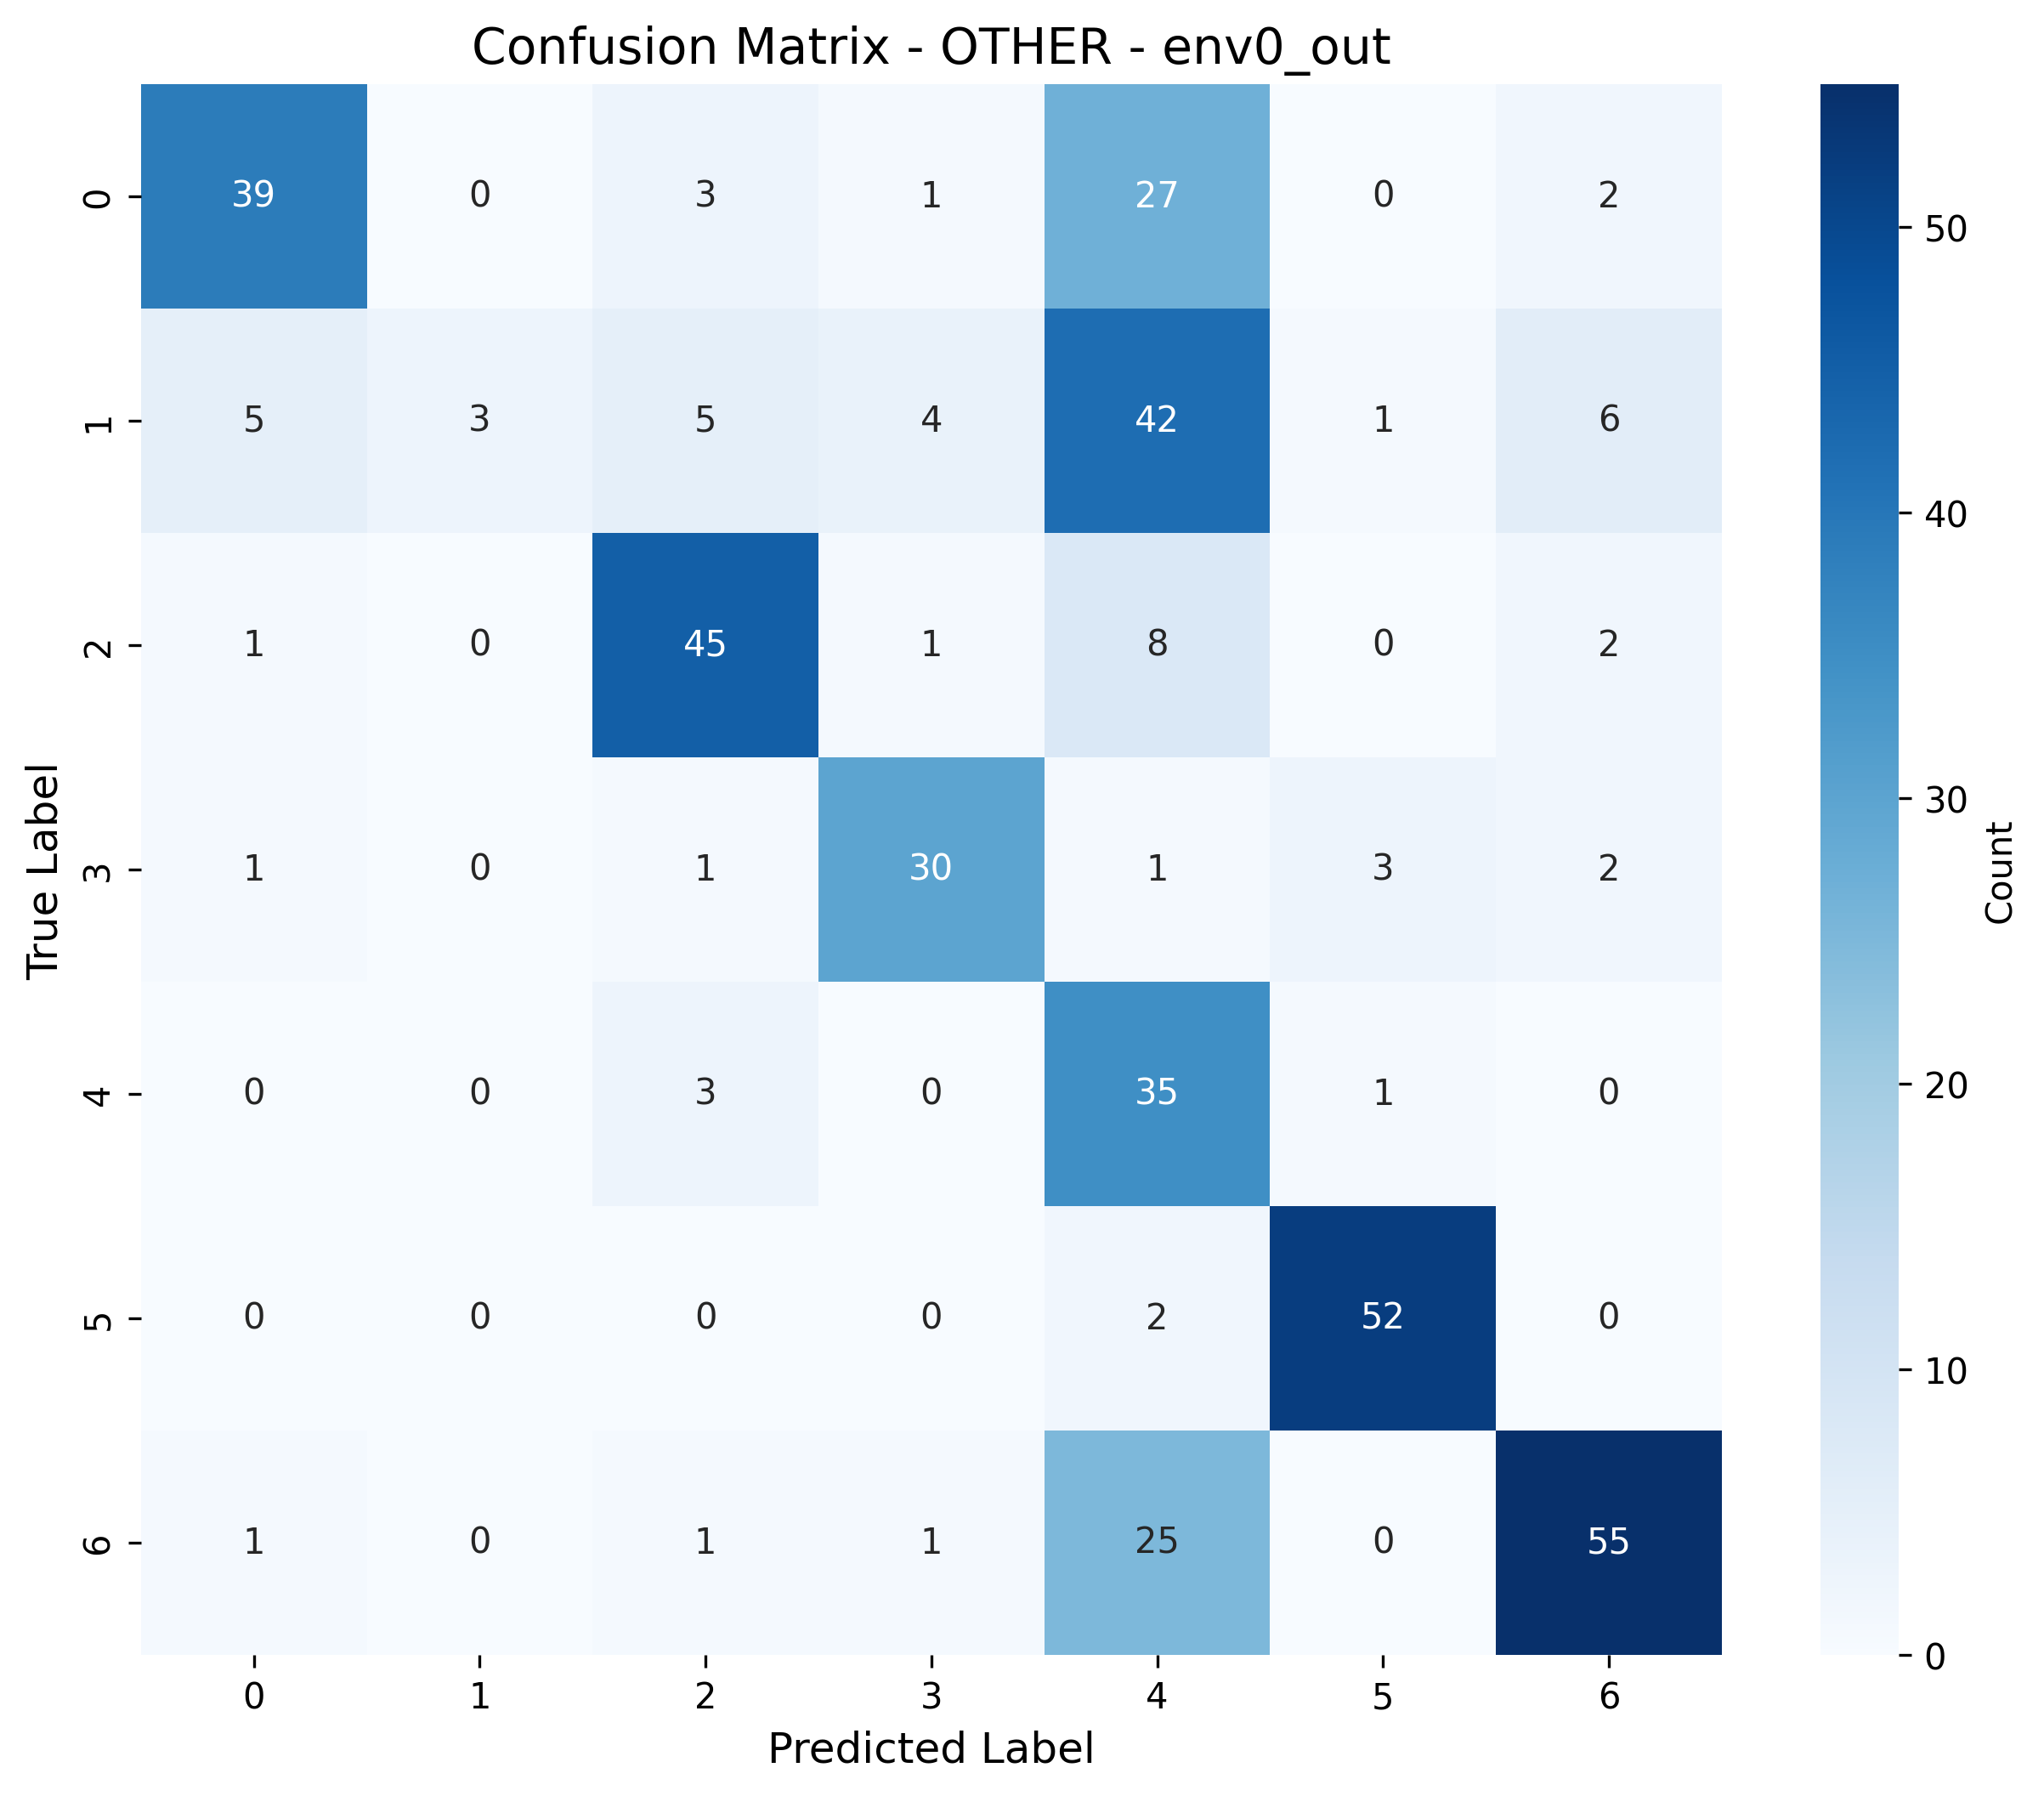


confusion_matrix_TEST_env0_in.png


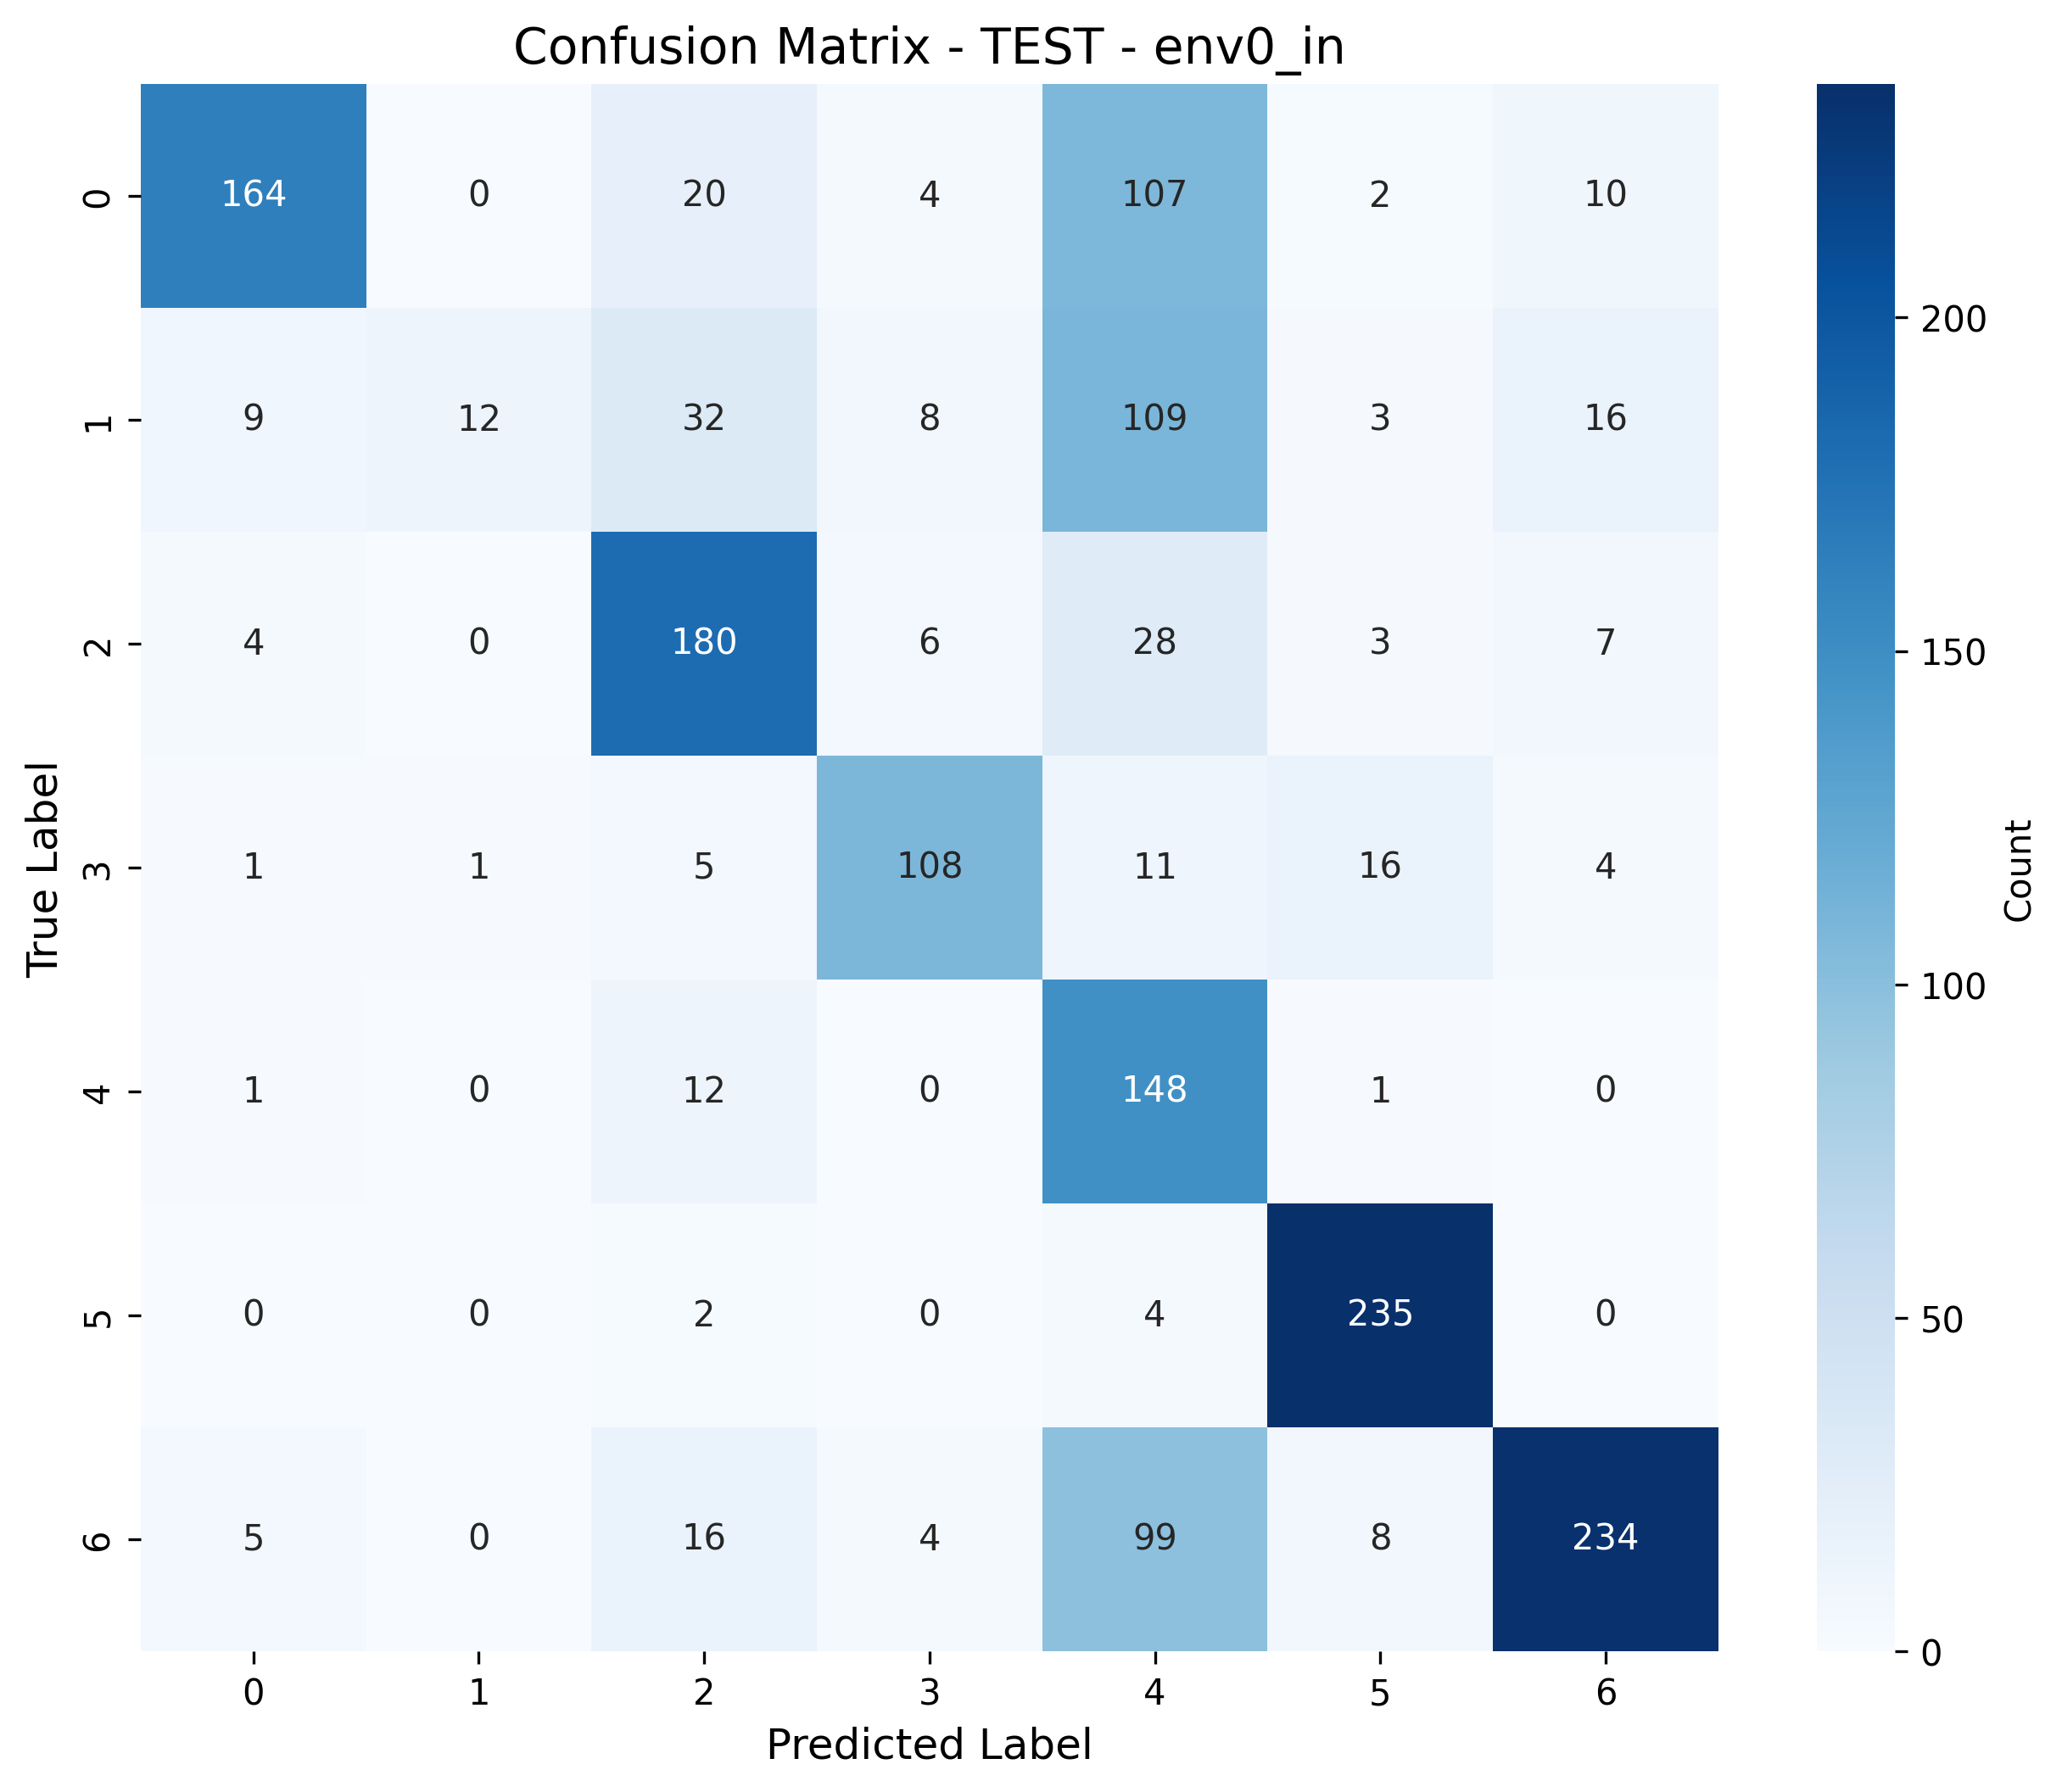


confusion_matrix_TRAIN_env1_in.png


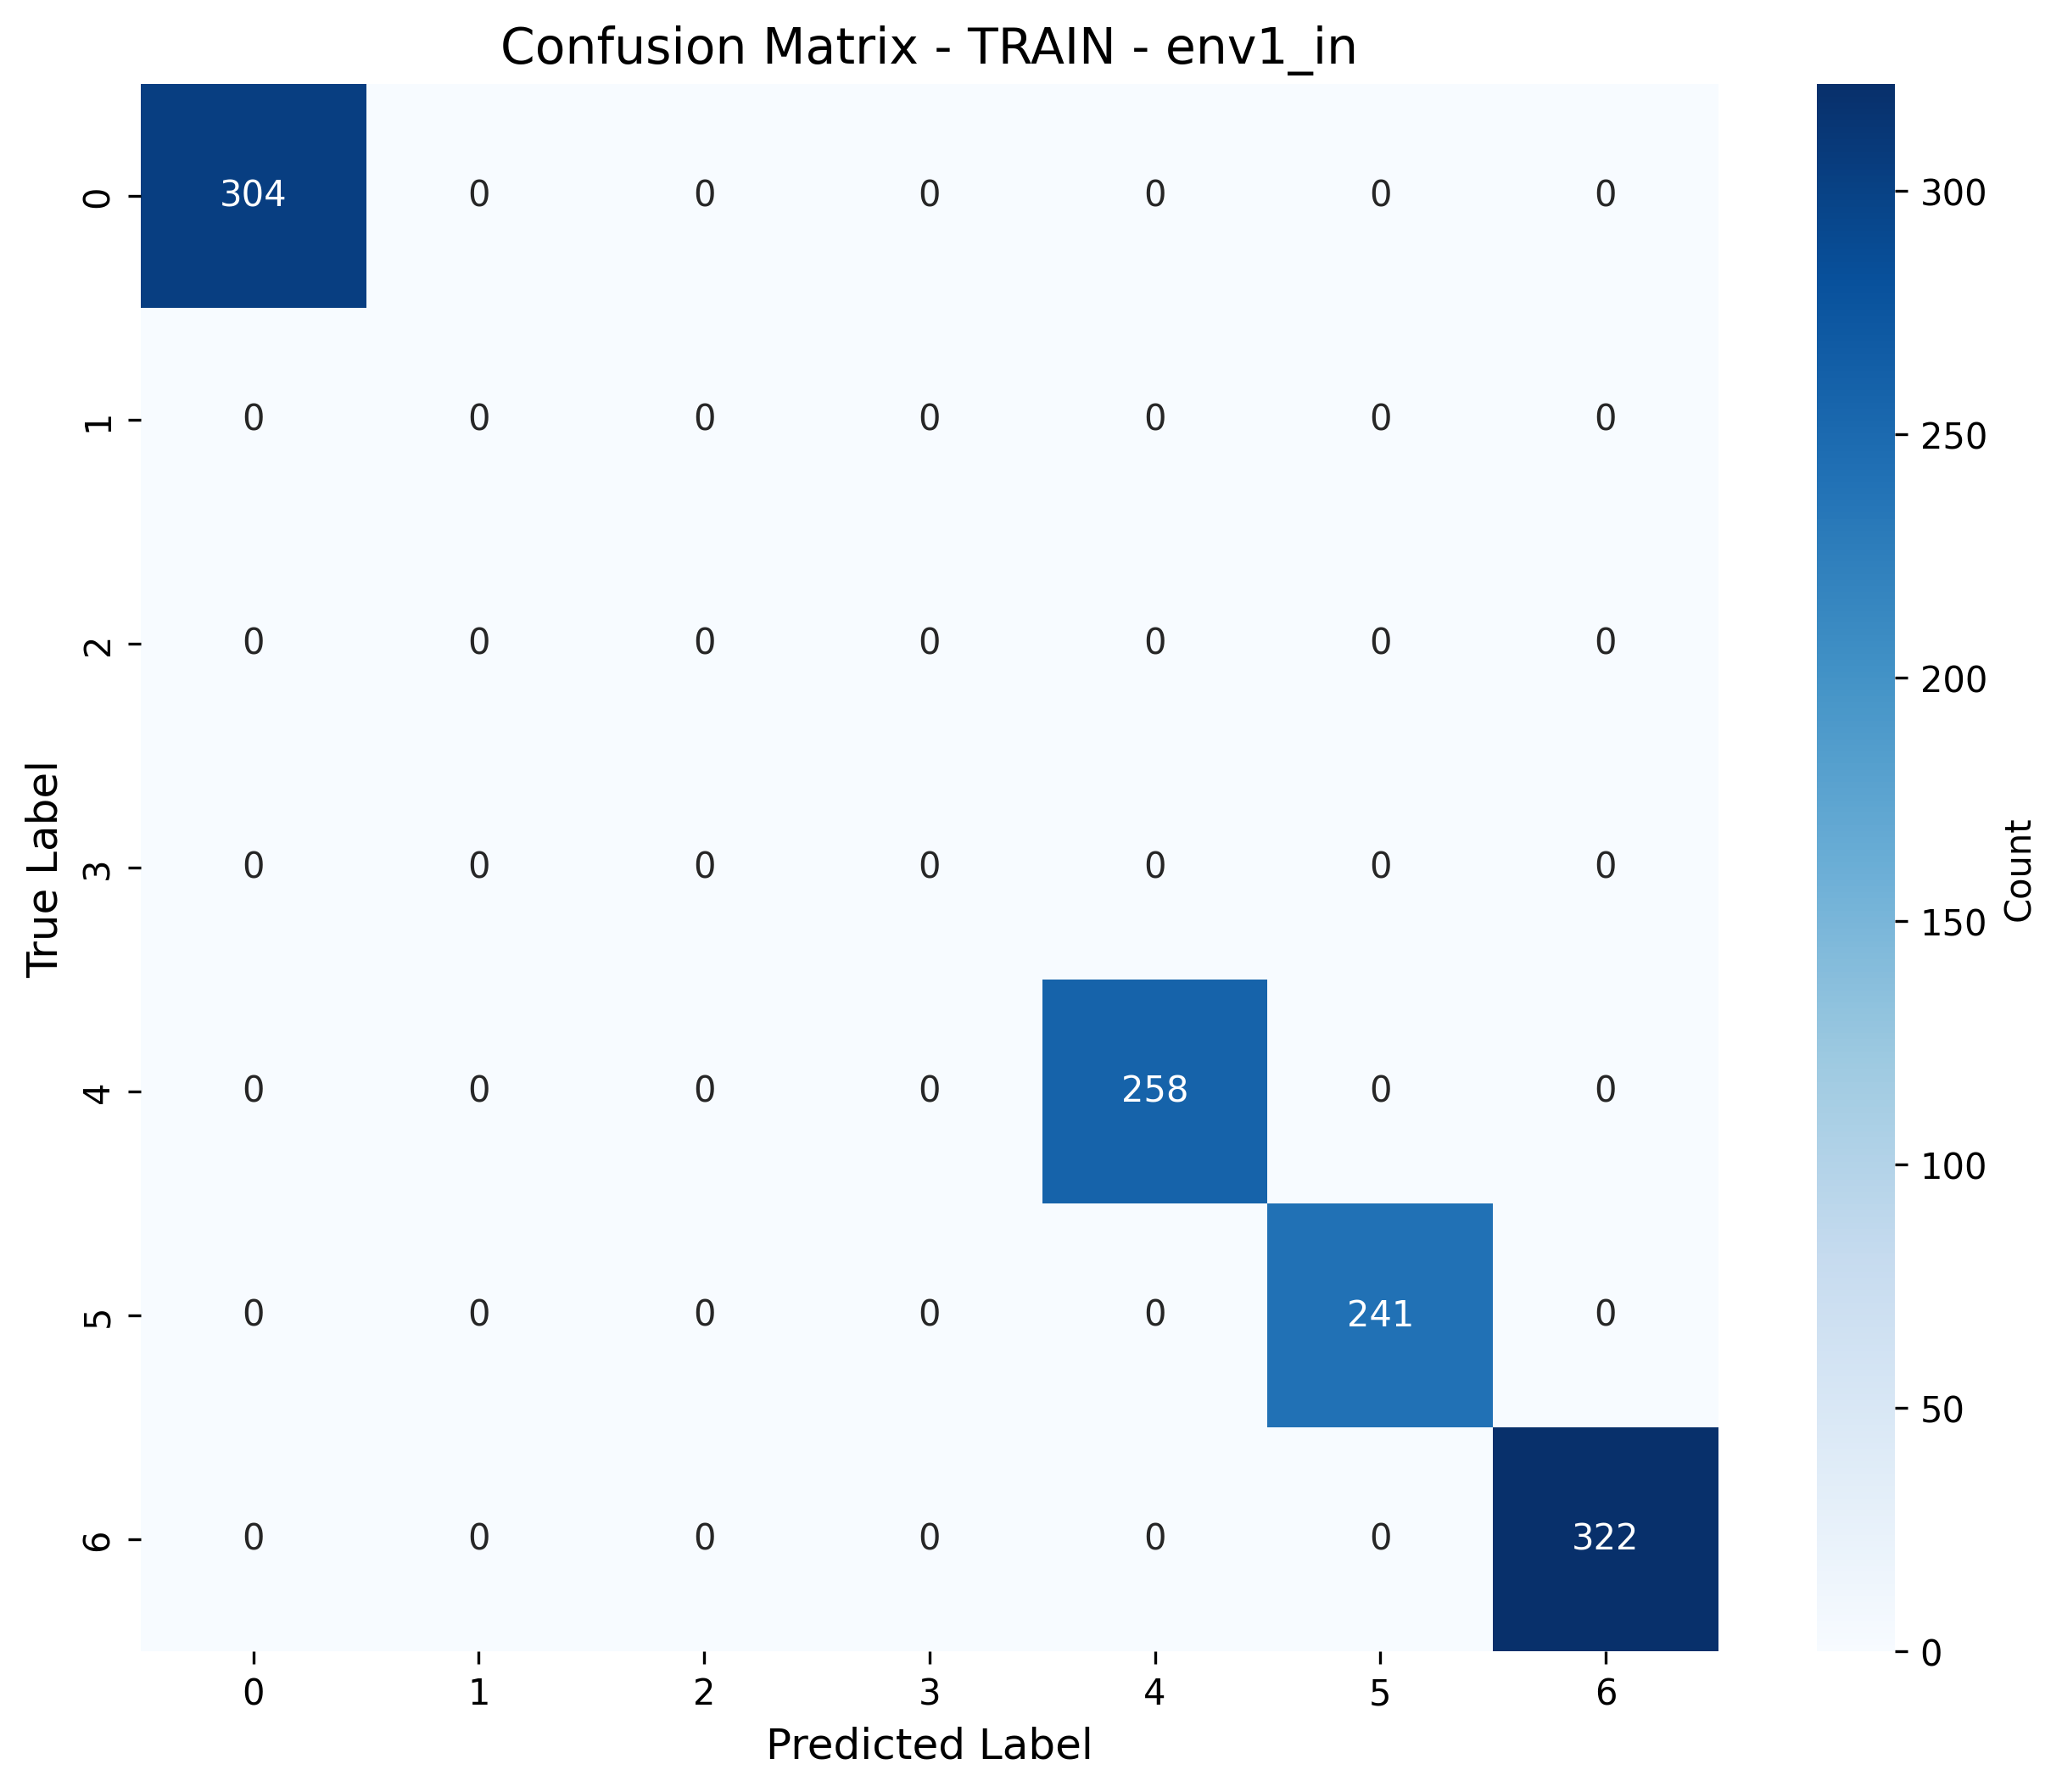


confusion_matrix_TRAIN_env2_in.png


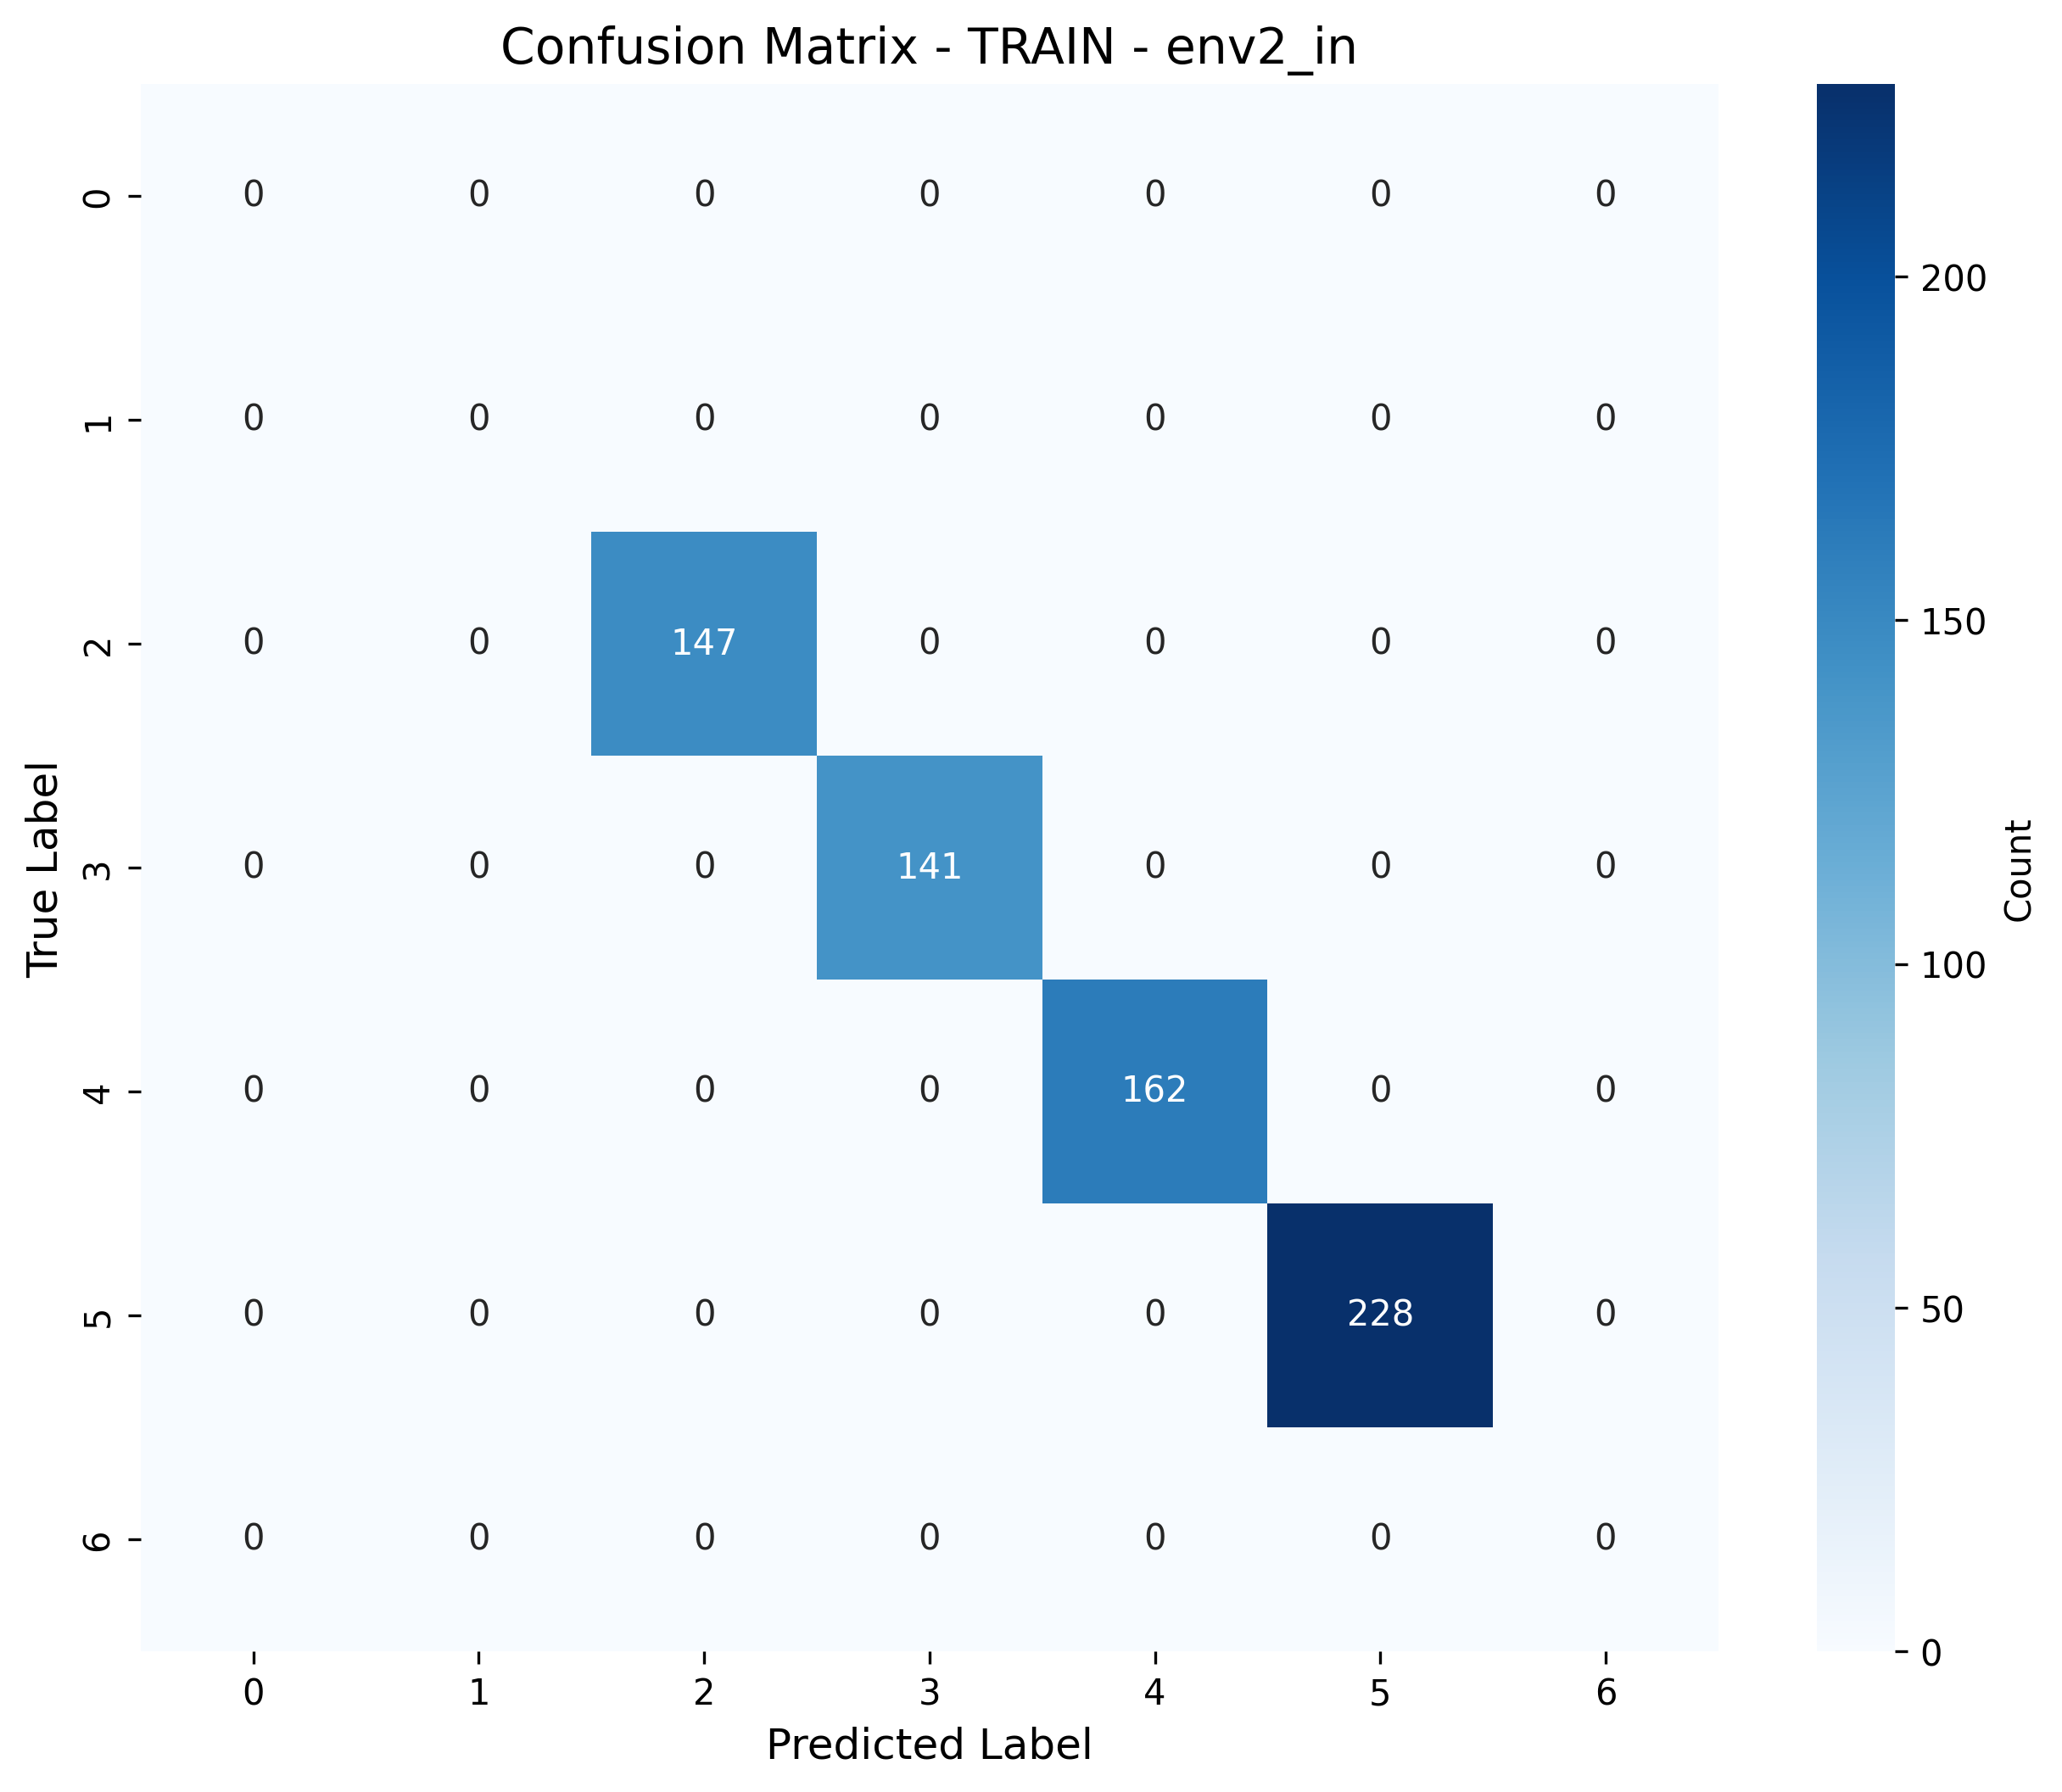


confusion_matrix_TRAIN_env3_in.png


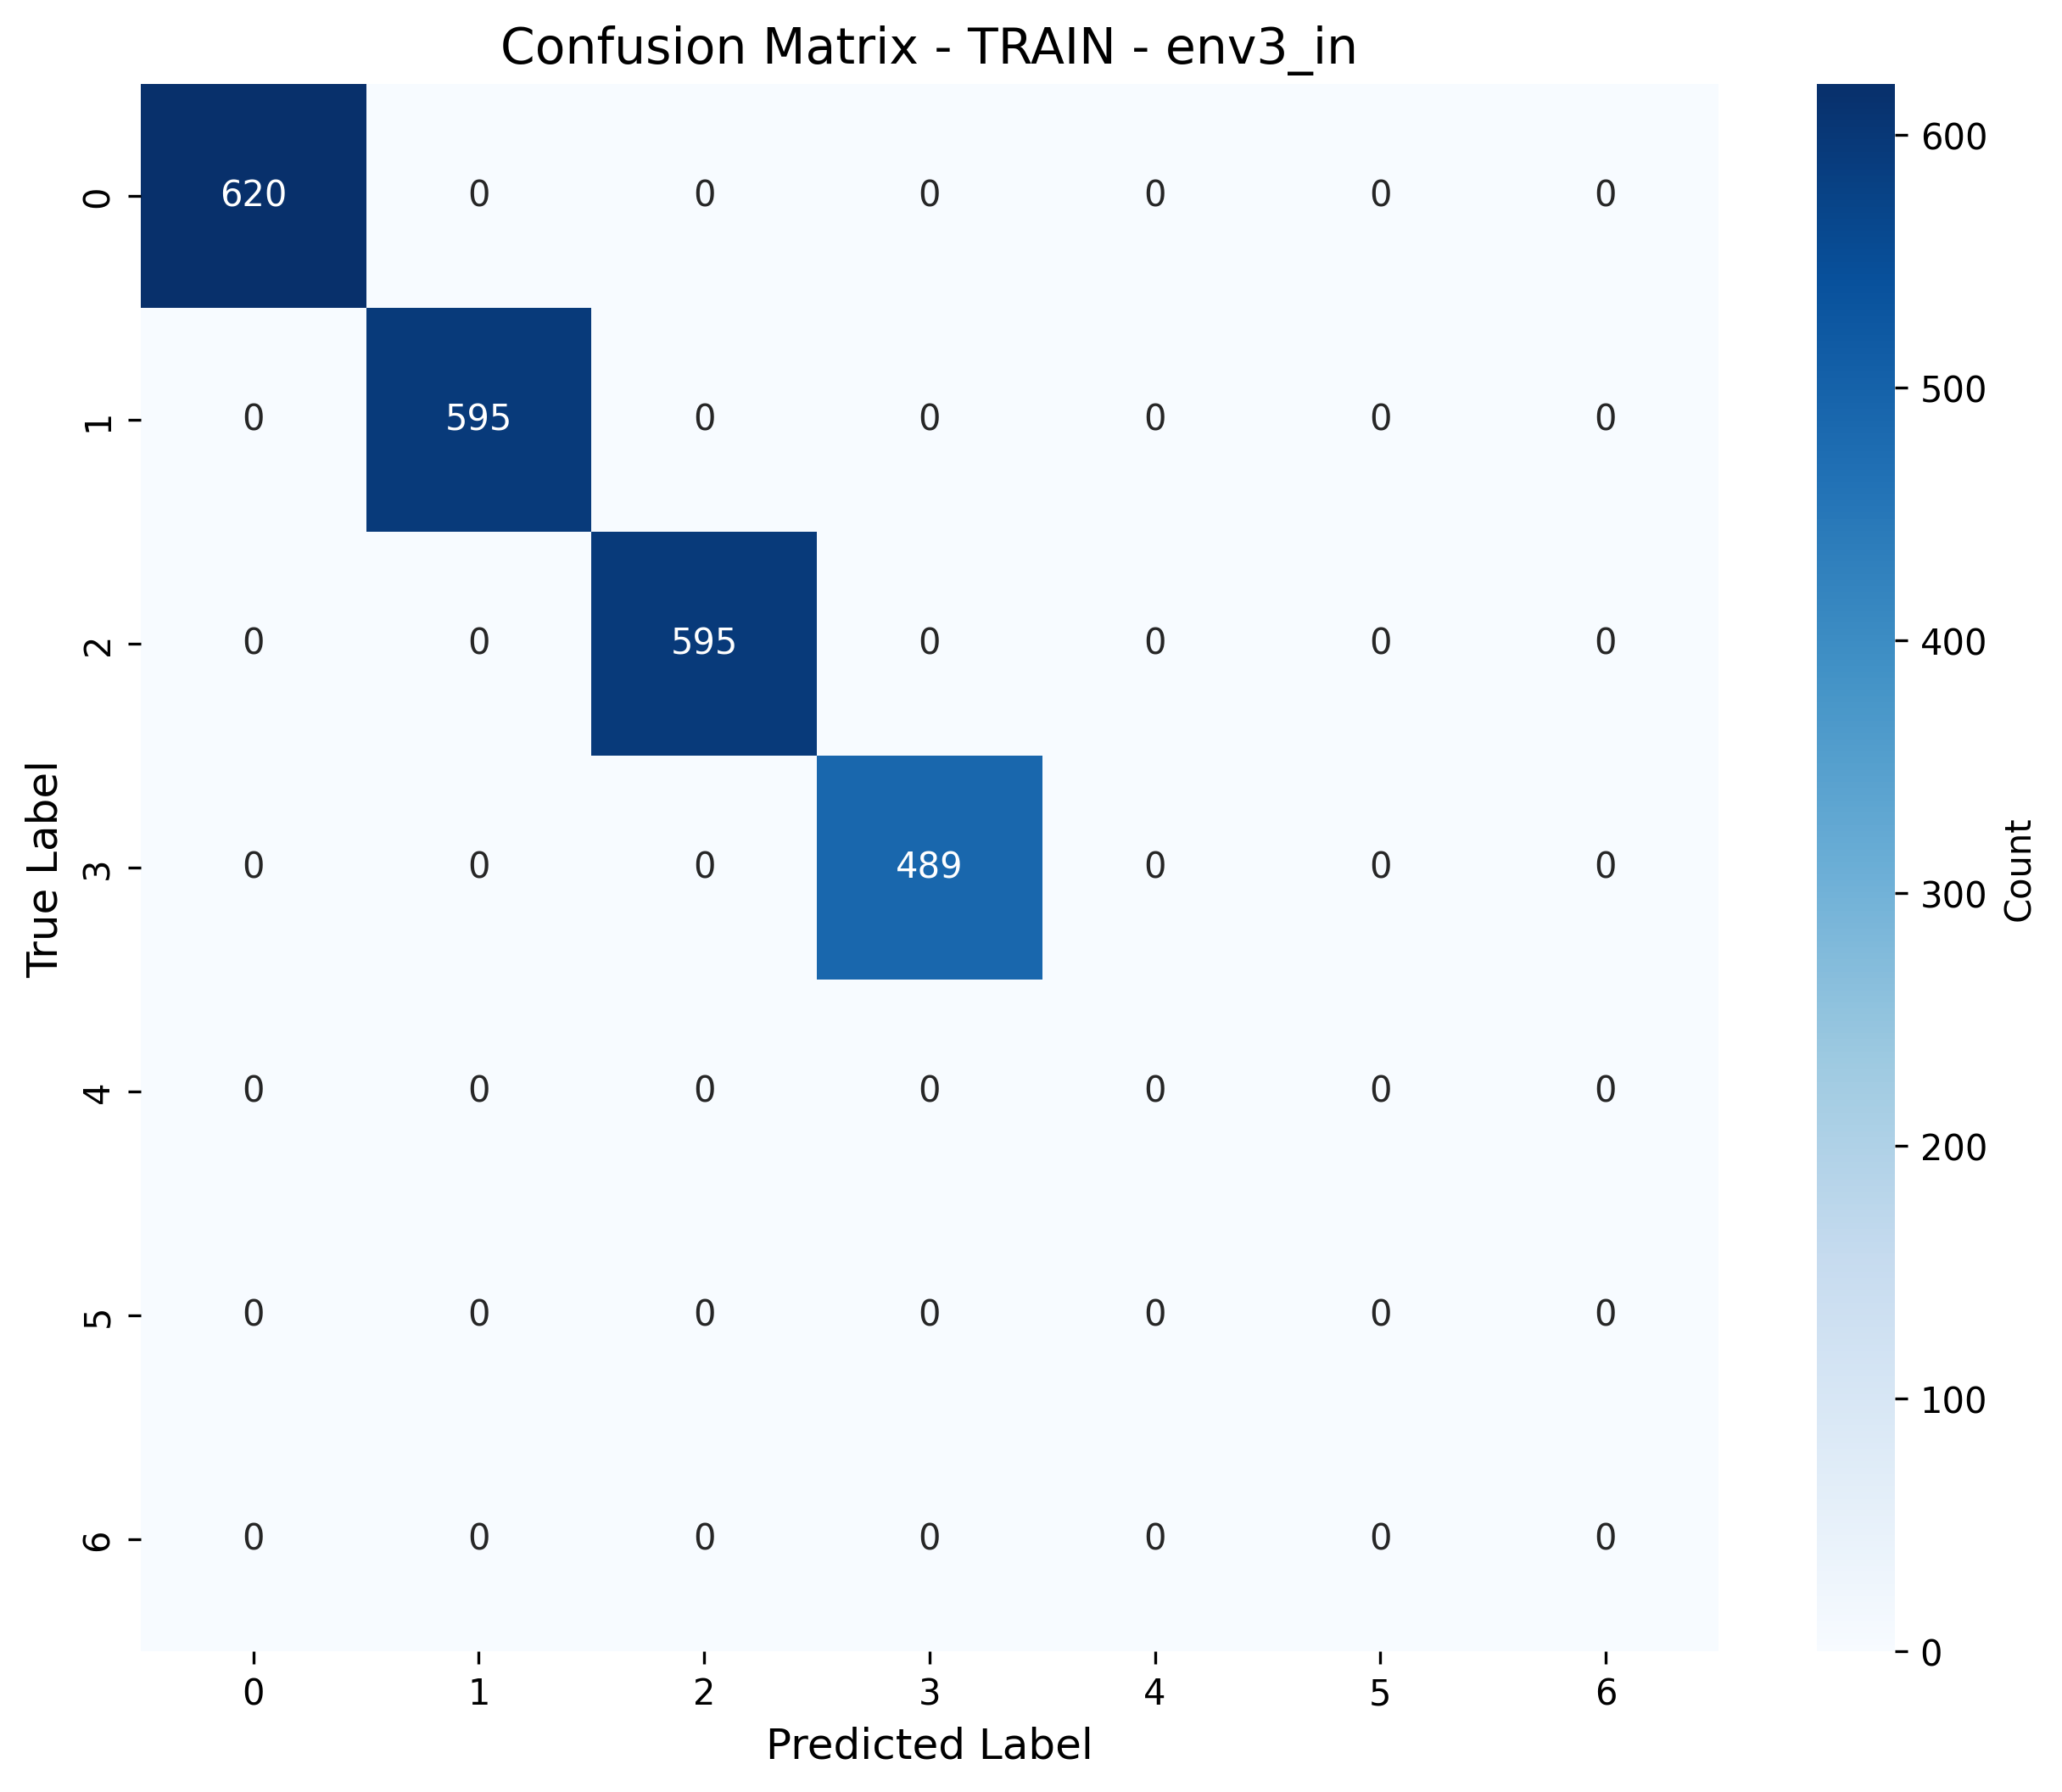


confusion_matrix_VAL_env1_out.png


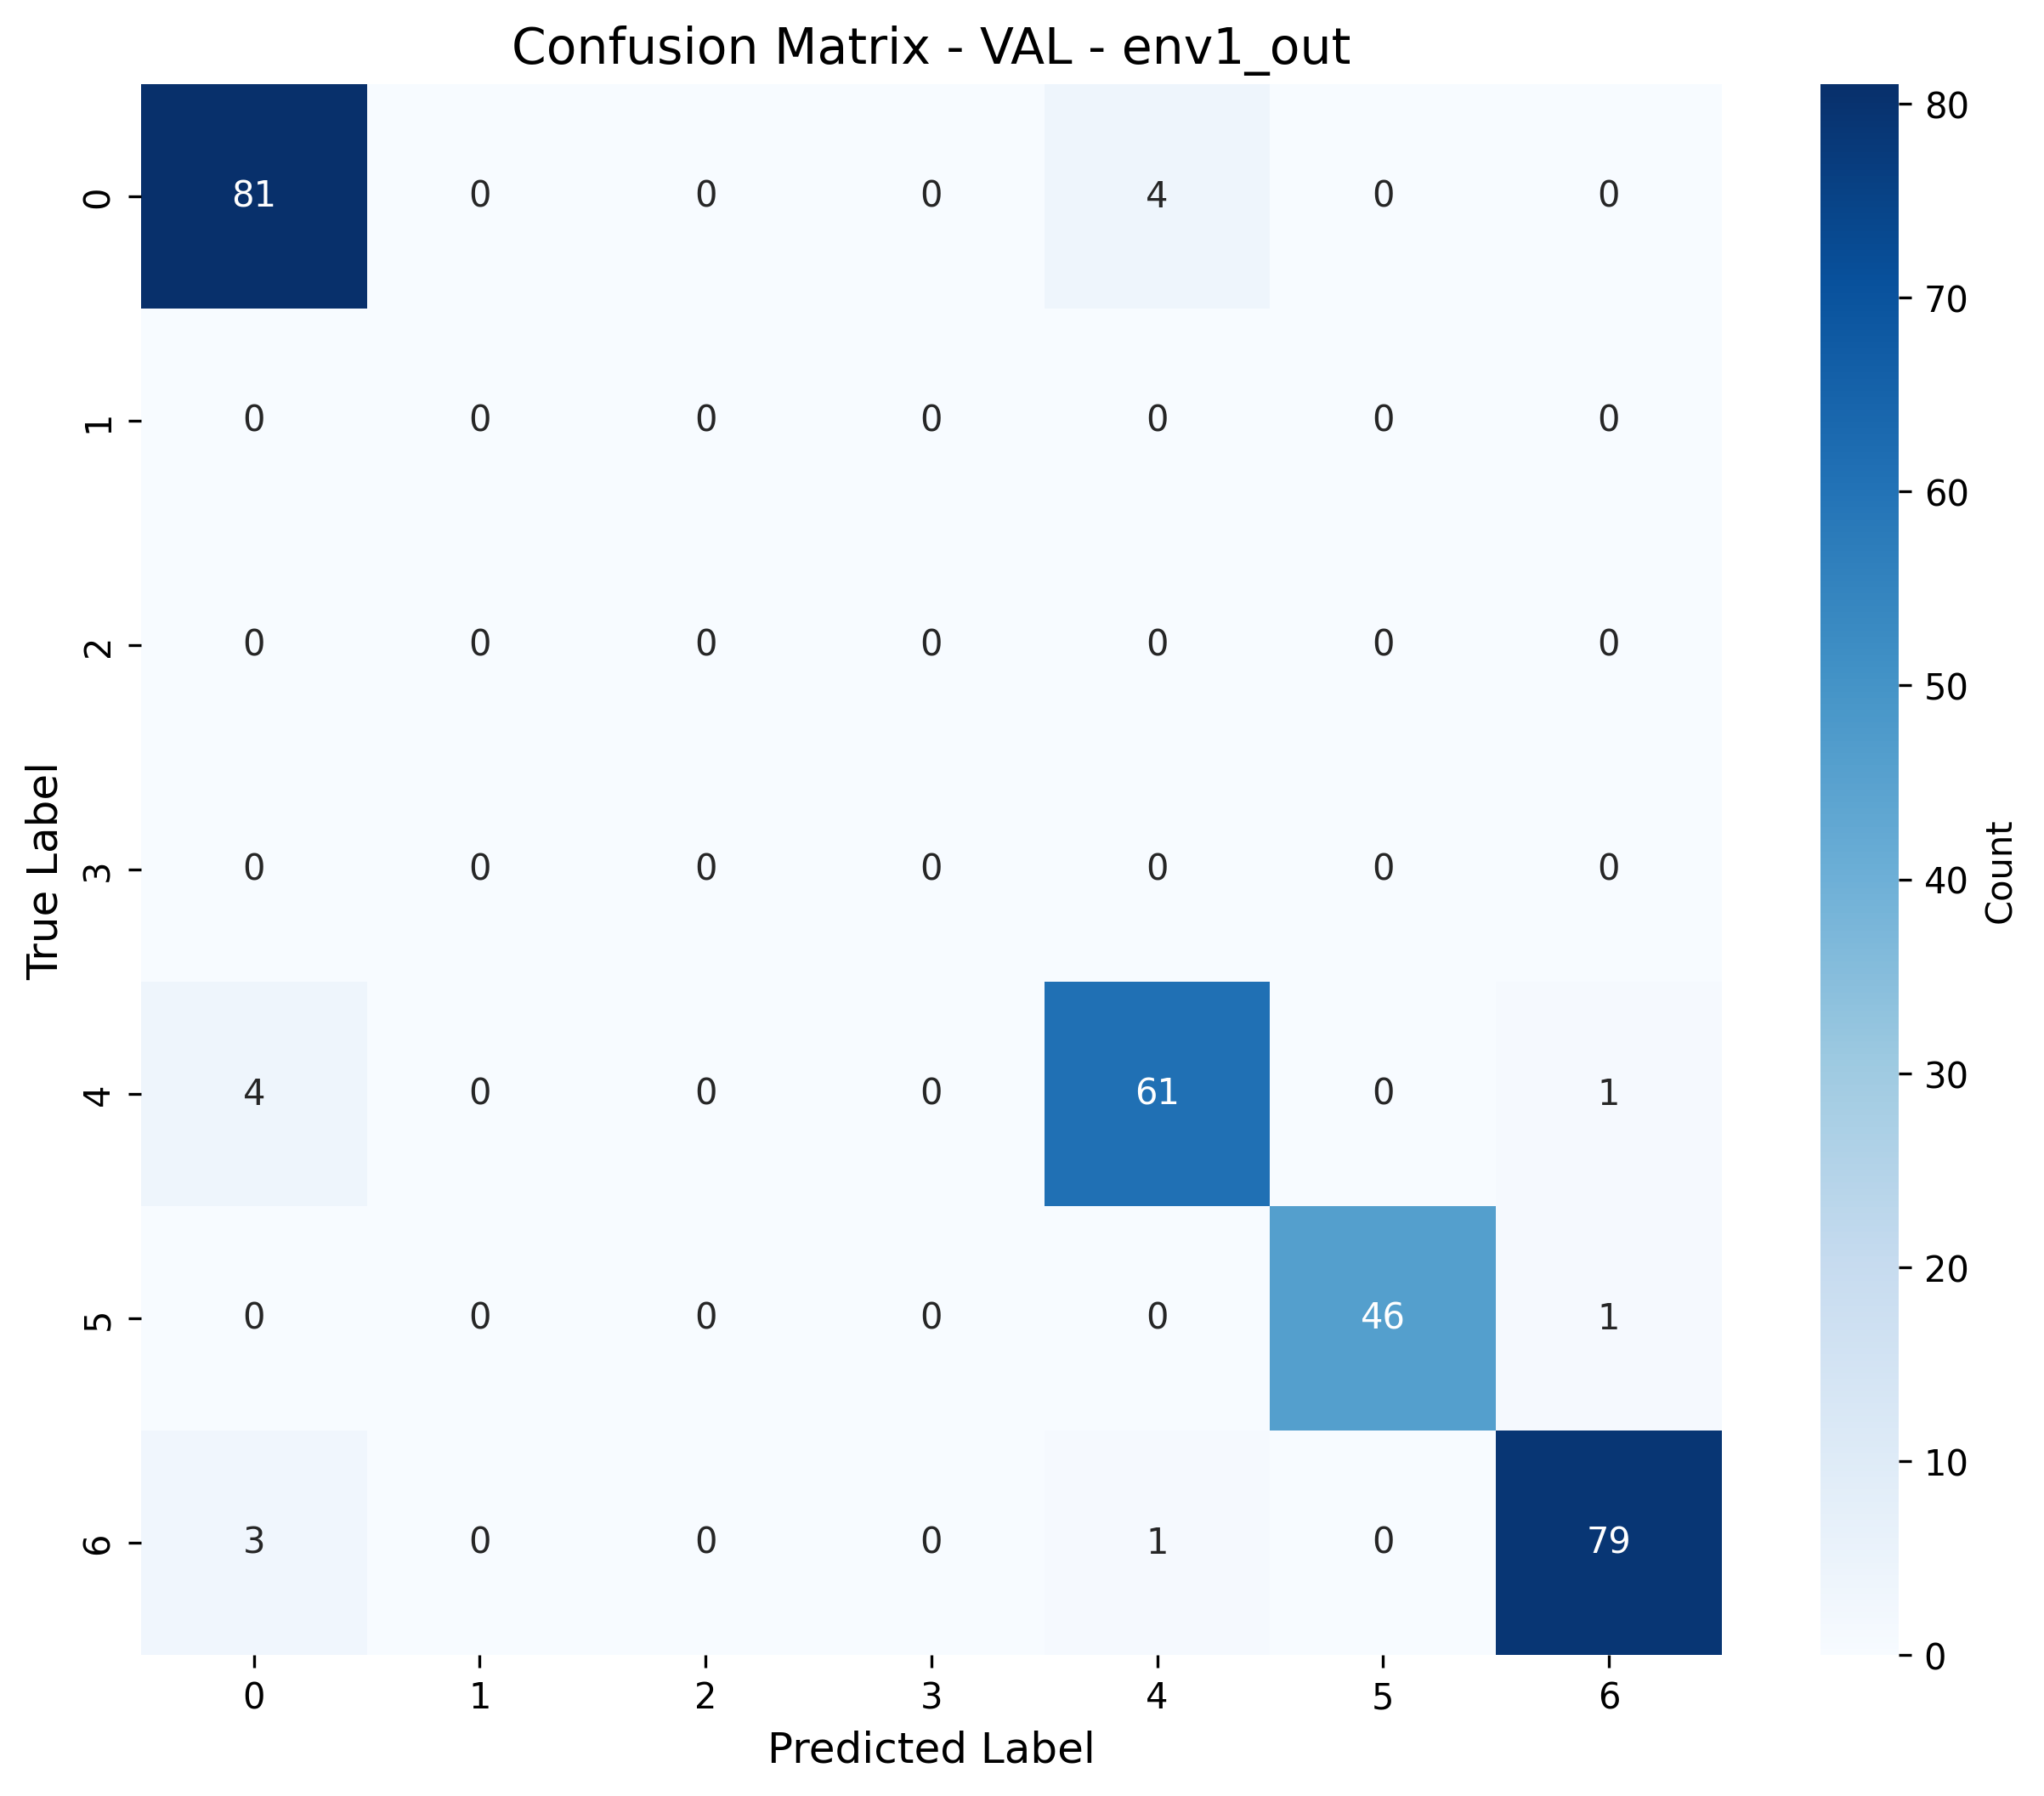


confusion_matrix_VAL_env2_out.png


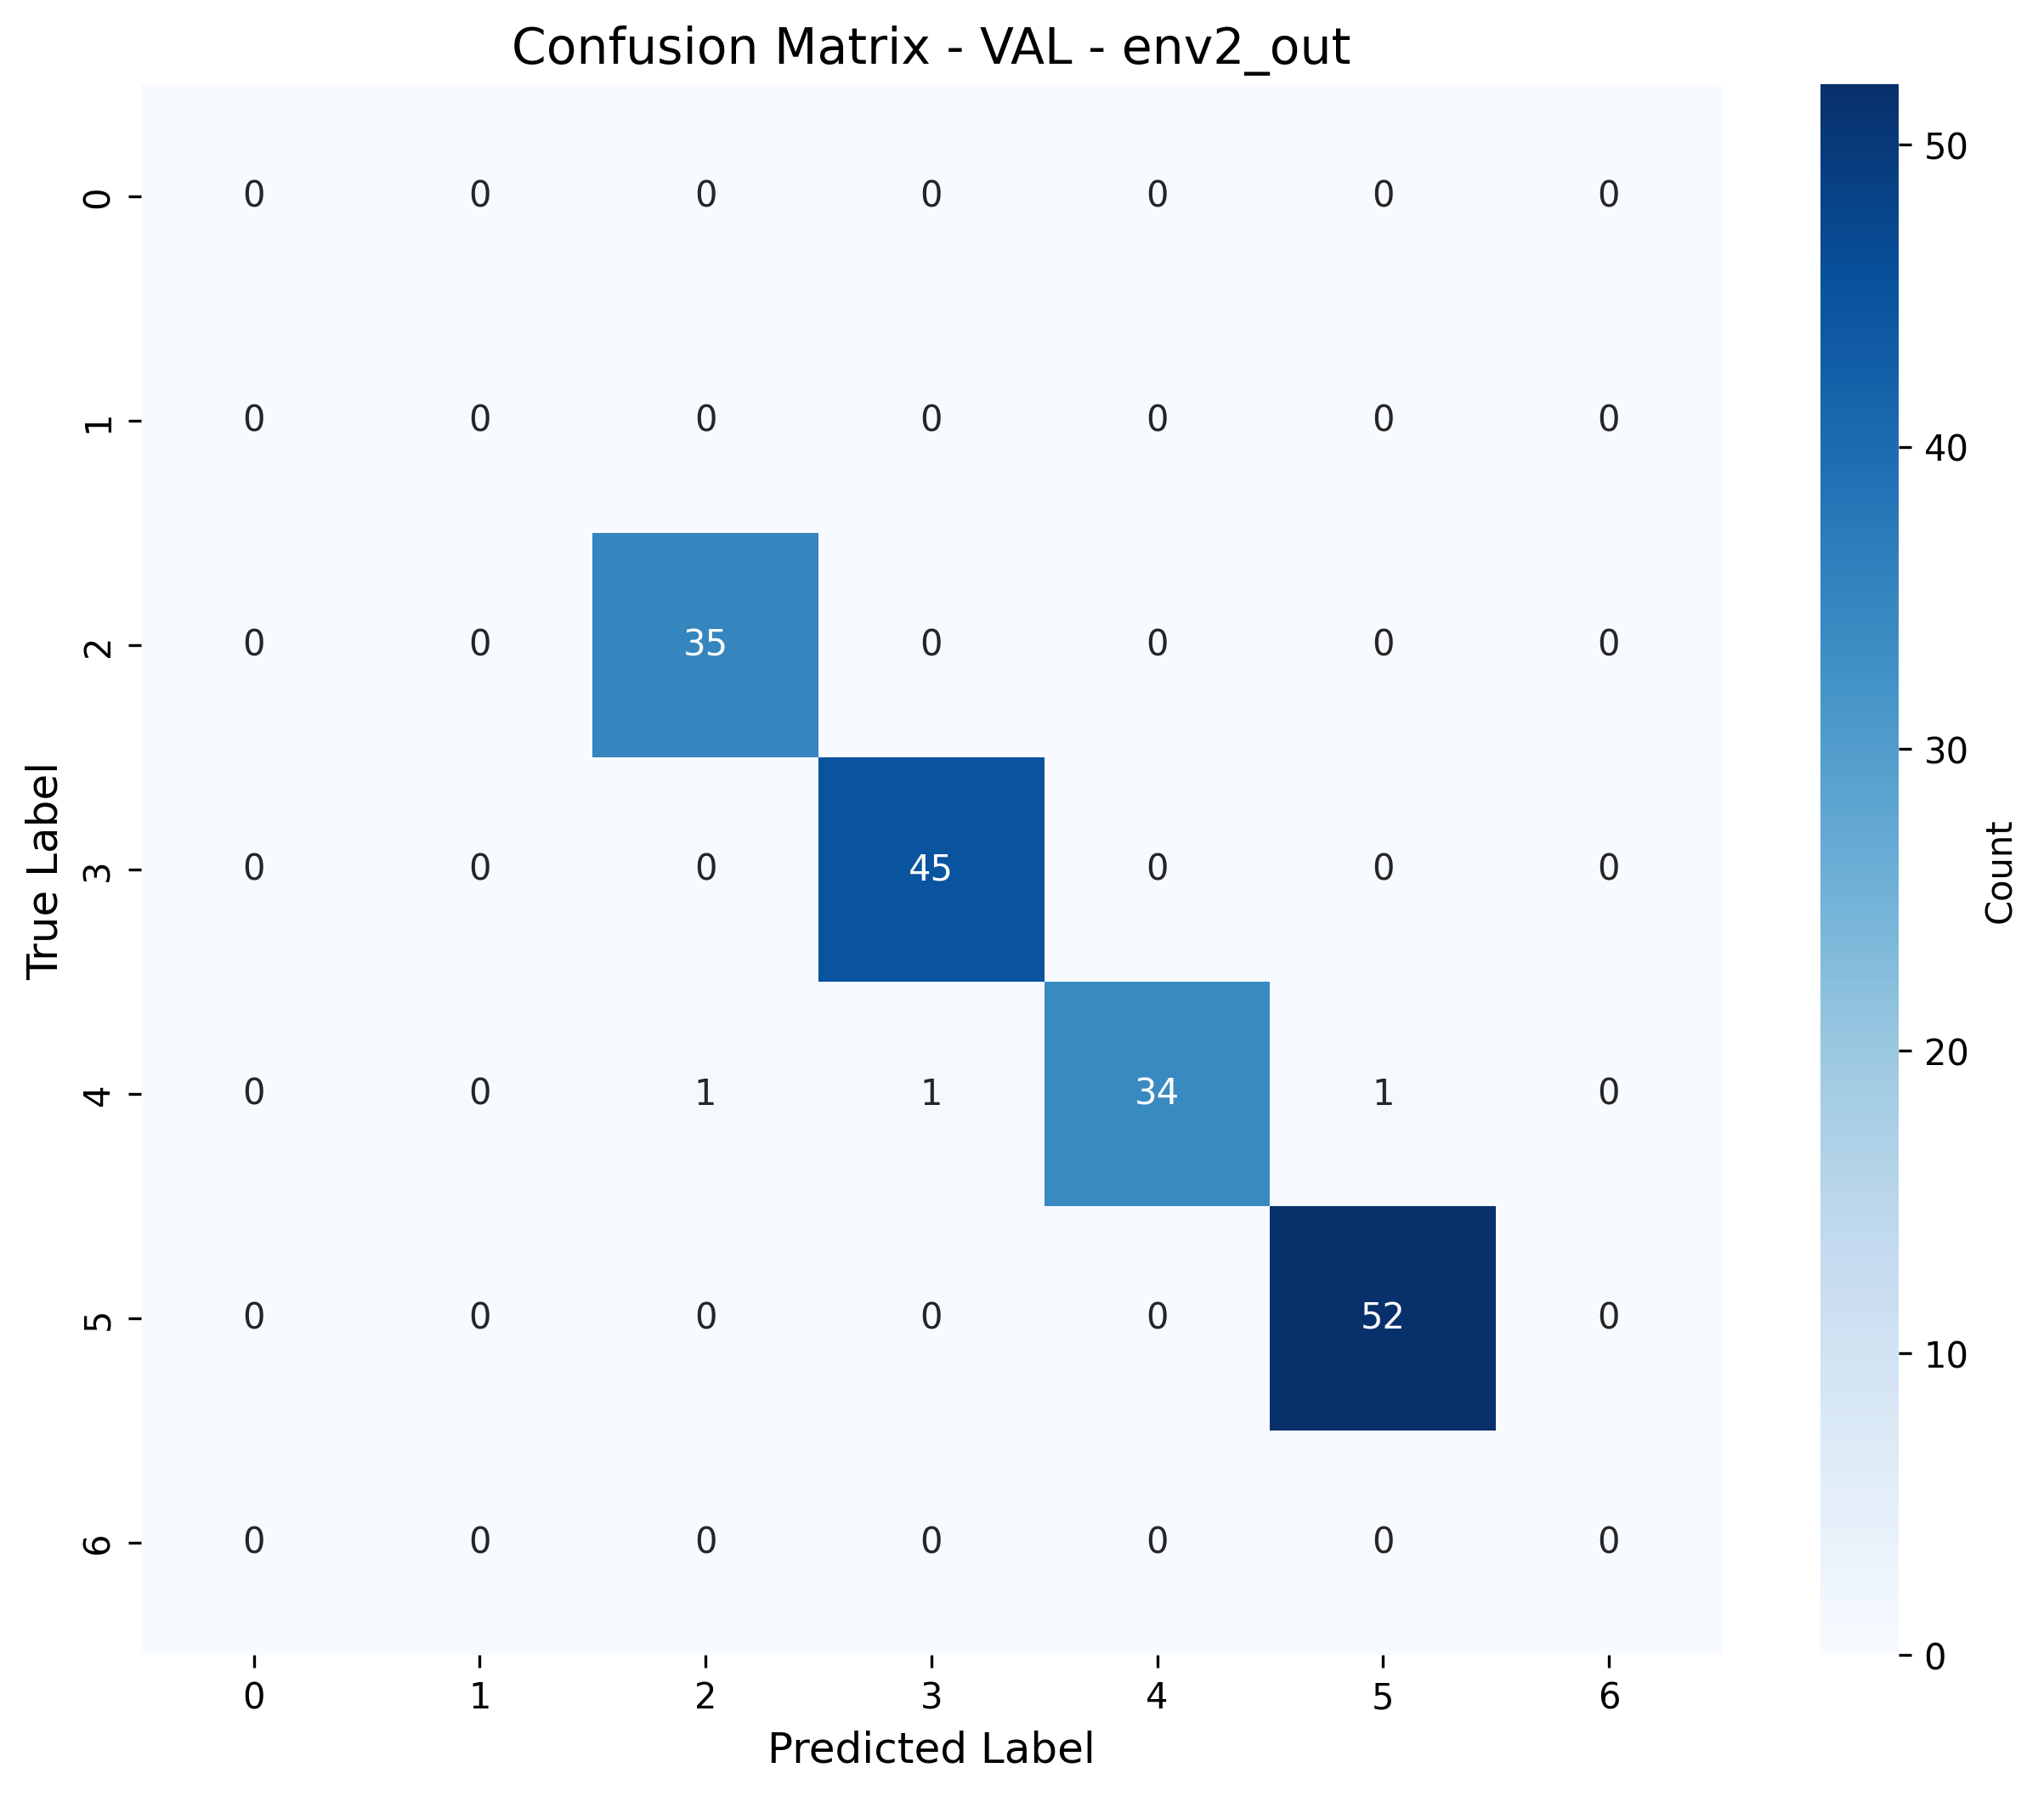


confusion_matrix_VAL_env3_out.png


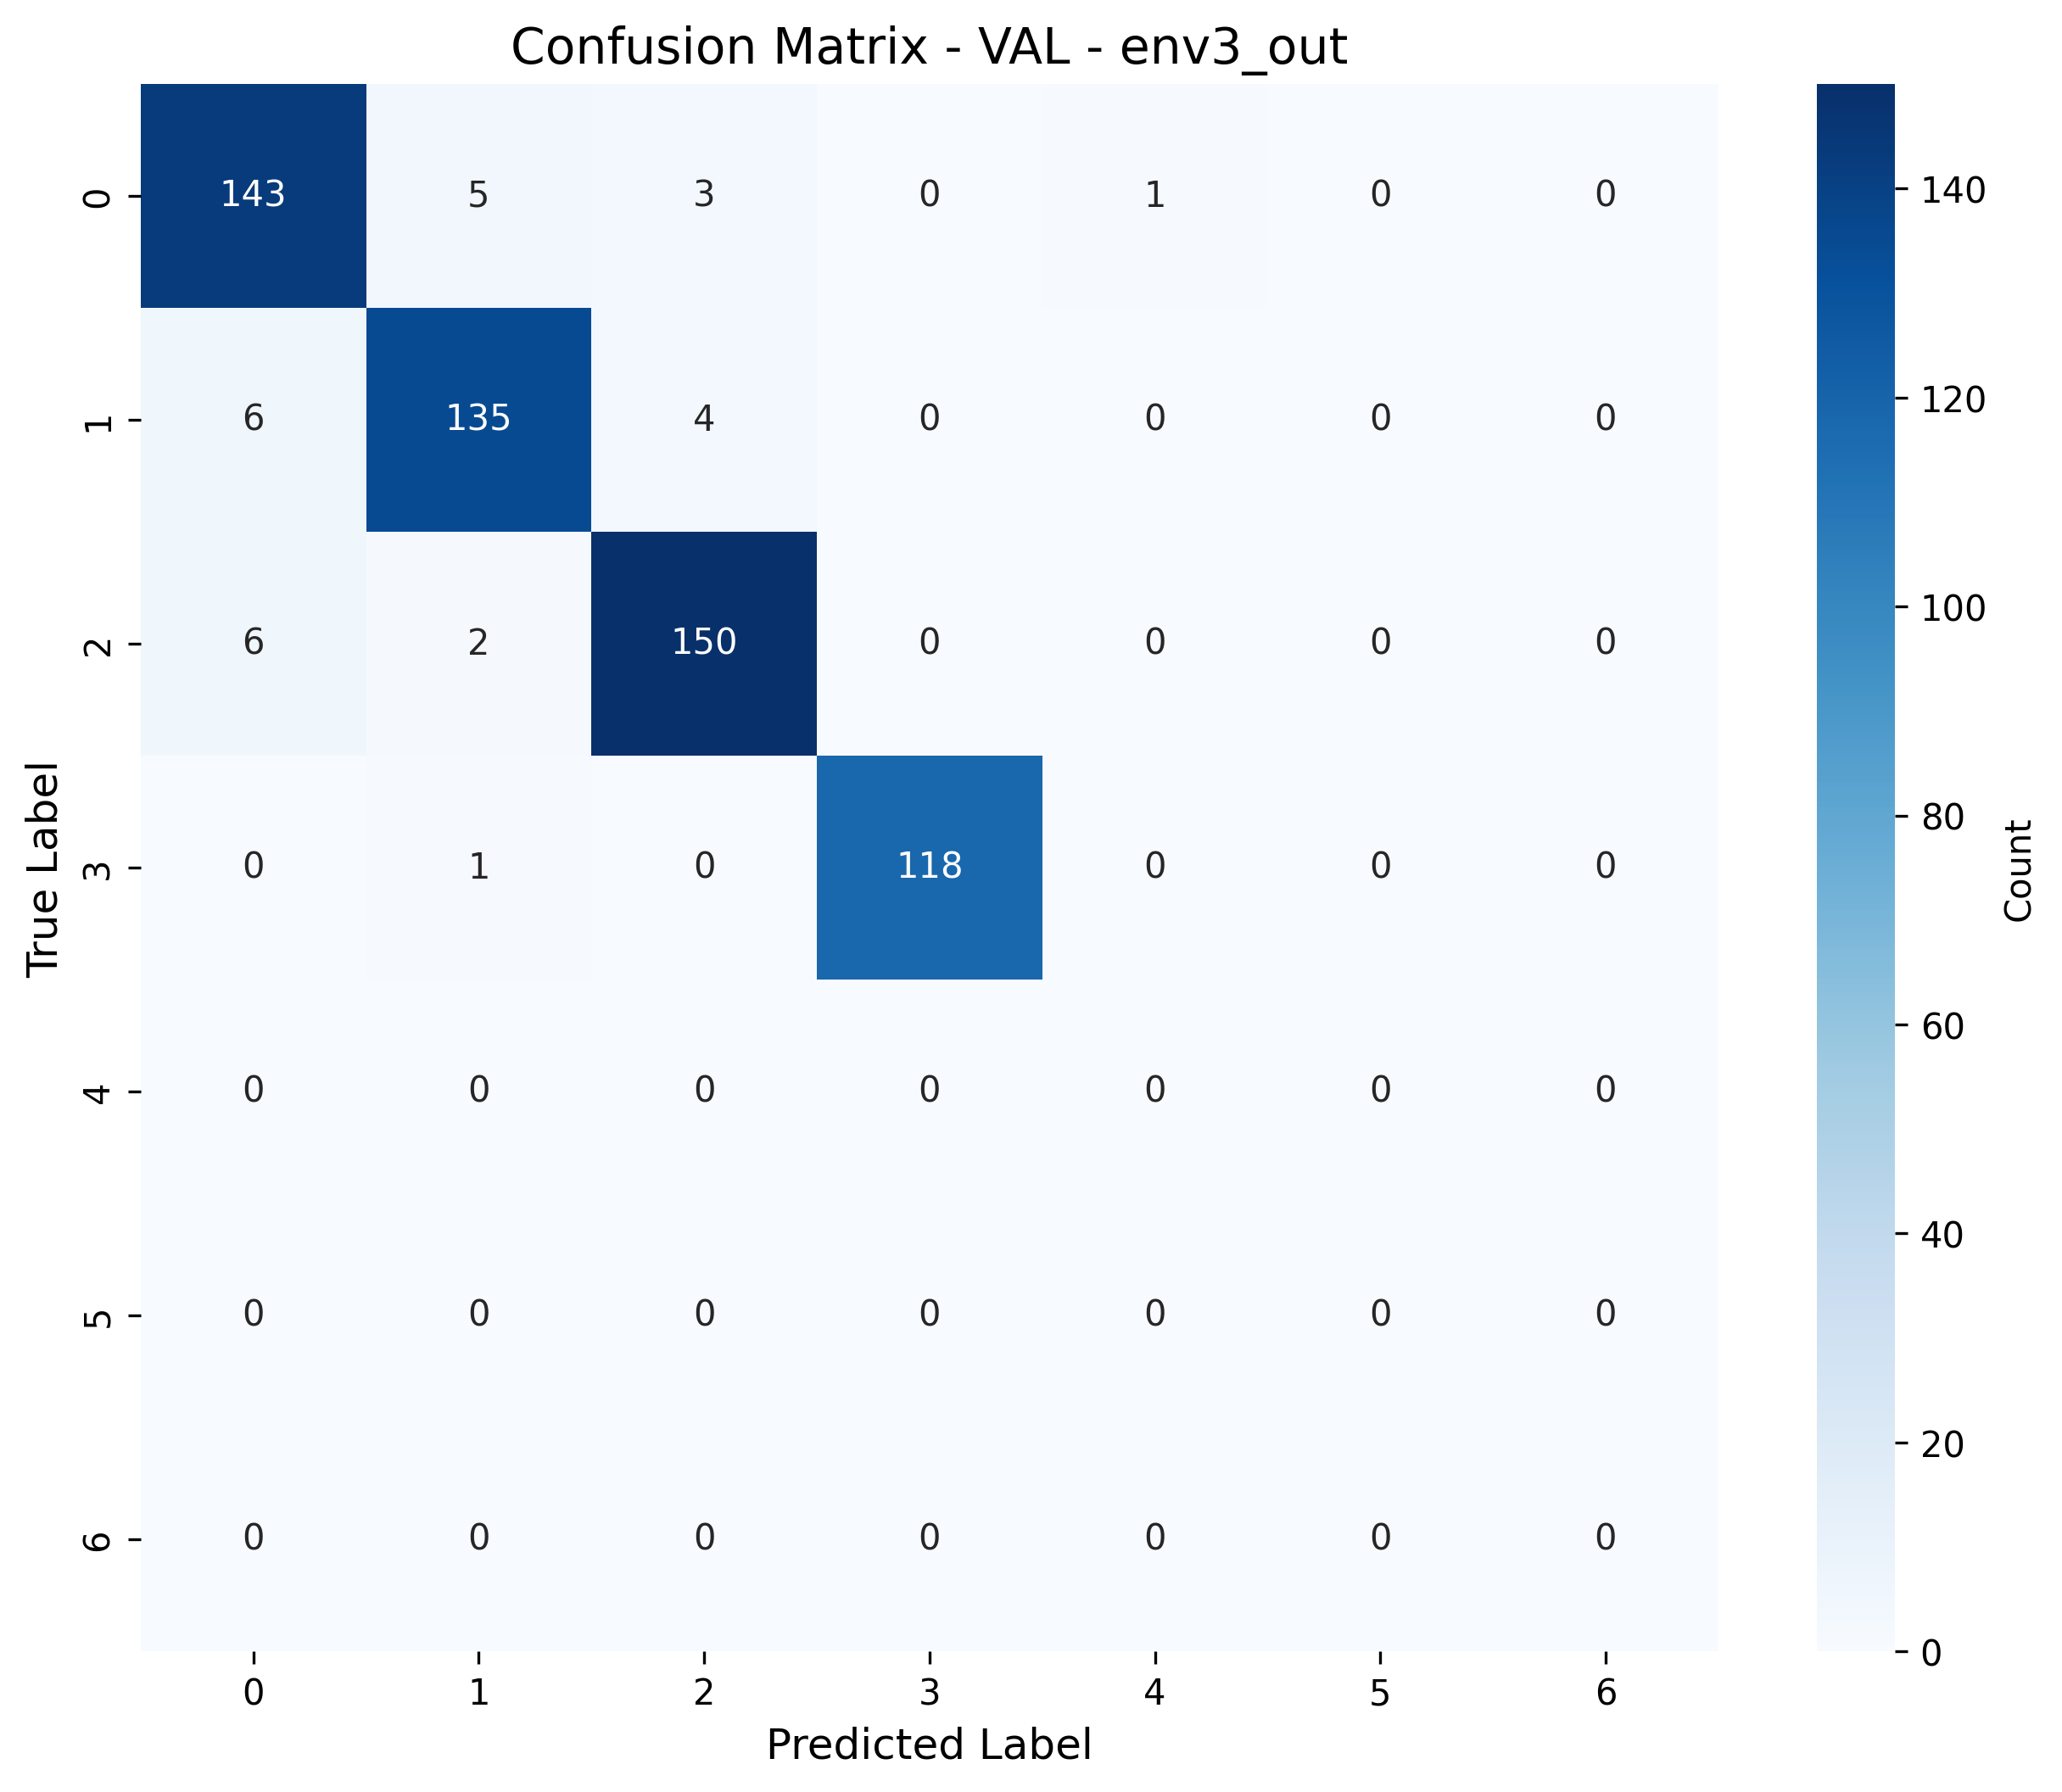



EPOCH TIMES:


In [ ]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_pacs = input()
config["name"] = exp_name_pacs

exp_name_pacs = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_pacs
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging

config_logging()
logging.info(f"Starting experiment: {exp_name_pacs}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)## VLCS
dataset_name_pacs = config["dataset"][0]
print(dataset_name_pacs)



config["backbone"] = "resnet"
# config["swin_variant"] = "swin_t"  # or "swin_s", "swin_b"
# config["swin_dropout"] = 0.1
config["use_autoaugment"] = False
config["algo"] = "FOND_LearnableWeights"


# Best hyperparameters from Optuna (only for FOND on PACS)
best_hparams = {

    "temperature":0.06007317553938885,
    "xda_alpha": 7.19638557715368,
    "xda_beta":2.5328261226968136,
    "weight_lr": 2.791213681687493e-05,
    "lr": 5.9434804260774536e-05,
    "weight_decay":  0.0011349686899067024,
    "batch_size": 32
}

# Clone config and add best hparams
config_pacs = config.copy()
config_pacs.update(best_hparams)  # Merge in the tuned hyperparameters

fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,
    seed=config_pacs.get("seed", 0),
    trial_seed=config_pacs.get("trial_seed", 0),
    hparams_seed=config_pacs.get("hparams_seed", 0),
    algorithm_name=config_pacs["algo"],
    dataset_name=dataset_name_pacs,
    data_dir=config_pacs["data_dir"][dataset_name_pacs],
    num_workers=4,
    test_envs=[config_pacs["test_set_id"]],
    overlap_type=config_pacs.get("overlap", "none"),
    holdout_fraction=config_pacs.get("holdout_fraction", 0.2),
    n_steps=config_pacs.get("n_epochs"),
    checkpoint_freq=config_pacs.get("checkpoint_freq"),
    model_checkpoint=config_pacs.get("model_checkpoint", {
        "metric": "val/acc",
        "maximize": True
    }),
    num_domain_linked_classes=config_pacs.get("num_domain_linked_classes"),
    num_classes=config_pacs.get("num_classes"),
    auto_augment=False,
    augment_search_epochs=config_pacs.get("augment_search_epochs", 10),
    config=best_hparams  # ← Pass the tuned hyperparameters here
)

logging.info(f"Experiment complete. Results saved to {exp_dir}")
print(f"\n✓ Experiment complete!")
print(f"  Results: {exp_dir / 'metrics_pacs.csv'}")
print(f"  Best model: {exp_dir / 'best_model_pacs.ckpt'}")
print(f"  Config: {exp_dir / 'config_pacs.json'}")





import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

log_dir = f"/kaggle/working/experiments/{exp_name_pacs}/logs"

# Get all confusion matrix plot files
cm_files = [f for f in os.listdir(log_dir) if f.startswith('confusion_matrix_') and f.endswith('.png')]

# Display all confusion matrices
print("CONFUSION MATRICES:")
print("="*60)
for cm_file in sorted(cm_files):
    print(f"\n{cm_file}")
    display(Image(filename=os.path.join(log_dir, cm_file)))

# # Display training curves
# print("\n\nTRAINING CURVES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'training_curves_PACS.png')))

# # Display epoch times
print("\n\nEPOCH TIMES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'epoch_times_PACS.png')))


## OfficeHome

This block independently tunes OfficeHome and trains the final model using the saved OfficeHome best parameters.

### Optuna tuning

In [ ]:
# Create Optuna study
import optuna
from optuna.pruners import MedianPruner
from pathlib import Path

study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=50)
)

# Run optimization
n_trials = 20 # Adjust based on your compute budget

print(f"Starting Optuna optimization with {n_trials} trials...")
print(f"Dataset: {config['dataset'][2]}, Test Env: {config['test_set_id']}")
print(f"Optimizing: val/oacc (domain-shared class accuracy)\n")


study.optimize(lambda trial: objective_adapt(trial, 2), n_trials=n_trials)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest val/oacc: {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

### Final training with saved tuned parameters

In [ ]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_oh = "exp_oh_adaptive_coeff_logged"
config["name"] = exp_name_oh

exp_name_oh = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_oh
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging

config_logging()
logging.info(f"Starting experiment: {exp_name_oh}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)## VLCS
dataset_name_oh = config["dataset"][2]
print(dataset_name_oh)



config["backbone"] = "resnet"
# config["swin_variant"] = "swin_t"  # or "swin_s", "swin_b"
# config["swin_dropout"] = 0.1
config["use_autoaugment"] = False
config["algo"] = "FOND_LearnableWeights"
# Best hyperparameters from Optuna (only for FOND on PACS)
best_hparams_oh = {
    'temperature': 0.08728925854485776,
    'xda_alpha': 5.42202933511941,
    'xda_beta': 1.2915747468185343,
    'weight_lr': 3.966889934708198e-05,
    'lr': 4.1019055764802154e-05,
    'weight_decay': 5.410285277898638e-06,
    'batch_size': 64
}

# Clone config and add best hparams
config_oh = config.copy()
config_oh.update(best_hparams_oh)  # Merge in the tuned hyperparameters

fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,
    seed=config_oh.get("seed", 0),
    trial_seed=config_oh.get("trial_seed", 0),
    hparams_seed=config_oh.get("hparams_seed", 0),
    algorithm_name=config_oh["algo"],
    dataset_name=dataset_name_oh,
    data_dir=config_oh["data_dir"][dataset_name_oh],
    num_workers=4,
    test_envs=[config_oh["test_set_id"]],
    overlap_type=config_oh.get("overlap", "none"),
    holdout_fraction=config_oh.get("holdout_fraction", 0.2),
    n_steps=config_oh.get("n_epochs"),
    checkpoint_freq=config_oh.get("checkpoint_freq"),
    model_checkpoint=config_oh.get("model_checkpoint", {
        "metric": "val/acc",
        "maximize": True
    }),
    num_domain_linked_classes=config_oh.get("num_domain_linked_classes"),
    num_classes=config_oh.get("num_classes"),
    auto_augment=False,
    augment_search_epochs=config_oh.get("augment_search_epochs", 10),
    config=best_hparams_oh  # ← Pass the tuned hyperparameters here
)

logging.info(f"Experiment complete. Results saved to {exp_dir}")
print(f"\n✓ Experiment complete!")
print(f"  Results: {exp_dir / 'metrics_oh.csv'}")
print(f"  Best model: {exp_dir / 'best_model_oh.ckpt'}")
print(f"  Config: {exp_dir / 'config_oh.json'}")





import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

log_dir = f"/kaggle/working/experiments/{exp_name_oh}/logs"

# Get all confusion matrix plot files
cm_files = [f for f in os.listdir(log_dir) if f.startswith('confusion_matrix_') and f.endswith('.png')]

# Display all confusion matrices
print("CONFUSION MATRICES:")
print("="*60)
for cm_file in sorted(cm_files):
    print(f"\n{cm_file}")
    display(Image(filename=os.path.join(log_dir, cm_file)))

# # Display training curves
# print("\n\nTRAINING CURVES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'training_curves_PACS.png')))

# # Display epoch times
print("\n\nEPOCH TIMES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'epoch_times_PACS.png')))


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


OfficeHome

HYPERPARAMETERS AFTER CONFIG OVERRIDE:
  backbone: resnet
  base_temperature: 0.07
  batch_size: 64
  class_balanced: False
  data_augmentation: True
  error_lmbd: 1
  lr: 4.1019055764802154e-05
  nonlinear_classifier: False
  resnet18: True
  resnet_dropout: 0.0
  temperature: 0.08728925854485776
  vit_attention_dropout: 0.0
  vit_dropout: 0.0
  vit_variant: vit_b_16
  weight_decay: 5.410285277898638e-06
  weight_lr: 3.966889934708198e-05
  xda_alpha: 5.42202933511941
  xda_beta: 1.2915747468185343
  xdom_lmbd: 1

DEBUG: overlap_type=high
DEBUG: domain_class_filter=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:11<00:00, 4.02MB/s]


...

LEARNED COEFFICIENTS: alpha_class=0.973882, beta_xdom=0.843976, gamma_error=0.917935

=== Step 5000 (Epoch 164.78) ===
step_time: 261.9595s
TRAIN:
  loss: 0.9789
  acc: 0.9788
  precision: 0.9798
  recall: 0.9788
  f1: 0.9792
  oacc: 0.7566
  nacc: 0.3325
VAL:
  loss: 0.6253
  acc: 0.6925
  precision: 0.7128
  recall: 0.6925
  f1: 0.6975
  oacc: 0.6535


100%|█████████▉| 5000/5001 [5:12:05<00:04,  4.38s/it]

  nacc: 0.2775
TEST:
  loss: 2.6184
  acc: 0.4372
  precision: 0.4931
  recall: 0.4372
  f1: 0.4130
  oacc: 0.5458
  nacc: 0.2742
OTHER:
  loss: 2.4438
  acc: 0.4234
  precision: 0.4452
  recall: 0.4234
  f1: 0.3856


100%|██████████| 5001/5001 [5:12:05<00:00,  3.74s/it]


  oacc: 0.5196
  nacc: 0.2791

TRAINING COMPLETED
Total training time: 18725.12s (312.09 minutes)
Average time per epoch: 114.47s
Total epochs: 161
Best model saved: /kaggle/working/experiments/exp_oh_adaptive_coeff_logged/logs/best_model_resnet18.pt


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 2.6320
  Accuracy: 0.4372, Precision: 0.4931, Recall: 0.4372, F1: 0.4130
  Confusion Matrix:
[[58  0  0 ...  0  0  0]
 [ 1 19  0 ...  0  1  0]
 [ 0  0 17 ...  0  0  0]
 ...
 [ 0  0  0 ...  3  0  0]
 [ 0  0  1 ...  0  2  0]
 [ 1  0  0 ...  0  0  5]]
  Saved CSV to: /kaggle/working/experiments/exp_oh_adaptive_coeff_logged/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/exp_oh_adaptive_coeff_logged/logs/confusion_matrix_TEST_env0_in.png

TRAIN - env1_in:
  Loss: 0.0307
  Accuracy: 0.9666, Precision: 0.9676, Recall: 0.9666, F1: 0.9669
  Confusion Matrix:
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 0  0  0 

## VLCS

This block independently tunes VLCS and trains the final model using the saved VLCS best parameters.

### Optuna tuning

In [ ]:
# Create Optuna study
import optuna
from optuna.pruners import MedianPruner
from pathlib import Path

study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=50)
)

# Run optimization
n_trials = 20 # Adjust based on your compute budget

print(f"Starting Optuna optimization with {n_trials} trials...")
print(f"Dataset: {config['dataset'][1]}, Test Env: {config['test_set_id']}")
print(f"Optimizing: val/oacc (domain-shared class accuracy)\n")


study.optimize(lambda trial: objective_adapt(trial, 1), n_trials=n_trials)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest val/oacc: {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

### Final training with saved tuned parameters

In [ ]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_vlcs = "exp_vlcs_adaptive_coeff_logged"
config["name"] = exp_name_vlcs

exp_name_vlcs = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_vlcs
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging

config_logging()
logging.info(f"Starting experiment: {exp_name_vlcs}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)## VLCS
dataset_name_vlcs = config["dataset"][1]
print(dataset_name_vlcs)



config["backbone"] = "resnet"
# config["swin_variant"] = "swin_t"  # or "swin_s", "swin_b"
# config["swin_dropout"] = 0.1
config["use_autoaugment"] = False

config["algo"] = "FOND_LearnableWeights"


# Best hyperparameters from Optuna (only for FOND on PACS)
# VLCS tuned hyperparameters (not PACS!)
best_hparams_vlcs = {
    'temperature': 0.0738582433336663,
    'xda_alpha': 6.127387347422295,
    'xda_beta': 1.1797459849482963,
    'weight_lr': 1.2156614254574819e-05,
    'lr': 4.857461859513747e-05,
    'weight_decay': 3.1255555383339513e-06,
    'batch_size': 16
}

# Clone config and add best hparams
config_vlcs = config.copy()
config_vlcs.update(best_hparams_vlcs)  # Merge in the tuned hyperparameters

fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,
    seed=config_vlcs.get("seed", 0),
    trial_seed=config_vlcs.get("trial_seed", 0),
    hparams_seed=config_vlcs.get("hparams_seed", 0),
    algorithm_name=config_vlcs["algo"],
    dataset_name=dataset_name_vlcs,
    data_dir=config_vlcs["data_dir"][dataset_name_vlcs],
    num_workers=4,
    test_envs=[config_vlcs["test_set_id"]],
    overlap_type=config_vlcs.get("overlap", "none"),
    holdout_fraction=config_vlcs.get("holdout_fraction", 0.2),
    n_steps=config_vlcs.get("n_epochs"),
    checkpoint_freq=config_vlcs.get("checkpoint_freq"),
    model_checkpoint=config_vlcs.get("model_checkpoint", {
        "metric": "val/acc",
        "maximize": True
    }),
    num_domain_linked_classes=config_vlcs.get("num_domain_linked_classes"),
    num_classes=config_vlcs.get("num_classes"),
    auto_augment=False,
    augment_search_epochs=config_vlcs.get("augment_search_epochs", 10),
    config=best_hparams_vlcs  # ← Pass the tuned hyperparameters here
)

logging.info(f"Experiment complete. Results saved to {exp_dir}")
print(f"\n✓ Experiment complete!")
print(f"  Results: {exp_dir / 'metrics_vlcs.csv'}")
print(f"  Best model: {exp_dir / 'best_model_vlcs.ckpt'}")
print(f"  Config: {exp_dir / 'config_vlcs.json'}")





import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

log_dir = f"/kaggle/working/experiments/{exp_name_vlcs}/logs"

# Get all confusion matrix plot files
cm_files = [f for f in os.listdir(log_dir) if f.startswith('confusion_matrix_') and f.endswith('.png')]

# Display all confusion matrices
print("CONFUSION MATRICES:")
print("="*60)
for cm_file in sorted(cm_files):
    print(f"\n{cm_file}")
    display(Image(filename=os.path.join(log_dir, cm_file)))

# # Display training curves
# print("\n\nTRAINING CURVES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'training_curves_PACS.png')))

# # Display epoch times
print("\n\nEPOCH TIMES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'epoch_times_PACS.png')))


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


VLCS

HYPERPARAMETERS AFTER CONFIG OVERRIDE:
  backbone: resnet
  base_temperature: 0.07
  batch_size: 16
  class_balanced: False
  data_augmentation: True
  error_lmbd: 1
  lr: 4.857461859513747e-05
  nonlinear_classifier: False
  resnet18: True
  resnet_dropout: 0.0
  temperature: 0.0738582433336663
  vit_attention_dropout: 0.0
  vit_dropout: 0.0
  vit_variant: vit_b_16
  weight_decay: 3.1255555383339513e-06
  weight_lr: 1.2156614254574819e-05
  xda_alpha: 6.127387347422295
  xda_beta: 1.1797459849482963
  xdom_lmbd: 1


VLCS DATASET INITIALIZATION:
  use_randaugment: False
  rand_n: 2
  rand_m: 9
  randaugment_transforms_set: natural

num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2], [2, 3, 4], [3, 4, 0]]


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 12.6MB/s]


...

LEARNED COEFFICIENTS: alpha_class=0.984634, beta_xdom=0.966113, gamma_error=0.982217

=== Step 3000 (Epoch 44.12) ===
step_time: 252.7848s
TRAIN:
  loss: 2.1485
  acc: 0.7710
  precision: 0.7762
  recall: 0.7710
  f1: 0.7733
  oacc: 0.6554
  nacc: 0.3298
VAL:
  loss: 0.6510
  acc: 0.4403
  precision: 0.5353
  recall: 0.4403
  f1: 0.4593


  oacc: 0.4330
  nacc: 0.2576
TEST:
  loss: 2.5958
  acc: 0.4959
  precision: 0.4840
  recall: 0.4959
  f1: 0.4085
  oacc: 0.6125
  nacc: 0.0294
OTHER:
  loss: 2.5908
  acc: 0.5237
  precision: 0.4595


 60%|██████    | 3001/5001 [1:48:15<42:40:15, 76.81s/it]

  recall: 0.5237
  f1: 0.4096
  oacc: 0.6546
  nacc: 0.0000


 66%|██████▌   | 3300/5001 [1:54:28<24:44,  1.15it/s]

In [ ]:
import shutil
from IPython.display import FileLink, display

folder = "/kaggle/working/experiments/exp_oh_adaptive_coeff_logged"
archive = shutil.make_archive(folder, "zip", root_dir="/kaggle/working/experiment",
                              base_dir="exp_oh_adaptive_coeff_logged")

print(f"Created: {archive}")
display(FileLink(archive))